# tACS Bandit Task Analyses

Analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook implements all pre-registered analyses (H1.1, H1.2, H2.1, H2.2; https://osf.io/vhyz2) plus secondary and exploratory analyses. It reads trial-level behavioral data from the `tacs_bandit` repository, computes WSLS and Rescorla-Wagner parameters, and merges with REDCap-derived cognitive and demographic data.

### 0. Setup and Configuration

In [3]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

# --- Path configuration ---
# Assumes notebook lives in tacs_bandit/code/
REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'data' / 'bandit'
REDCAP_RF1_PATH = REPO_ROOT / 'data' / 'RF1SocialRewardProce-FullScoringFinishedS_DATA_LABELS_2026-02-28_1613.csv'
REDCAP_RF1_RAW_PATH = REPO_ROOT / 'data' / 'RF1SocialRewardProce_DATA_LABELS_2026-02-28_1436.csv'
REDCAP_TACS_PATH = REPO_ROOT / 'data' / 'TACSBandit-TACSBandittestReport_DATA_LABELS_2026-03-24_1112.csv'
TABCAT_PATH = REPO_ROOT / 'data' / 'TabCATStudyData_rf1SocialRewardProcessingAcrossTheLifespan_2026-2-28.csv'
EEG_DIR = REPO_ROOT / 'data' / 'nic' / 'raw'

# --- Subject tracker ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B', 'earclip': False, 'notes': ''},
    '10998': {'counterbalance': 'B', 'earclip': False, 'notes': 'Missing Run 1; Run 6 was sham (experimenter error)'},
    '11773': {'counterbalance': 'B', 'earclip': False, 'notes': 'Runs 6-7 were sham (experimenter error)'},
    '10656': {'counterbalance': 'A', 'earclip': False, 'notes': ''},
    '10951': {'counterbalance': 'A', 'earclip': False, 'notes': 'Electrode artifact (loose connection suspected)'},
    '10418': {'counterbalance': 'B', 'earclip': False, 'notes': ''},
    '10636': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '11318': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10369': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10606': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11628': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11286': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10866': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '11329': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10608': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10559': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10589': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11563': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10649': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11030': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10809': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10541': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10641': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10862': {'counterbalance': 'B', 'earclip': True, 'notes': ''}
}

# --- Task parameters ---
WIN_FRACTION = 0.75  # reward probability for the "good" option

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')


Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Subjects in tracker: ['10886', '10998', '11773', '10656', '10951', '10418', '10636', '11318', '10369', '10606', '11628', '11286', '10866', '11329', '10608', '10559', '10589', '11563', '10649', '11030', '10809', '10541', '10641']


## 1. Data Loading

Load all trial-level CSVs for each participant. When duplicate files exist for the same run (e.g., due to a false start), we keep only the latest file by timestamp. Pilot/test subjects are excluded.

In [6]:
def get_latest_run_files(subject_dir):
    """
    For a given subject directory, find all CSV files and return only the
    latest file for each run number (handles false starts/restarts).
    
    Returns dict: {run_number: filepath}
    """
    csv_files = sorted(glob.glob(str(subject_dir / '*.csv')))
    
    run_files = {}  # run_num -> list of (timestamp_str, filepath)
    for f in csv_files:
        fname = os.path.basename(f)
        # Parse run number from filename: sub-XXXXX_ses-1_run-XX_task-bandit_DATE.csv
        parts = fname.split('_')
        run_str = [p for p in parts if p.startswith('run-')]
        if not run_str:
            continue
        run_num = int(run_str[0].replace('run-', ''))
        
        # Use file modification time as tiebreaker (later = more recent)
        mtime = os.path.getmtime(f)
        
        if run_num not in run_files:
            run_files[run_num] = []
        run_files[run_num].append((mtime, f))
    
    # Keep only the latest file per run
    latest = {}
    for run_num, files in run_files.items():
        files.sort(key=lambda x: x[0])
        latest[run_num] = files[-1][1]  # last = most recent
        if len(files) > 1:
            print(f'  Run {run_num}: {len(files)} files found, using latest')
    
    return latest


def load_subject_data(subject_id, subject_dir):
    """
    Load and concatenate all runs for a single subject.
    Adds condition labels based on counterbalance order.
    """
    print(f'Loading sub-{subject_id}...')
    run_files = get_latest_run_files(subject_dir)
    
    if not run_files:
        print(f'  WARNING: No CSV files found')
        return None
    
    dfs = []
    for run_num in sorted(run_files.keys()):
        df = pd.read_csv(run_files[run_num])
        dfs.append(df)
        n_trials = len(df)
        n_missed = df['choice'].isna().sum()
        print(f'  Run {run_num}: {n_trials} trials, {n_missed} missed')
    
    data = pd.concat(dfs, ignore_index=True)
    
    # Add condition labels based on counterbalance order
    cb = SUBJECT_INFO.get(subject_id, {}).get('counterbalance', 'UNKNOWN')
    data['counterbalance'] = cb
    
    # Map runs to condition phases
    if cb == 'A':
        # A: active=2,3; sham=6,7
        condition_map = {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
                         5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'}
    elif cb == 'B':
        # B: sham=2,3; active=6,7
        condition_map = {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
                         5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}
    else:
        condition_map = {}
        print(f'  WARNING: Unknown counterbalance "{cb}" for sub-{subject_id}')
    
    data['condition'] = data['run'].map(condition_map)
    data['subject_id'] = str(subject_id)
    
    return data


# --- Load all subjects ---
# Skip pilot/test subjects
EXCLUDE_PREFIXES = ['avi-pilot', 'p1001', '00002', '1122', '1432']

all_data = []
for sub_dir in sorted(DATA_DIR.iterdir()):
    if not sub_dir.is_dir():
        continue
    
    sub_id = sub_dir.name.replace('sub-', '')
    
    # Skip pilot subjects
    if any(sub_id.startswith(prefix) or sub_id == prefix for prefix in EXCLUDE_PREFIXES):
        # print(f'Skipping pilot/test subject: sub-{sub_id}')
        continue
    
    # Skip subjects not in our tracker
    if sub_id not in SUBJECT_INFO:
        # print(f'Skipping sub-{sub_id} (not in subject tracker)')
        continue
    
    df = load_subject_data(sub_id, sub_dir)
    if df is not None:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f'\nLoaded {len(data)} total trials from {data["subject_id"].nunique()} subjects')

Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 74 trials, 2 missed
  Run 8: 73 trial

## 1.5. Sample Demographics

Demographic variables pulled from the tACS Bandit REDCap project. Only participants with completed behavioral data (i.e., present in `SUBJECT_INFO`) are included.

N = 23
Age: M = 43.0, SD = 19.2, range = 22.5–74.5

Gender:
  Female: 12 (52%)
  Male: 11 (48%)

Race:
  White: 16 (70%)
  Black or African American: 4 (17%)
  Asian: 2 (9%)
  Two or more races, or race not described (other): 1 (4%)

Ethnicity:
  Not Hispanic or Latino: 20 (87%)
  Hispanic or Latino: 3 (13%)


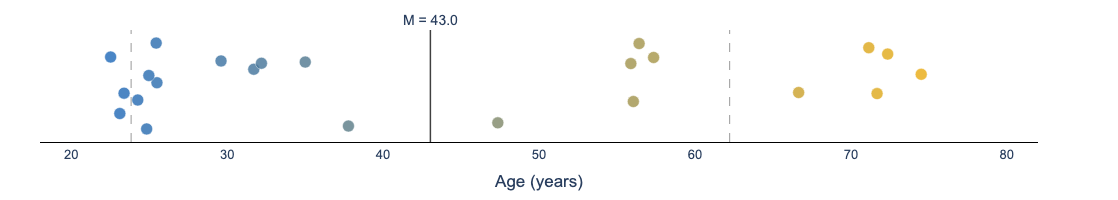

In [11]:
# Sample Demographics

import plotly.graph_objects as go
import matplotlib.colors as mcolors

# ---- Load & filter REDCap to study participants ----
redcap_tacs = pd.read_csv(REDCAP_TACS_PATH)
redcap_tacs = redcap_tacs.rename(columns={'Record ID': 'subject_id', 'Age in years:': 'age'})
redcap_tacs['subject_id'] = redcap_tacs['subject_id'].astype(str)
demo = redcap_tacs[redcap_tacs['subject_id'].isin(SUBJECT_INFO.keys())].copy()

# ---- Summary table ----
n = len(demo)
age_mean, age_sd = demo['age'].mean(), demo['age'].std()
age_min_val, age_max_val = demo['age'].min(), demo['age'].max()

print(f'N = {n}')
print(f'Age: M = {age_mean:.1f}, SD = {age_sd:.1f}, range = {age_min_val:.1f}–{age_max_val:.1f}')
print(f'\nGender:')
for val, count in demo['Gender'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')
print(f'\nRace:')
for val, count in demo['Race'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')
print(f'\nEthnicity:')
for val, count in demo['Ethnicity'].value_counts().items():
    print(f'  {val}: {count} ({100*count/n:.0f}%)')

# ---- Age distribution (strip plot, blue→gold gradient) ----
age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_floor, age_ceil = 20, 80

def age_to_rgb(age):
    norm = np.clip((age - age_floor) / (age_ceil - age_floor), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.15, 0.15, size=n)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=demo['age'], y=jitter,
    mode='markers',
    marker=dict(size=12, opacity=0.8,
                color=[age_to_rgb(a) for a in demo['age']],
                line=dict(width=0.5, color='white')),
    text=[f'sub-{s}<br>Age: {a:.1f}<br>{g}'
          for s, a, g in zip(demo['subject_id'], demo['age'], demo['Gender'])],
    hoverinfo='text',
))

# Mean + SD reference lines
fig.add_vline(x=age_mean, line=dict(color='#404040', width=1.5, dash='solid'),
              annotation_text=f'M = {age_mean:.1f}', annotation_position='top')
fig.add_vline(x=age_mean - age_sd, line=dict(color='#999999', width=1, dash='dash'))
fig.add_vline(x=age_mean + age_sd, line=dict(color='#999999', width=1, dash='dash'))

fig.update_layout(
    height=200, width=700,
    template='plotly_white',
    margin=dict(l=40, r=80, t=30, b=40),
    font=dict(family='Arial', size=14),
    yaxis=dict(visible=False),
    xaxis=dict(title='Age (years)', range=[18, 82]),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='sample_age_distribution')))

## 2. Trial-Level Preprocessing

Compute trial-level variables needed for WSLS analysis: previous choice, previous outcome, and whether the participant stayed or shifted.

In [14]:
def preprocess_trials(df):
    """
    Add trial-level WSLS variables within each subject and run.
    Operates on the full dataset; groups by subject_id and run.
    """
    df = df.copy()
    
    # Previous trial's choice and reward (within each run)
    df['prev_choice'] = df.groupby(['subject_id', 'run'])['choice'].shift(1)
    df['prev_reward'] = df.groupby(['subject_id', 'run'])['reward'].shift(1)
    
    # Stay = same choice as previous trial
    df['stay'] = (df['choice'] == df['prev_choice']).astype(float)
    
    # Shift = different choice from previous trial
    df['shift'] = (df['choice'] != df['prev_choice']).astype(float)
    
    # Mark valid trials (not first trial in run, no missed responses on current or previous)
    df['valid_wsls'] = (
        df['prev_choice'].notna() & 
        df['choice'].notna() & 
        df['prev_reward'].notna()
    )
    
    return df

data = preprocess_trials(data)

# Quick sanity check
valid = data[data['valid_wsls']]
print(f'Valid WSLS trials: {len(valid)} / {len(data)} ({100*len(valid)/len(data):.1f}%)')
print(f'\nOverall stay|win rate: {valid[valid["prev_reward"]==True]["stay"].mean():.3f}')
print(f'Overall shift|lose rate: {valid[valid["prev_reward"]==False]["shift"].mean():.3f}')

Valid WSLS trials: 13219 / 13611 (97.1%)

Overall stay|win rate: 0.850
Overall shift|lose rate: 0.522


## 2.5. Pre-Registered Exclusion Criteria (Run-Level)

Per Section 6 of the pre-registration, **runs** are excluded from behavioral analyses
if they demonstrate:

1. **>20% missed trials** — failure to respond within the response window
2. **Side bias** — selecting a single spatial location (left/right) on >95% of trials
3. **Stimulus bias** — selecting a single stimulus (regardless of position) on >95% of trials
4. **Rapid responding** — median RT <200ms (suggesting non-deliberative responding)
5. **Feedback invariance** — failure to shift following 10 or more consecutive "lose" trials

Exclusion flags are computed **at the run level** (subject × run). Runs failing any
criterion are dropped from downstream analyses. Subjects are retained as long as they
have at least 1 clean run per condition (active, sham) for H2 comparisons.

A separate **stimulation administration exclusion registry** handles cases where the
wrong stimulation condition was delivered (e.g., sham delivered during a scheduled
active run). These runs are dropped from active vs. sham comparisons but may still
contribute to other analyses if behaviorally valid.

**Note:** Minimum clean-run threshold (currently 1 per condition), potentially under review though maybe we should just drop them (i.e., one run ~72 trials sufficient for robust WSLS parameters?)

In [17]:
# =============================================================================
# 2.5a. Exclusion Criteria Functions
# =============================================================================

def compute_exclusion_criteria(df, group_cols=['subject_id', 'run']):
    """
    Compute pre-registered exclusion criteria for each grouping.

    Default grouping is subject × run (run-level exclusions). Can also be
    called with group_cols=['subject_id'] for subject-level summaries or
    group_cols=['subject_id', 'condition'] for condition-level checks.

    Parameters
    ----------
    df : DataFrame
        Trial-level data with columns: subject_id, run, choice, reward,
        rt, slot1_position, slot2_position, flower1, flower2.
    group_cols : list
        Columns to group by.

    Returns
    -------
    DataFrame with exclusion flags and metrics for each group.
    """
    results = []

    # Identify RT column (handle naming variations across task versions)
    rt_col = None
    for col in ['rt', 'RT', 'response_time', 'reaction_time']:
        if col in df.columns:
            rt_col = col
            break

    for name, group in df.groupby(group_cols):
        row = dict(zip(group_cols, name if isinstance(name, tuple) else [name]))
        n_trials = len(group)

        # --- Criterion 1: >20% missed trials ---
        n_missed = group['choice'].isna().sum()
        pct_missed = 100 * n_missed / n_trials if n_trials > 0 else 0
        row['n_trials'] = n_trials
        row['n_missed'] = n_missed
        row['pct_missed'] = pct_missed
        row['flag_missed'] = pct_missed > 20

        # --- Valid (responded) trials for remaining criteria ---
        valid_choices = group.dropna(subset=['choice'])
        n_valid = len(valid_choices)

        # --- Criterion 2: Side bias (>95% same spatial location) ---
        # Derive the chosen side from slot positions and choice identity.
        # choice==1 → flower1 was chosen; flower1's side is determined by
        # whether slot1 holds flower1 (slot1_position) or slot2 does.
        # In the task, choice encodes the flower number (1 or 2), and
        # slot1_position/slot2_position indicate left/right for each slot.
        # Flower1 is always in slot1, flower2 in slot2. So:
        #   choice==1 → chosen side = slot1_position
        #   choice==2 → chosen side = slot2_position
        if 'slot1_position' in valid_choices.columns and 'slot2_position' in valid_choices.columns:
            chosen_side = valid_choices.apply(
                lambda r: r['slot1_position'] if r['choice'] == 1 else r['slot2_position'],
                axis=1
            )
            side_counts = chosen_side.value_counts(normalize=True)
            max_side_pct = side_counts.max() * 100 if len(side_counts) > 0 else 0
        else:
            # Fallback: cannot compute side bias without position columns
            max_side_pct = np.nan

        row['max_side_pct'] = max_side_pct
        row['flag_side_bias'] = max_side_pct > 95 if not np.isnan(max_side_pct) else False

        # --- Criterion 3: Stimulus bias (>95% same stimulus regardless of position) ---
        # 'choice' encodes the chosen stimulus (1 = flower1, 2 = flower2).
        # This is position-independent: if a participant always picks "the purple flower"
        # regardless of which side it appears on, this criterion catches it.
        stim_counts = valid_choices['choice'].value_counts(normalize=True)
        max_stim_pct = stim_counts.max() * 100 if len(stim_counts) > 0 else 0
        row['max_stim_pct'] = max_stim_pct
        row['flag_stim_bias'] = max_stim_pct > 95

        # --- Criterion 4: Rapid responding (median RT < 200ms) ---
        if rt_col:
            valid_rt = valid_choices[rt_col].dropna()
            median_rt = valid_rt.median() if len(valid_rt) > 0 else np.nan
            # RT in this task is in milliseconds (typically 200–2000ms range).
            # Safety check: if median < 100, assume seconds and convert.
            if not np.isnan(median_rt) and median_rt < 100:
                median_rt_ms = median_rt * 1000
            else:
                median_rt_ms = median_rt
            row['median_rt_ms'] = median_rt_ms
            row['flag_rapid_rt'] = median_rt_ms < 200 if not np.isnan(median_rt_ms) else False
        else:
            row['median_rt_ms'] = np.nan
            row['flag_rapid_rt'] = False

        # --- Criterion 5: Feedback invariance (no shift after 10+ consecutive losses) ---
        max_consec_loss_no_shift = compute_max_consecutive_loss_no_shift(group)
        row['max_consec_loss_no_shift'] = max_consec_loss_no_shift
        row['flag_feedback_invariance'] = max_consec_loss_no_shift >= 10

        # --- Overall behavioral exclusion flag ---
        row['exclude_behavioral'] = any([
            row['flag_missed'],
            row['flag_side_bias'],
            row['flag_stim_bias'],
            row['flag_rapid_rt'],
            row['flag_feedback_invariance']
        ])

        results.append(row)

    return pd.DataFrame(results)


def compute_max_consecutive_loss_no_shift(group):
    """
    Find the maximum number of consecutive losses without a shift.

    Pre-registration criterion: exclude if participant fails to shift
    following 10 or more consecutive 'lose' trials.

    Logic: For each streak of consecutive losses, check if the participant
    shifted at any point during the streak. A "shift" on trial t means the
    participant chose a different stimulus than on trial t-1, which would
    be a response to the loss on trial t-1.
    """
    sort_cols = ['run', 'trial_num'] if 'trial_num' in group.columns else ['run']
    df = group.sort_values(sort_cols).copy()

    # Need reward and shift columns
    if 'reward' not in df.columns or 'shift' not in df.columns:
        return 0

    # Work with valid trials only
    df = df.dropna(subset=['choice', 'reward'])
    if len(df) == 0:
        return 0

    # Create loss indicator (reward == False or reward == 0 or reward == 'False')
    df['is_loss'] = df['reward'].apply(
        lambda x: not x if isinstance(x, bool) else str(x).lower() in ('0', 'false', '0.0')
    )

    max_consec = 0
    current_consec = 0
    shifted_in_run = False

    for idx, row in df.iterrows():
        if row['is_loss']:
            current_consec += 1
            if pd.notna(row.get('shift')) and row['shift'] == 1:
                shifted_in_run = True
        else:
            # Win breaks the loss streak
            if current_consec > 0 and not shifted_in_run:
                max_consec = max(max_consec, current_consec)
            current_consec = 0
            shifted_in_run = False

    # Check final streak if it ended in losses
    if current_consec > 0 and not shifted_in_run:
        max_consec = max(max_consec, current_consec)

    return max_consec

### 2.5b. Run-Level Behavioral Exclusions

In [20]:
# =============================================================================
# 2.5b. Compute Exclusion Flags (Run-Level)
# =============================================================================

print('=' * 70)
print('Pre-Registered Exclusion Criteria — Run-Level Assessment')
print('=' * 70)
print()

# --- Compute at run level (subject × run) ---
run_exclusions = compute_exclusion_criteria(data, group_cols=['subject_id', 'run'])

# Add condition labels for readability
run_condition_map = data.groupby(['subject_id', 'run'])['condition'].first().reset_index()
run_exclusions = run_exclusions.merge(run_condition_map, on=['subject_id', 'run'], how='left')

# --- Display full run-level table ---
display_cols = ['subject_id', 'run', 'condition', 'n_trials', 'pct_missed',
                'max_side_pct', 'max_stim_pct', 'median_rt_ms',
                'max_consec_loss_no_shift', 'exclude_behavioral']
print('Run-Level Exclusion Flags:')
print('-' * 90)
print(run_exclusions[display_cols].to_string(index=False, float_format='{:.1f}'.format))
print()

# --- Summary by criterion ---
print('Summary by Criterion (across all runs):')
print('-' * 70)
n_runs_total = len(run_exclusions)
for criterion, label in [
    ('flag_missed', '>20% missed trials'),
    ('flag_side_bias', 'Side bias (>95%)'),
    ('flag_stim_bias', 'Stimulus bias (>95%)'),
    ('flag_rapid_rt', 'Rapid responding (<200ms)'),
    ('flag_feedback_invariance', 'Feedback invariance (10+ losses, no shift)')
]:
    n_flagged = run_exclusions[criterion].sum()
    pct = 100 * n_flagged / n_runs_total if n_runs_total > 0 else 0
    status = '⚠' if n_flagged > 0 else '✓'
    print(f'  {status} {label}: {n_flagged}/{n_runs_total} runs ({pct:.0f}%)')

n_exclude = run_exclusions['exclude_behavioral'].sum()
print()
print(f'Total runs flagged for behavioral exclusion: {n_exclude}/{n_runs_total} '
      f'({100 * n_exclude / n_runs_total:.0f}%)')

if n_exclude > 0:
    flagged = run_exclusions[run_exclusions['exclude_behavioral']]
    print(f'\nFlagged runs:')
    for _, row in flagged.iterrows():
        flags = []
        if row['flag_missed']:       flags.append('missed')
        if row['flag_side_bias']:    flags.append('side_bias')
        if row['flag_stim_bias']:    flags.append('stim_bias')
        if row['flag_rapid_rt']:     flags.append('rapid_rt')
        if row['flag_feedback_invariance']: flags.append('feedback_invariance')
        print(f'  sub-{row["subject_id"]} Run {row["run"]} ({row["condition"]}): {", ".join(flags)}')

Pre-Registered Exclusion Criteria — Run-Level Assessment

Run-Level Exclusion Flags:
------------------------------------------------------------------------------------------
subject_id  run condition  n_trials  pct_missed  max_side_pct  max_stim_pct  median_rt_ms  max_consec_loss_no_shift  exclude_behavioral
     10369    1  baseline        67         6.0          57.1          63.5        1236.1                         1               False
     10369    2      sham        68         2.9          54.5          65.2        1089.6                         3               False
     10369    3      sham        74         0.0          52.7          50.0         505.7                         2               False
     10369    4      post        77         0.0          68.8          51.9         313.3                         2               False
     10369    5  baseline        79         0.0          59.5          54.4         281.0                         2               False
     103

### 2.5c. Stimulation Administration Exclusions & Combined Exclusion Application

Stimulation administration errors are tracked in a manual registry. These are
cases where EEG verification (via the EEG analysis notebook) confirmed that
the wrong stimulation condition was delivered — e.g., sham was delivered on a
run that should have been active per the counterbalance assignment.

These runs are **not** relabeled. They are excluded from active vs. sham
comparisons (H2) because the experimental manipulation was not delivered as
intended. They may still contribute to H1 analyses (which use sham-condition
data only) if they pass behavioral criteria *and* were genuinely sham runs.

After applying both behavioral and stimulation exclusions, we enforce a
**minimum run threshold**: subjects must have ≥1 clean run in each condition
(active, sham) to be included in H2 paired comparisons.

In [23]:
# =============================================================================
# 2.5c. Stimulation Administration Exclusions & Combined Application
# =============================================================================

# --- Manual stimulation administration exclusion registry ---
# Populated from EEG notebook verification (tacs_bandit_eeg.ipynb).
# Each entry documents a run where the delivered stimulation did not match
# the counterbalance-assigned condition.
#
# Format: (subject_id, run) → dict with:
#   'reason'           : free-text explanation
#   'assigned'         : what the counterbalance said this run should be
#   'actual_delivered'  : what was actually delivered (confirmed via EEG)
#
# These runs are excluded from H2 (active vs. sham) comparisons.
# They are NOT excluded from H1 (baseline behavior) unless also flagged
# behaviorally, because the behavioral data itself is still valid.

STIM_EXCLUSIONS = {
    ('10998', 6): {
        'reason': 'Experimenter error: sham protocol loaded instead of active',
        'assigned': 'active',
        'actual_delivered': 'sham',
    },
    ('11773', 6): {
        'reason': 'Experimenter error: sham protocol loaded instead of active',
        'assigned': 'active',
        'actual_delivered': 'sham',
    },
    ('11773', 7): {
        'reason': 'Experimenter error: sham protocol loaded instead of active',
        'assigned': 'active',
        'actual_delivered': 'sham',
    },
}

# --- Apply stimulation exclusion flags to run-level table ---
run_exclusions['exclude_stim'] = run_exclusions.apply(
    lambda r: (str(r['subject_id']), int(r['run'])) in STIM_EXCLUSIONS, axis=1
)
run_exclusions['stim_exclusion_reason'] = run_exclusions.apply(
    lambda r: STIM_EXCLUSIONS.get(
        (str(r['subject_id']), int(r['run'])), {}
    ).get('reason', ''),
    axis=1
)

# --- Combined exclusion flag ---
# A run is excluded from H2 analyses if it fails behavioral criteria OR
# has a stimulation administration error.
run_exclusions['exclude_h2'] = (
    run_exclusions['exclude_behavioral'] | run_exclusions['exclude_stim']
)

# For H1 (sham-only analyses), only behavioral exclusions matter.
# Stim-error runs that were actually sham might still be usable for H1,
# but we conservatively exclude them since the participant's experience
# of that session block may have been affected.
run_exclusions['exclude_h1'] = run_exclusions['exclude_behavioral']

# --- Report stimulation exclusions ---
print('=' * 70)
print('Stimulation Administration Exclusions')
print('=' * 70)
print()

stim_flagged = run_exclusions[run_exclusions['exclude_stim']]
if len(stim_flagged) > 0:
    for _, row in stim_flagged.iterrows():
        info = STIM_EXCLUSIONS[(str(row['subject_id']), int(row['run']))]
        print(f'  sub-{row["subject_id"]} Run {row["run"]} '
              f'(assigned: {info["assigned"]}, delivered: {info["actual_delivered"]})')
        print(f'    → {info["reason"]}')
    print()
else:
    print('  None registered.')
    print()

# --- Apply exclusions to trial-level data ---
# Create a set of (subject_id, run) tuples for fast lookup
behavioral_exclusion_set = set(
    zip(
        run_exclusions.loc[run_exclusions['exclude_behavioral'], 'subject_id'].astype(str),
        run_exclusions.loc[run_exclusions['exclude_behavioral'], 'run'].astype(int)
    )
)
stim_exclusion_set = set(
    (str(sid), int(run)) for (sid, run) in STIM_EXCLUSIONS.keys()
)

# Tag each trial with exclusion flags
data['_run_key'] = list(zip(data['subject_id'].astype(str), data['run'].astype(int)))
data['exclude_behavioral'] = data['_run_key'].isin(behavioral_exclusion_set)
data['exclude_stim'] = data['_run_key'].isin(stim_exclusion_set)
data.drop(columns=['_run_key'], inplace=True)

# Create filtered datasets for downstream use
# data_h1: for H1 analyses (sham condition, behavioral exclusions applied)
data_h1 = data[
    (~data['exclude_behavioral']) &
    (data['condition'] == 'sham')
].copy()

# data_h2: for H2 analyses (active & sham, both exclusion types applied)
data_h2 = data[
    (~data['exclude_behavioral']) &
    (~data['exclude_stim']) &
    (data['condition'].isin(['active', 'sham']))
].copy()

# --- Enforce minimum run threshold for H2 ---
# Require ≥1 clean run per condition (active, sham) for paired comparisons.
# TODO: Confirm threshold with Dave — currently set to 1 clean run minimum.
MIN_CLEAN_RUNS = 1

h2_run_counts = data_h2.groupby(['subject_id', 'condition'])['run'].nunique().reset_index()
h2_run_counts.columns = ['subject_id', 'condition', 'n_clean_runs']
h2_pivot = h2_run_counts.pivot(index='subject_id', columns='condition', values='n_clean_runs').fillna(0)

# Subjects meeting threshold in BOTH conditions
h2_eligible = h2_pivot[
    (h2_pivot.get('active', 0) >= MIN_CLEAN_RUNS) &
    (h2_pivot.get('sham', 0) >= MIN_CLEAN_RUNS)
].index.tolist()

h2_insufficient = h2_pivot[
    (h2_pivot.get('active', 0) < MIN_CLEAN_RUNS) |
    (h2_pivot.get('sham', 0) < MIN_CLEAN_RUNS)
]

# Filter data_h2 to eligible subjects only
data_h2 = data_h2[data_h2['subject_id'].isin(h2_eligible)].copy()

# --- Summary report ---
print('=' * 70)
print('Combined Exclusion Summary')
print('=' * 70)
print()

n_subjects = data['subject_id'].nunique()
n_runs_orig = run_exclusions.shape[0]
n_behavioral = run_exclusions['exclude_behavioral'].sum()
n_stim = run_exclusions['exclude_stim'].sum()
# Some runs may be flagged by both
n_both = (run_exclusions['exclude_behavioral'] & run_exclusions['exclude_stim']).sum()
n_unique_excluded_h2 = run_exclusions['exclude_h2'].sum()

print(f'Total subjects: {n_subjects}')
print(f'Total runs: {n_runs_orig}')
print()
print(f'Runs excluded (behavioral):    {n_behavioral}')
print(f'Runs excluded (stim admin):    {n_stim}')
if n_both > 0:
    print(f'Runs flagged by both:          {n_both}')
print(f'Unique runs excluded for H2:   {n_unique_excluded_h2}')
print()

# H1 sample
n_h1_subjects = data_h1['subject_id'].nunique()
n_h1_runs = data_h1.groupby('subject_id')['run'].nunique().sum()
print(f'H1 sample (sham, behavioral exclusions only):')
print(f'  {n_h1_subjects} subjects, {n_h1_runs} total clean sham runs')
print()

# H2 sample
n_h2_subjects = data_h2['subject_id'].nunique()
print(f'H2 sample (active vs. sham, all exclusions + min-run threshold):')
print(f'  {n_h2_subjects} subjects eligible for paired comparisons')

if len(h2_insufficient) > 0:
    print(f'\n  Subjects excluded from H2 (insufficient clean runs in ≥1 condition):')
    for sid in h2_insufficient.index:
        active_n = int(h2_insufficient.loc[sid].get('active', 0))
        sham_n = int(h2_insufficient.loc[sid].get('sham', 0))
        reasons = []
        if active_n < MIN_CLEAN_RUNS:
            reasons.append(f'active: {active_n} clean runs')
        if sham_n < MIN_CLEAN_RUNS:
            reasons.append(f'sham: {sham_n} clean runs')
        print(f'    sub-{sid}: {"; ".join(reasons)}')
else:
    print(f'\n  All subjects meet minimum run threshold ({MIN_CLEAN_RUNS}+ runs per condition).')

print()
print(f'Downstream usage:')
print(f'  H1 analyses → use `data_h1` ({len(data_h1)} trials)')
print(f'  H2 analyses → use `data_h2` ({len(data_h2)} trials)')
print(f'  Run-level flags → `run_exclusions` DataFrame')

Stimulation Administration Exclusions

  sub-10998 Run 6 (assigned: active, delivered: sham)
    → Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 6 (assigned: active, delivered: sham)
    → Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 7 (assigned: active, delivered: sham)
    → Experimenter error: sham protocol loaded instead of active

Combined Exclusion Summary

Total subjects: 23
Total runs: 184

Runs excluded (behavioral):    8
Runs excluded (stim admin):    3
Runs flagged by both:          1
Unique runs excluded for H2:   10

H1 sample (sham, behavioral exclusions only):
  23 subjects, 45 total clean sham runs

H2 sample (active vs. sham, all exclusions + min-run threshold):
  22 subjects eligible for paired comparisons

  Subjects excluded from H2 (insufficient clean runs in ≥1 condition):
    sub-11773: active: 0 clean runs

Downstream usage:
  H1 analyses → use `data_h1` (3332 trials)
  H2 analyses → use `data_h2` (6156 

Subjects in study cohort with ICV data: 23
Estimated vs Actual Cap Size Comparison

Subjects with both estimated and actual: 14
  Matches (same size): 9
  Off by 1 size: 4
  Off by 2 sizes: 1

 Subject      ICV    Estimated       Actual   Diff
--------------------------------------------------
   10369   1534.5        Large        Large  Match
   10559   1443.6        Large        Large  Match
   10606   1489.6        Large        Large  Match
   10608   1197.5        Small        Small  Match
   10649   1395.5       Medium        Small     +1
   10656   1532.0        Large        Large  Match
   10866   1547.8        Large        Large  Match
   10886   1520.7        Large       Medium     +1
   10998   1530.6        Large       Medium     +1
   11286   1484.4        Large        Small     +2
   11329   1751.6  Extra Large        Large     +1
   11563   1526.3        Large        Large  Match
   11628   1365.5       Medium       Medium  Match
   11773   1434.5       Medium       Mediu

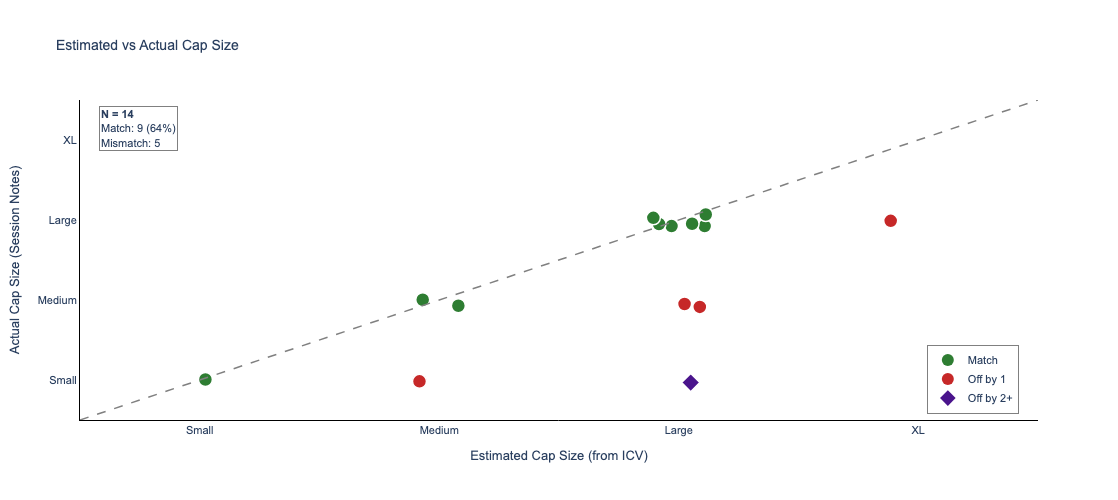


Full Subject Table (Study Cohort)

 Subject      ICV      Estimated       Actual       Status
------------------------------------------------------------
   10369   1534.5          Large        Large      ✓ Match
   10418   1329.0              —       Medium   Incomplete
   10541   1614.6    Extra Large            —   Incomplete
   10559   1443.6          Large        Large      ✓ Match
   10589   1494.2          Large            —   Incomplete
   10606   1489.6          Large        Large      ✓ Match
   10608   1197.5          Small        Small      ✓ Match
   10636   1313.4              —        Small   Incomplete
   10641   1313.5          Small            —   Incomplete
   10649   1395.5         Medium        Small    ✗ +1 size
   10656   1532.0          Large        Large      ✓ Match
   10809   1667.3    Extra Large            —   Incomplete
   10866   1547.8          Large        Large      ✓ Match
   10886   1520.7          Large       Medium    ✗ +1 size
   10951   1750.8 

In [25]:
# =============================================================================
# Estimated vs Actual Cap Size — Match/Mismatch Analysis
# =============================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy import stats

# -----------------------------------------------------------------------------
# Subject Filter
# -----------------------------------------------------------------------------
valid_subjects = set(int(s) for s in SUBJECT_INFO.keys())

# Load REDCap data
redcap_df = pd.read_csv(REDCAP_TACS_PATH)

# Extract relevant columns
cap_df = redcap_df[['Record ID', 'Intracranial Volume', 'Cap size', 'Cap size.1']].copy()
cap_df.columns = ['subject_id', 'icv', 'cap_estimated', 'cap_actual']

# Filter to numeric subject IDs and valid ICV
cap_df = cap_df[cap_df['subject_id'].astype(str).str.match(r'^\d+$')]
cap_df['subject_id'] = cap_df['subject_id'].astype(int)
cap_df = cap_df[cap_df['icv'].notna()].copy()

# Filter to study participants only
cap_df = cap_df[cap_df['subject_id'].isin(valid_subjects)].copy()
print(f"Subjects in study cohort with ICV data: {len(cap_df)}")

# Map to numeric for comparison
cap_map = {'Small': 1, 'Medium': 2, 'Large': 3, 'Extra Large': 4}
cap_df['est_numeric'] = cap_df['cap_estimated'].map(cap_map)
cap_df['act_numeric'] = cap_df['cap_actual'].map(cap_map)

# Filter to subjects with BOTH estimated and actual
cap_both = cap_df[(cap_df['est_numeric'].notna()) & (cap_df['act_numeric'].notna())].copy()

# Calculate mismatch
cap_both['diff'] = cap_both['est_numeric'] - cap_both['act_numeric']
cap_both['abs_diff'] = cap_both['diff'].abs()
cap_both['match'] = cap_both['abs_diff'] == 0

# -----------------------------------------------------------------------------
# Summary Table
# -----------------------------------------------------------------------------
print('='*70)
print('Estimated vs Actual Cap Size Comparison')
print('='*70)
print(f"\nSubjects with both estimated and actual: {len(cap_both)}")
print(f"  Matches (same size): {cap_both['match'].sum()}")
print(f"  Off by 1 size: {(cap_both['abs_diff'] == 1).sum()}")
print(f"  Off by 2 sizes: {(cap_both['abs_diff'] == 2).sum()}")

print(f"\n{'Subject':>8} {'ICV':>8} {'Estimated':>12} {'Actual':>12} {'Diff':>6}")
print('-'*50)
for _, row in cap_both.sort_values('subject_id').iterrows():
    diff_str = 'Match' if row['diff'] == 0 else f"{int(row['diff']):+d}"
    print(f"{int(row['subject_id']):>8} {row['icv']:>8.1f} {row['cap_estimated']:>12} "
          f"{row['cap_actual']:>12} {diff_str:>6}")

# Direction of mismatches
mismatches = cap_both[~cap_both['match']]
if len(mismatches) > 0:
    print(f"\nMismatch direction:")
    print(f"  Actual smaller than estimated: {(mismatches['diff'] > 0).sum()}")
    print(f"  Actual larger than estimated: {(mismatches['diff'] < 0).sum()}")

# -----------------------------------------------------------------------------
# Scatter Plot: Estimated vs Actual
# -----------------------------------------------------------------------------
fig = go.Figure()

# Add jitter for visibility
np.random.seed(42)
jitter_est = cap_both['est_numeric'] + np.random.uniform(-0.12, 0.12, len(cap_both))
jitter_act = cap_both['act_numeric'] + np.random.uniform(-0.12, 0.12, len(cap_both))

# Color by match status
colors = []
symbols = []
for _, row in cap_both.iterrows():
    if row['abs_diff'] == 0:
        colors.append('#2E7D32')  # Green - match
        symbols.append('circle')
    elif row['abs_diff'] == 1:
        colors.append('#C62828')  # Red - off by 1
        symbols.append('circle')
    else:
        colors.append('#4A148C')  # Purple - off by 2+
        symbols.append('diamond')

# Scatter points
fig.add_trace(go.Scatter(
    x=jitter_est,
    y=jitter_act,
    mode='markers',
    marker=dict(size=14, color=colors, symbol=symbols,
                line=dict(width=1.5, color='white')),
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'ICV: %{customdata[1]:.0f} mm³<br>'
        'Estimated: %{customdata[2]}<br>'
        'Actual: %{customdata[3]}<br>'
        'Diff: %{customdata[4]}<extra></extra>'
    ),
    customdata=np.column_stack([
        cap_both['subject_id'].values,
        cap_both['icv'].values,
        cap_both['cap_estimated'].values,
        cap_both['cap_actual'].values,
        ['Match' if d == 0 else f'{int(d):+d} size' for d in cap_both['diff'].values]
    ]),
    showlegend=False,
))

# Diagonal reference line (perfect agreement)
fig.add_trace(go.Scatter(
    x=[0.5, 4.5], y=[0.5, 4.5],
    mode='lines',
    line=dict(color='gray', width=1.5, dash='dash'),
    showlegend=False,
    hoverinfo='skip',
))

# Legend markers
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', name='Match',
    marker=dict(size=12, color='#2E7D32', symbol='circle'),
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', name='Off by 1',
    marker=dict(size=12, color='#C62828', symbol='circle'),
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', name='Off by 2+',
    marker=dict(size=12, color='#4A148C', symbol='diamond'),
))

# Summary annotation
n_match = cap_both['match'].sum()
n_total = len(cap_both)
pct_match = 100 * n_match / n_total
fig.add_annotation(
    x=0.02, y=0.98, xref='paper', yref='paper',
    text=f"<b>N = {n_total}</b><br>Match: {n_match} ({pct_match:.0f}%)<br>Mismatch: {n_total - n_match}",
    showarrow=False,
    font=dict(size=11),
    align='left',
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor='gray', borderwidth=1,
    xanchor='left', yanchor='top',
)

fig.update_layout(
    height=500, width=550,
    template='plotly_white',
    font=dict(family='Arial', size=11),
    title=dict(text='Estimated vs Actual Cap Size', font=dict(size=14)),
    xaxis=dict(
        title='Estimated Cap Size (from ICV)',
        tickvals=[1, 2, 3, 4],
        ticktext=['Small', 'Medium', 'Large', 'XL'],
        range=[0.5, 4.5],
        showgrid=False, linecolor='black', linewidth=1,
    ),
    yaxis=dict(
        title='Actual Cap Size (Session Notes)',
        tickvals=[1, 2, 3, 4],
        ticktext=['Small', 'Medium', 'Large', 'XL'],
        range=[0.5, 4.5],
        showgrid=False, linecolor='black', linewidth=1,
    ),
    legend=dict(x=0.98, y=0.02, xanchor='right', yanchor='bottom',
                bgcolor='rgba(255,255,255,0.9)', bordercolor='gray', borderwidth=1),
)

fig.show(config=dict(toImageButtonOptions=dict(filename='cap_size_estimated_vs_actual')))

# -----------------------------------------------------------------------------
# Full Subject Table (including NaNs for reference)
# -----------------------------------------------------------------------------
print(f"\n" + "="*70)
print("Full Subject Table (Study Cohort)")
print("="*70)
print(f"\n{'Subject':>8} {'ICV':>8} {'Estimated':>14} {'Actual':>12} {'Status':>12}")
print('-'*60)

for _, row in cap_df.sort_values('subject_id').iterrows():
    est = row['cap_estimated'] if pd.notna(row['cap_estimated']) else '—'
    act = row['cap_actual'] if pd.notna(row['cap_actual']) else '—'
    
    if pd.isna(row['est_numeric']) or pd.isna(row['act_numeric']):
        status = 'Incomplete'
    elif row['est_numeric'] == row['act_numeric']:
        status = '✓ Match'
    else:
        diff = int(row['est_numeric'] - row['act_numeric'])
        status = f'✗ {diff:+d} size'
    
    print(f"{int(row['subject_id']):>8} {row['icv']:>8.1f} {est:>14} {act:>12} {status:>12}")

## 3. WSLS Parameter Computation

Compute p(stay|win) and p(shift|lose) for each subject. Two separate computations:
- **H1 (sham only):** Uses `data_h1` (sham-condition runs, behavioral exclusions applied). Grouped by subject only.
- **H2 (active vs. sham):** Uses `data_h2` (both exclusion types + min-run threshold). Grouped by subject × condition.

For H1, the sham condition serves as the baseline measure of learning behavior.

In [28]:
def compute_wsls(df, groupby_cols=['subject_id', 'condition']):
    """
    Compute WSLS parameters for each grouping.
    
    Returns DataFrame with:
        p_stay_win:  P(stay | previous trial was rewarded)
        p_shift_lose: P(shift | previous trial was not rewarded)
        n_win_trials: count of post-win trials
        n_lose_trials: count of post-loss trials
    """
    valid = df[df['valid_wsls']].copy()
    
    results = []
    for name, group in valid.groupby(groupby_cols):
        win_trials = group[group['prev_reward'] == True]
        lose_trials = group[group['prev_reward'] == False]
        
        row = dict(zip(groupby_cols, name if isinstance(name, tuple) else [name]))
        row['p_stay_win'] = win_trials['stay'].mean() if len(win_trials) > 0 else np.nan
        row['p_shift_lose'] = lose_trials['shift'].mean() if len(lose_trials) > 0 else np.nan
        row['n_win_trials'] = len(win_trials)
        row['n_lose_trials'] = len(lose_trials)
        row['n_total_trials'] = len(group)
        results.append(row)
    
    return pd.DataFrame(results)


# Compute WSLS by subject x condition
# H1: sham-condition WSLS (uses data_h1, which has behavioral exclusions applied)
wsls_h1 = compute_wsls(data_h1, groupby_cols=['subject_id'])

# H2: active + sham WSLS (uses data_h2, which has both exclusion types + min-run threshold)
wsls_h2 = compute_wsls(data_h2, groupby_cols=['subject_id', 'condition'])

# Combined for visualization (all conditions, behavioral exclusions only)
data_clean = data[~data['exclude_behavioral']].copy()
wsls = compute_wsls(data_clean)

print('H1 WSLS (sham, clean runs):')
print(wsls_h1.to_string(index=False, float_format='{:.3f}'.format))
print()
print('H2 WSLS (active vs. sham, clean runs):')
print(wsls_h2.to_string(index=False, float_format='{:.3f}'.format))
print('WSLS parameters by subject and condition:')
print(wsls.to_string(index=False, float_format='{:.3f}'.format))

H1 WSLS (sham, clean runs):
subject_id  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10369       0.592         0.508            71             65             136
     10418       0.959         0.500            74             68             142
     10541       0.946         0.648            74             54             128
     10559       0.882         0.354            76             65             141
     10589       0.913         0.370           104             46             150
     10606       0.439         0.471            41             34              75
     10608       0.977         0.678            86             59             145
     10636       0.990         0.396            98             48             146
     10641       0.873         0.607            79             61             140
     10649       0.988         0.508            83             59             142
     10656       0.976         0.955            85             66     

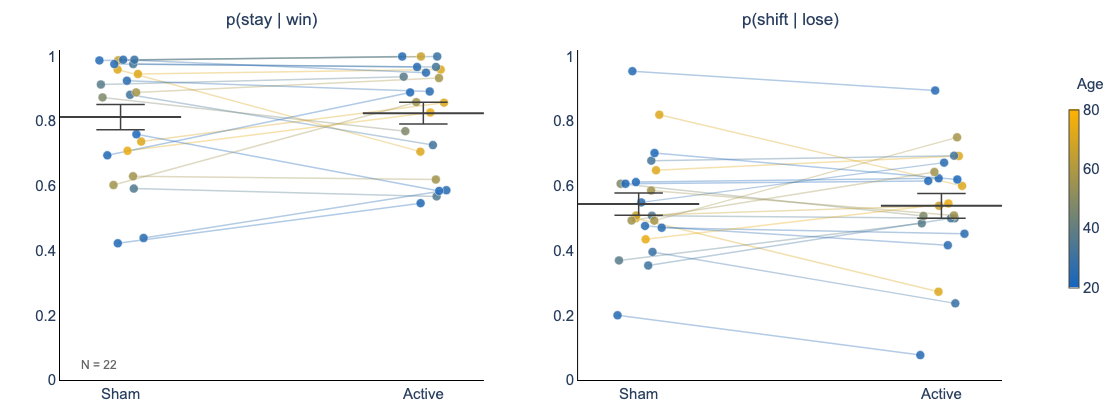

In [30]:
# Visualize WSLS Parameters by Condition (PAIRED + FIXED)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors
import numpy as np

# ---- Configuration ----
condition_order = ['sham', 'active']
age_min, age_max = 20, 80
cap_w = 0.08

wsls_plot = wsls_h2.copy()
n_h2_plot = wsls_plot['subject_id'].nunique()

# ---- Age colormap ----
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[r'p(stay | win)', r'p(shift | lose)']
)

rng = np.random.default_rng(42)

# ---- Consistent subject-level jitter ----
subjects = wsls_plot['subject_id'].unique()
subject_jitter = {s: rng.uniform(-0.08, 0.08) for s in subjects}

for col, param in enumerate(['p_stay_win', 'p_shift_lose'], start=1):

    plot_data = wsls_plot[wsls_plot['condition'].isin(condition_order)].copy()

    # ---- Pivot for pairing ----
    pivot = plot_data.pivot(index='subject_id', columns='condition', values=param)
    pivot = pivot.dropna(subset=condition_order)

    # ---- Draw paired lines (behind points) ----
    for subj in pivot.index:
        y_vals = pivot.loc[subj, condition_order].values
        jitter = subject_jitter[subj]

        x_vals = [0 + jitter, 1 + jitter]

        age = age_lookup.get(subj, np.nan)
        base_color = age_to_color(age)
        rgba_color = base_color.replace('rgb', 'rgba').replace(')', ',0.35)')

        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines',
            line=dict(color=rgba_color, width=1.5),
            showlegend=False,
            hoverinfo='skip'
        ), row=1, col=col)

    # ---- Plot individual points ----
    for i, cond in enumerate(condition_order):
        cond_data = plot_data[plot_data['condition'] == cond]

        jitter = np.array([subject_jitter[s] for s in cond_data['subject_id']])

        fig.add_trace(go.Scatter(
            x=i + jitter,
            y=cond_data[param],
            mode='markers',
            marker=dict(
                size=9,
                opacity=0.85,
                color=[age_to_color(age_lookup.get(s, np.nan))
                       for s in cond_data['subject_id']],
                line=dict(width=0.5, color='white')
            ),
            text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?")}'
                  for s in cond_data['subject_id']],
            hoverinfo='text+y',
            showlegend=False,
        ), row=1, col=col)

        # ---- Mean + SEM ----
        vals = cond_data[param].dropna()
        if len(vals) > 0:
            mean = vals.mean()
            sem = vals.sem() if len(vals) > 1 else 0

            # vertical bar
            fig.add_trace(go.Scatter(
                x=[i, i], y=[mean - sem, mean + sem],
                mode='lines',
                line=dict(color='#404040', width=1.5),
                showlegend=False,
                hoverinfo='skip'
            ), row=1, col=col)

            # caps
            fig.add_trace(go.Scatter(
                x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem],
                mode='lines',
                line=dict(color='#404040', width=1.5),
                showlegend=False,
                hoverinfo='skip'
            ), row=1, col=col)

            fig.add_trace(go.Scatter(
                x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem],
                mode='lines',
                line=dict(color='#404040', width=1.5),
                showlegend=False,
                hoverinfo='skip'
            ), row=1, col=col)

            # mean line
            fig.add_trace(go.Scatter(
                x=[i - 0.2, i + 0.2],
                y=[mean, mean],
                mode='lines',
                line=dict(color='#404040', width=2),
                showlegend=False,
                hoverinfo='text',
                text=[f'{cond.capitalize()} mean: {mean:.3f}'] * 2,
            ), row=1, col=col)

    # ---- Axes ----
    fig.update_xaxes(
        tickvals=list(range(len(condition_order))),
        ticktext=[c.capitalize() for c in condition_order],
        row=1, col=col
    )
    fig.update_yaxes(range=[0, 1.02], row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=800,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
)

fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

# ---- Colorbar ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.06, y=0.55, len=0.6, thickness=10,
                              tickfont=dict(size=15))),
    showlegend=False, hoverinfo='skip',
))

fig.add_annotation(text='Age', x=1.11, y=.93,
                   xref='paper', yref='paper',
                   showarrow=False,
                   font=dict(family='Arial', size=15))

# ---- Titles ----
for ann in fig.layout.annotations:
    if ann.text in [r'p(stay | win)', r'p(shift | lose)']:
        ann.update(font_size=17, y=1.06)

# ---- N annotation ----
fig.add_annotation(
    text=f'N = {n_h2_plot}',
    x=0.02, y=0.02,
    xref='paper', yref='paper',
    showarrow=False,
    font=dict(size=12, color='#666666'),
    xanchor='left'
)

fig.show(config=dict(toImageButtonOptions=dict(filename='wsls_paired_fixed')))

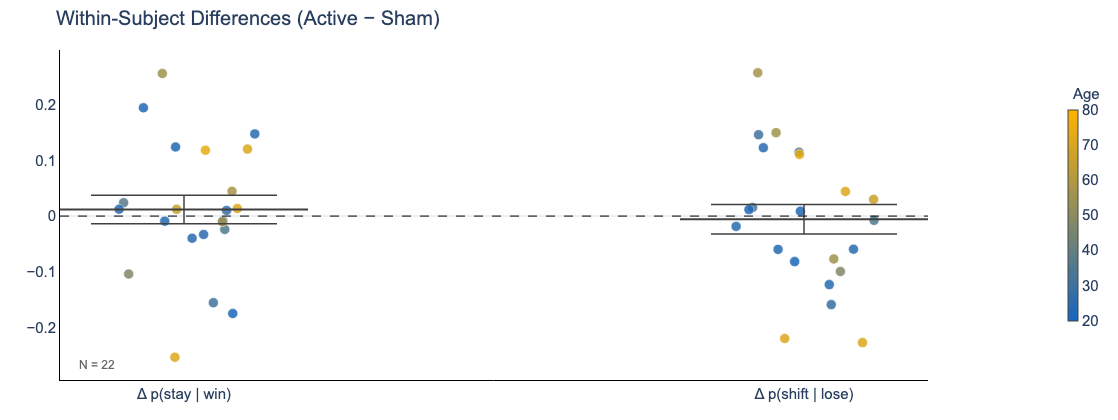

In [31]:
# WSLS Difference Plot (Active - Sham)

import plotly.graph_objects as go
import matplotlib.colors as mcolors
import numpy as np

# ---- Configuration ----
age_min, age_max = 20, 80
cap_w = 0.15

wsls_plot = wsls_h2.copy()
n_h2_plot = wsls_plot['subject_id'].nunique()

# ---- Age colormap ----
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = go.Figure()
rng = np.random.default_rng(42)

params = ['p_stay_win', 'p_shift_lose']
x_positions = [0, 1]
x_labels = ['Δ p(stay | win)', 'Δ p(shift | lose)']

for i, param in enumerate(params):

    # ---- Pivot to compute within-subject differences ----
    pivot = wsls_plot.pivot(index='subject_id', columns='condition', values=param)

    # keep only complete pairs
    pivot = pivot.dropna(subset=['sham', 'active'])

    # compute difference
    diff = pivot['active'] - pivot['sham']

    subjects = diff.index

    # jitter (only horizontal now)
    jitter = rng.uniform(-0.12, 0.12, size=len(diff))

    # ---- Plot points ----
    fig.add_trace(go.Scatter(
        x=np.full(len(diff), i) + jitter,
        y=diff.values,
        mode='markers',
        marker=dict(
            size=10,
            opacity=0.85,
            color=[age_to_color(age_lookup.get(s, np.nan)) for s in subjects],
            line=dict(width=0.5, color='white')
        ),
        text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?")}<br>Δ: {d:.3f}'
              for s, d in zip(subjects, diff.values)],
        hoverinfo='text+y',
        showlegend=False
    ))

    # ---- Mean + SEM ----
    vals = diff.values
    if len(vals) > 0:
        mean = np.mean(vals)
        sem = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0

        # vertical error bar
        fig.add_trace(go.Scatter(
            x=[i, i],
            y=[mean - sem, mean + sem],
            mode='lines',
            line=dict(color='#404040', width=1.5),
            showlegend=False,
            hoverinfo='skip'
        ))

        # caps
        fig.add_trace(go.Scatter(
            x=[i - cap_w, i + cap_w],
            y=[mean + sem, mean + sem],
            mode='lines',
            line=dict(color='#404040', width=1.5),
            showlegend=False,
            hoverinfo='skip'
        ))

        fig.add_trace(go.Scatter(
            x=[i - cap_w, i + cap_w],
            y=[mean - sem, mean - sem],
            mode='lines',
            line=dict(color='#404040', width=1.5),
            showlegend=False,
            hoverinfo='skip'
        ))

        # mean line
        fig.add_trace(go.Scatter(
            x=[i - 0.2, i + 0.2],
            y=[mean, mean],
            mode='lines',
            line=dict(color='#404040', width=2),
            showlegend=False,
            hoverinfo='text',
            text=[f'Mean Δ: {mean:.3f}'] * 2
        ))

# ---- Zero reference line ----
fig.add_hline(y=0, line=dict(color='black', width=1, dash='dash'))

# ---- Axes ----
fig.update_xaxes(
    tickvals=x_positions,
    ticktext=x_labels,
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    tickfont=dict(size=15)
)

fig.update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    tickfont=dict(size=15)
)

# ---- Layout ----
fig.update_layout(
    height=420, width=600,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
    title='Within-Subject Differences (Active − Sham)'
)

# ---- Colorbar ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(
        size=0.1,
        color=dummy_ages,
        colorscale=[[0, '#1565C0'], [1, '#FFB300']],
        cmin=age_min,
        cmax=age_max,
        colorbar=dict(
            x=1.15,
            y=0.5,
            len=0.7,
            thickness=10,
            tickfont=dict(size=15)
        )
    ),
    showlegend=False,
    hoverinfo='skip'
))

fig.add_annotation(
    text='Age',
    x=1.2, y=0.9,
    xref='paper', yref='paper',
    showarrow=False,
    font=dict(size=15)
)

# ---- N annotation ----
fig.add_annotation(
    text=f'N = {n_h2_plot}',
    x=0.02, y=0.02,
    xref='paper', yref='paper',
    showarrow=False,
    font=dict(size=12, color='#666666'),
    xanchor='left'
)

fig.show(config=dict(toImageButtonOptions=dict(filename='wsls_difference')))

## 4. Rescorla-Wagner Model Fitting

Fit a Rescorla-Wagner (R-W) reinforcement learning model to each subject × condition block.

**Model specification:**
- **Learning rule:** $Q_{c,t+1} = Q_{c,t} + \alpha (r_t - Q_{c,t})$
- **Choice rule (softmax):** $p(\text{choice} = i) = \frac{e^{\beta Q_i}}{\sum_j e^{\beta Q_j}}$

**Free parameters:**
- **α (learning rate):** 0 < α < 1. Higher α → stronger weighting of recent outcomes.
- **β (inverse temperature):** β > 0. Higher β → more deterministic exploitation of learned values. Also serves as task-derived reward sensitivity (pre-registered).

**Estimation approach:**
- Primary: Maximum Likelihood Estimation (MLE) with 10 random restarts
- Sensitivity: Maximum A Posteriori (MAP) with weakly informative priors

Values initialized at 0.5 (equal preference). Fits hitting parameter bounds are flagged.

**References:**
- Daw, N. D. (2011). Trial-by-trial data analysis using computational models. *Decision Making, Affect, and Learning*, 3-38.

In [ ]:
# =============================================================================
# 4.1 Rescorla-Wagner Model Functions
# =============================================================================

from scipy import stats

def rescorla_wagner_nll(params, choices, rewards):
    """
    Negative log-likelihood for a simple Rescorla-Wagner model.
    
    Parameters
    ----------
    params : array-like [alpha, beta]
        alpha : float in (0, 1) — learning rate
        beta : float > 0 — inverse temperature (reward sensitivity)
    choices : array-like of int (1 or 2)
        Participant's choice on each trial (1-indexed)
    rewards : array-like of bool or int
        Whether each trial was rewarded (True/1) or not (False/0)
    
    Returns
    -------
    float : negative log-likelihood (lower is better fit)
    """
    alpha, beta = params
    Q = np.array([0.5, 0.5])
    nll = 0.0
    
    for choice, reward in zip(choices, rewards):
        if np.isnan(choice) or np.isnan(reward):
            continue
        
        # Numerically stable softmax
        exp_vals = np.exp(beta * (Q - np.max(Q)))
        p = exp_vals / exp_vals.sum()
        
        c = int(choice) - 1
        nll -= np.log(np.clip(p[c], 1e-8, 1.0))
        
        r = float(reward)
        Q[c] += alpha * (r - Q[c])
    
    return nll


def rescorla_wagner_nlp(params, choices, rewards, 
                        prior_alpha=(2, 2), prior_beta=(2, 5)):
    """
    Negative log-posterior for Rescorla-Wagner model (MAP estimation).
    
    Adds weakly informative priors to regularize parameter estimates.
    Priors: α ~ Beta(2,2), β ~ Gamma(2, scale=5)
    """
    alpha, beta_param = params
    
    if alpha <= 0 or alpha >= 1 or beta_param <= 0:
        return 1e9
    
    nll = rescorla_wagner_nll(params, choices, rewards)
    
    log_prior_alpha = stats.beta.logpdf(alpha, a=prior_alpha[0], b=prior_alpha[1])
    log_prior_beta = stats.gamma.logpdf(beta_param, a=prior_beta[0], scale=prior_beta[1])
    
    nlp = nll - (log_prior_alpha + log_prior_beta)
    
    if np.isinf(nlp) or np.isnan(nlp):
        return 1e9
    
    return nlp


def fit_rescorla_wagner(choices, rewards, method='mle', n_starts=10, 
                        prior_alpha=(2, 2), prior_beta=(2, 5)):
    """
    Fit R-W model using MLE or MAP with multiple random starting points.
    
    Parameters
    ----------
    choices : array-like — Choice sequence (1 or 2)
    rewards : array-like — Reward sequence (bool or 0/1)
    method : str, 'mle' or 'map'
    n_starts : int — Number of random initialization attempts
    
    Returns
    -------
    dict with: alpha, beta, nll, bic, aic, at_boundary, converged, method
    """
    n_trials = len(choices)
    bounds = [(0.001, 0.999), (0.01, 50.0)]
    
    if method == 'map':
        obj_func = lambda p, c, r: rescorla_wagner_nlp(p, c, r, prior_alpha, prior_beta)
    else:
        obj_func = rescorla_wagner_nll
    
    best_result = None
    best_obj = np.inf
    
    for _ in range(n_starts):
        x0 = [np.random.uniform(0.05, 0.95), np.random.uniform(0.5, 15.0)]
        result = optimize.minimize(
            obj_func, x0, args=(choices, rewards),
            bounds=bounds, method='L-BFGS-B',
            options={'maxiter': 1000}
        )
        if result.fun < best_obj:
            best_obj = result.fun
            best_result = result
    
    alpha, beta = best_result.x
    nll = rescorla_wagner_nll([alpha, beta], choices, rewards)
    
    k = 2
    bic = k * np.log(n_trials) + 2 * nll
    aic = 2 * k + 2 * nll
    
    at_boundary = (alpha <= 0.002 or alpha >= 0.998 or 
                   beta <= 0.02 or beta >= 49.9)
    
    return {
        'alpha': alpha, 'beta': beta, 'nll': nll, 'bic': bic, 'aic': aic,
        'at_boundary': at_boundary, 'converged': best_result.success, 'method': method
    }


def simulate_rw_agent(alpha, beta, n_trials=50, p_reward=(0.75, 0.25), seed=None):
    """Simulate choice data from an R-W agent for parameter recovery."""
    if seed is not None:
        np.random.seed(seed)
    
    Q = np.array([0.5, 0.5])
    choices, rewards = [], []
    
    for _ in range(n_trials):
        exp_vals = np.exp(beta * (Q - np.max(Q)))
        p = exp_vals / exp_vals.sum()
        choice = np.random.choice([1, 2], p=p)
        reward = int(np.random.random() < p_reward[choice - 1])
        
        choices.append(choice)
        rewards.append(reward)
        Q[choice - 1] += alpha * (reward - Q[choice - 1])
    
    return np.array(choices), np.array(rewards)


### 4.2 Parameter Recovery Validation

Before applying the model to real data, we verify that our fitting procedure can accurately recover known parameters from simulated data (Daw, 2011).

In [ ]:
# =============================================================================
# 4.2 Parameter Recovery Validation
# =============================================================================

print('='*70)
print('Parameter Recovery Validation')
print('='*70)
print()

n_simulations = 100
n_trials_sim = 100
true_alphas = np.random.uniform(0.1, 0.9, n_simulations)
true_betas = np.random.uniform(1.0, 15.0, n_simulations)

recovery_results = {'true_alpha': [], 'true_beta': [], 
                    'est_alpha_mle': [], 'est_beta_mle': [],
                    'est_alpha_map': [], 'est_beta_map': []}

for i in range(n_simulations):
    choices, rewards = simulate_rw_agent(true_alphas[i], true_betas[i], 
                                          n_trials=n_trials_sim, seed=i)
    
    fit_mle = fit_rescorla_wagner(choices, rewards, method='mle', n_starts=5)
    fit_map = fit_rescorla_wagner(choices, rewards, method='map', n_starts=5)
    
    recovery_results['true_alpha'].append(true_alphas[i])
    recovery_results['true_beta'].append(true_betas[i])
    recovery_results['est_alpha_mle'].append(fit_mle['alpha'])
    recovery_results['est_beta_mle'].append(fit_mle['beta'])
    recovery_results['est_alpha_map'].append(fit_map['alpha'])
    recovery_results['est_beta_map'].append(fit_map['beta'])

recovery_df = pd.DataFrame(recovery_results)

corr_alpha_mle = np.corrcoef(recovery_df['true_alpha'], recovery_df['est_alpha_mle'])[0, 1]
corr_beta_mle = np.corrcoef(recovery_df['true_beta'], recovery_df['est_beta_mle'])[0, 1]
corr_alpha_map = np.corrcoef(recovery_df['true_alpha'], recovery_df['est_alpha_map'])[0, 1]
corr_beta_map = np.corrcoef(recovery_df['true_beta'], recovery_df['est_beta_map'])[0, 1]

print(f'Parameter Recovery Correlations (n={n_simulations} simulations, {n_trials_sim} trials each):')
print('-'*70)
print(f'  MLE:  r(true α, est α) = {corr_alpha_mle:.3f}')
print(f'        r(true β, est β) = {corr_beta_mle:.3f}')
print(f'  MAP:  r(true α, est α) = {corr_alpha_map:.3f}')
print(f'        r(true β, est β) = {corr_beta_map:.3f}')
print()

# Check recovery quality (α via MLE is fine; β needs MAP)
if corr_alpha_mle > 0.7 and corr_beta_map > 0.7:
    print('✓ Parameter recovery is adequate (note: β recovery requires MAP estimation).')
elif corr_alpha_mle > 0.7 and corr_beta_mle > 0.7:
    print('✓ Parameter recovery is adequate for both parameters.')
else:
    print('⚠ WARNING: Parameter recovery is weak for one or both parameters.')


In [ ]:
# Parameter Recovery Visualization (Plotly)

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=[f'α Recovery (MLE), r = {corr_alpha_mle:.3f}',
                                    f'β Recovery (MLE), r = {corr_beta_mle:.3f}',
                                    f'α Recovery (MAP), r = {corr_alpha_map:.3f}',
                                    f'β Recovery (MAP), r = {corr_beta_map:.3f}'])

# MLE α
fig.add_trace(go.Scatter(x=recovery_df['true_alpha'], y=recovery_df['est_alpha_mle'],
                         mode='markers', marker=dict(size=6, opacity=0.6),
                         showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                         line=dict(dash='dash', color='gray'), showlegend=False), row=1, col=1)

# MLE β
fig.add_trace(go.Scatter(x=recovery_df['true_beta'], y=recovery_df['est_beta_mle'],
                         mode='markers', marker=dict(size=6, opacity=0.6),
                         showlegend=False), row=1, col=2)
max_beta = max(recovery_df['true_beta'].max(), recovery_df['est_beta_mle'].max()) + 1
fig.add_trace(go.Scatter(x=[0, max_beta], y=[0, max_beta], mode='lines',
                         line=dict(dash='dash', color='gray'), showlegend=False), row=1, col=2)

# MAP α
fig.add_trace(go.Scatter(x=recovery_df['true_alpha'], y=recovery_df['est_alpha_map'],
                         mode='markers', marker=dict(size=6, opacity=0.6, color='#FF7F0E'),
                         showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                         line=dict(dash='dash', color='gray'), showlegend=False), row=2, col=1)

# MAP β
fig.add_trace(go.Scatter(x=recovery_df['true_beta'], y=recovery_df['est_beta_map'],
                         mode='markers', marker=dict(size=6, opacity=0.6, color='#FF7F0E'),
                         showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=[0, max_beta], y=[0, max_beta], mode='lines',
                         line=dict(dash='dash', color='gray'), showlegend=False), row=2, col=2)

# Axis formatting
fig.update_xaxes(range=[0, 1], title_text='True α', row=1, col=1)
fig.update_yaxes(range=[0, 1], title_text='Est α (MLE)', row=1, col=1)
fig.update_xaxes(range=[0, max_beta], title_text='True β', row=1, col=2)
fig.update_yaxes(range=[0, max_beta], title_text='Est β (MLE)', row=1, col=2)
fig.update_xaxes(range=[0, 1], title_text='True α', row=2, col=1)
fig.update_yaxes(range=[0, 1], title_text='Est α (MAP)', row=2, col=1)
fig.update_xaxes(range=[0, max_beta], title_text='True β', row=2, col=2)
fig.update_yaxes(range=[0, max_beta], title_text='Est β (MAP)', row=2, col=2)

fig.update_layout(height=600, width=700, title_text='Parameter Recovery Validation',
                  template='plotly_white')
fig.show()


### 4.3 Fit Model to Empirical Data

Fit R-W model to each subject × condition block (sham, active only) using both MLE (primary) and MAP (sensitivity). Uses `data_clean` (behavioral exclusions applied). Stim exclusions are handled downstream at the H2 comparison stage.

In [ ]:
# =============================================================================
# 4.3 Fit Model to Empirical Data
# =============================================================================
# Fit to sham and active conditions only (the conditions used in analyses).
# Uses data_clean (behavioral exclusions applied). Stim exclusions are handled
# downstream at the subject merge / H2 comparison stage.

print('='*70)
print('Rescorla-Wagner Model Fitting')
print('='*70)
print()

MIN_TRIALS = 10

rw_results_mle = []
rw_results_map = []

rw_fit_data = data_clean[data_clean['condition'].isin(['sham', 'active'])]

for (sub_id, condition), group in rw_fit_data.groupby(['subject_id', 'condition']):
    valid = group.dropna(subset=['choice', 'reward'])
    
    if len(valid) < MIN_TRIALS:
        print(f'  sub-{sub_id} {condition}: only {len(valid)} valid trials, skipping')
        continue
    
    choices = valid['choice'].values
    rewards = valid['reward'].values
    
    fit_mle = fit_rescorla_wagner(choices, rewards, method='mle', n_starts=10)
    fit_mle['subject_id'] = sub_id
    fit_mle['condition'] = condition
    fit_mle['n_trials'] = len(valid)
    rw_results_mle.append(fit_mle)
    
    fit_map = fit_rescorla_wagner(choices, rewards, method='map', n_starts=10)
    fit_map['subject_id'] = sub_id
    fit_map['condition'] = condition
    fit_map['n_trials'] = len(valid)
    rw_results_map.append(fit_map)

rw_mle = pd.DataFrame(rw_results_mle)
rw_map = pd.DataFrame(rw_results_map)
rw = rw_mle.copy()  # Primary analysis uses MLE

print(f'\nFitted {len(rw)} subject × condition blocks')


In [ ]:
# Display MLE results (Primary)

print('='*70)
print('MLE Parameter Estimates (Primary Analysis)')
print('='*70)
print()
print(rw_mle[['subject_id', 'condition', 'alpha', 'beta', 'nll', 'bic', 'at_boundary']]
      .to_string(index=False, float_format='{:.3f}'.format))

n_boundary = rw_mle['at_boundary'].sum()
if n_boundary > 0:
    print(f'\n⚠ WARNING: {n_boundary} fits hit parameter boundaries:')
    print(rw_mle[rw_mle['at_boundary']][['subject_id', 'condition', 'alpha', 'beta']])
else:
    print('\n✓ No fits hit parameter boundaries.')


In [ ]:
# =============================================================================
# MLE vs MAP Comparison
# =============================================================================

print('='*70)
print('MLE vs MAP Comparison')
print('='*70)
print()

compare = rw_mle.merge(
    rw_map[['subject_id', 'condition', 'alpha', 'beta']], 
    on=['subject_id', 'condition'], 
    suffixes=('_mle', '_map')
)

corr_alpha = np.corrcoef(compare['alpha_mle'], compare['alpha_map'])[0, 1]
corr_beta = np.corrcoef(compare['beta_mle'], compare['beta_map'])[0, 1]

print(f'Correlation between MLE and MAP estimates:')
print(f'  α: r = {corr_alpha:.4f}')
print(f'  β: r = {corr_beta:.4f}')
print()

mean_diff_alpha = (compare['alpha_map'] - compare['alpha_mle']).mean()
mean_diff_beta = (compare['beta_map'] - compare['beta_mle']).mean()

print(f'Mean difference (MAP - MLE):')
print(f'  α: {mean_diff_alpha:+.4f}')
print(f'  β: {mean_diff_beta:+.3f}')
print()

if corr_alpha > 0.95 and corr_beta > 0.95:
    print('✓ MLE and MAP estimates are highly consistent.')
else:
    print('⚠ MLE and MAP estimates show some divergence. Consider reporting both.')


### 4.4 Subject-Level Estimates (Sham + Active, Exclusions Applied)

For individual differences analyses (correlations with cognitive function, SPSRQ), 
we also fit a single R-W model per subject pooling across their sham + active runs (behavioral exclusions applied) for more stable estimates.

In [ ]:
# =============================================================================
# 4.4 Subject-Level R-W Estimates
# =============================================================================
# For individual differences analyses, fit a single R-W model per subject
# pooling across sham + active runs (behavioral exclusions applied).

print('='*70)
print('Subject-Level R-W Estimates (Sham + Active Pooled, Exclusions Applied)')
print('='*70)
print()

rw_subject_level = []

rw_subj_data = data_clean[data_clean['condition'].isin(['sham', 'active'])]

for sub_id in rw_subj_data['subject_id'].unique():
    sub_data = rw_subj_data[rw_subj_data['subject_id'] == sub_id].dropna(subset=['choice', 'reward'])
    
    if len(sub_data) < MIN_TRIALS:
        continue
    
    choices = sub_data['choice'].values
    rewards = sub_data['reward'].values
    
    fit = fit_rescorla_wagner(choices, rewards, method='mle', n_starts=10)
    fit['subject_id'] = sub_id
    fit['n_trials'] = len(sub_data)
    fit['n_runs'] = sub_data['run'].nunique()
    rw_subject_level.append(fit)

rw_subj = pd.DataFrame(rw_subject_level)

print(f'Fitted {len(rw_subj)} subjects')
print()
print(rw_subj[['subject_id', 'n_trials', 'n_runs', 'alpha', 'beta', 'bic', 'at_boundary']]
      .to_string(index=False, float_format='{:.3f}'.format))

print()
print('Subject-level parameter summary:')
print(f'  α: M = {rw_subj["alpha"].mean():.3f}, SD = {rw_subj["alpha"].std():.3f}')
print(f'  β: M = {rw_subj["beta"].mean():.2f}, SD = {rw_subj["beta"].std():.2f}')


In [ ]:
# =============================================================================
# 4.5 Condition-Level Summary Statistics
# =============================================================================

print('='*70)
print('R-W Parameters by Condition (MLE)')
print('='*70)
print()

conditions_of_interest = ['sham', 'active']
rw_analysis = rw_mle[rw_mle['condition'].isin(conditions_of_interest)]

for param in ['alpha', 'beta']:
    print(f'--- {param} ---')
    for cond in conditions_of_interest:
        cond_data = rw_analysis[rw_analysis['condition'] == cond][param]
        if len(cond_data) > 0:
            print(f'  {cond:10s}: M = {cond_data.mean():.3f}, SD = {cond_data.std():.3f}, n = {len(cond_data)}')
    print()

# Paired t-test: sham vs active (H2-eligible subjects only)
if 'sham' in rw_analysis['condition'].values and 'active' in rw_analysis['condition'].values:
    print('Paired comparison (sham vs active, H2-eligible subjects only):')
    sham_data = rw_analysis[rw_analysis['condition'] == 'sham'].set_index('subject_id')
    active_data = rw_analysis[rw_analysis['condition'] == 'active'].set_index('subject_id')
    # Restrict to H2-eligible subjects (stim exclusions + min-run threshold)
    h2_subs = data_h2['subject_id'].unique()
    paired_subjects = sham_data.index.intersection(active_data.index).intersection(h2_subs)
    
    if len(paired_subjects) >= 3:
        for param in ['alpha', 'beta']:
            sham_vals = sham_data.loc[paired_subjects, param].values
            active_vals = active_data.loc[paired_subjects, param].values
            t_stat, p_val = stats.ttest_rel(active_vals, sham_vals)
            diff = active_vals - sham_vals
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            print(f'  {param}: Δ = {diff.mean():+.3f}, t({len(paired_subjects)-1}) = {t_stat:.2f}, p = {p_val:.4f}, d = {d:.2f}')


## 4.6 Drift Diffusion Modeling (DDM)

The Drift Diffusion Model decomposes choice behavior into latent cognitive processes:

- **Drift rate (v):** Rate of evidence accumulation toward a decision. Higher drift = faster, more accurate decisions. This is the primary parameter of interest for stimulation effects.
- **Boundary separation (a):** Response caution/threshold. Higher boundary = more cautious, slower but more accurate responses.
- **Non-decision time (t):** Time for stimulus encoding and motor execution.

### Rationale for DDM in this study

While WSLS captures choice patterns and Rescorla-Wagner captures learning, DDM captures the *deliberation process* on each trial. Theta oscillations are thought to support evidence accumulation and cognitive control, so theta-tACS may specifically affect drift rate during reward-based decisions.

### Implementation

We use **PyDDM**, a flexible package for fitting drift diffusion models via maximum likelihood estimation. PyDDM allows:
- Fitting standard DDM parameters (v, a, t)
- Condition-dependent parameters (e.g., drift rate varies by stim condition)
- Model comparison via BIC/AIC

**Reference:** Shinn, M., et al. (2020). A flexible framework for simulating and fitting generalized drift-diffusion models. eLife.

In [ ]:
# =============================================================================
# 4.6a DDM — Data Preparation
# =============================================================================
# Prepare trial-level data for PyDDM:
#   - rt: response time in SECONDS
#   - correct: 1 = chose high-probability option, 0 = chose low-probability
#   - condition: for modeling condition effects
 
def prepare_ddm_data(df, min_rt=0.2, max_rt=5.0):
    """
    Prepare behavioral data for PyDDM analysis.
    
    Parameters
    ----------
    df : DataFrame
        Trial-level behavioral data with rt, choice, current_good, stim_condition
    min_rt : float
        Minimum RT in seconds (exclude anticipatory responses)
    max_rt : float
        Maximum RT in seconds (exclude inattentive responses)
    
    Returns
    -------
    DataFrame ready for PyDDM
    """
    ddm_data = df.copy()
    
    # Convert RT from ms to seconds
    ddm_data['rt'] = ddm_data['rt'] / 1000.0
    
    # Code accuracy: 1 = chose high-probability option (correct)
    #                0 = chose low-probability option (error)
    ddm_data['correct'] = (ddm_data['choice'] == ddm_data['current_good']).astype(int)
    
    # Filter valid trials
    valid = (
        ddm_data['rt'].notna() & 
        ddm_data['correct'].notna() &
        (ddm_data['rt'] >= min_rt) & 
        (ddm_data['rt'] <= max_rt) &
        (ddm_data['choice'].notna())
    )
    
    ddm_clean = ddm_data.loc[valid].copy()
    
    # Summary
    n_excluded = (~valid).sum()
    n_retained = valid.sum()
    
    print(f'DDM data preparation:')
    print(f'  Retained: {n_retained} trials ({n_retained/len(ddm_data):.1%})')
    print(f'  Excluded: {n_excluded} trials')
    print(f'    - RT < {min_rt}s or > {max_rt}s: {((ddm_data["rt"] < min_rt) | (ddm_data["rt"] > max_rt)).sum()}')
    print(f'    - Missing RT/choice: {ddm_data["rt"].isna().sum() + ddm_data["choice"].isna().sum()}')
    print(f'  Participants: {ddm_clean["subject_id"].nunique()}')
    print(f'  Conditions: {ddm_clean["stim_condition"].unique().tolist()}')
    
    return ddm_clean
 
# Prepare data
ddm_data = prepare_ddm_data(data_clean)
 
# RT distribution summary
print(f'\nRT distribution (seconds):')
print(f'  Mean: {ddm_data["rt"].mean():.3f}')
print(f'  Median: {ddm_data["rt"].median():.3f}')
print(f'  SD: {ddm_data["rt"].std():.3f}')
print(f'  Range: [{ddm_data["rt"].min():.3f}, {ddm_data["rt"].max():.3f}]')
 
# Accuracy summary
print(f'\nAccuracy (chose high-prob option):')
print(f'  Overall: {ddm_data["correct"].mean():.1%}')
for cond in sorted(ddm_data['stim_condition'].unique()):
    cond_data = ddm_data[ddm_data['stim_condition'] == cond]
    print(f'  {cond}: {cond_data["correct"].mean():.1%} (n={len(cond_data)})')

In [ ]:
# =============================================================================
# 4.6b DDM — Model Fitting with PyDDM
# =============================================================================
 
import warnings
warnings.filterwarnings('ignore', message='Setting undecided probability')

try:
    import pyddm
    from pyddm import Model, Fittable, Sample
    from pyddm.models import DriftConstant, NoiseConstant, BoundConstant, OverlayNonDecision
    from pyddm.functions import fit_adjust_model, display_model
    PYDDM_AVAILABLE = True
    print(f'\nPyDDM version: {pyddm.__version__}')
except ImportError:
    PYDDM_AVAILABLE = False
    print('PyDDM not installed. Install with: pip install pyddm')
 
 
if PYDDM_AVAILABLE:
    
    def create_pyddm_sample(df):
        """Convert DataFrame to PyDDM Sample object."""
        # PyDDM 0.9+ uses Sample() constructor directly
        correct_rts = df.loc[df['correct'] == 1, 'rt'].values
        error_rts = df.loc[df['correct'] == 0, 'rt'].values
        
        # Combine into format PyDDM expects
        import numpy as np
        rts = np.concatenate([correct_rts, error_rts])
        choices = np.concatenate([np.ones(len(correct_rts)), np.zeros(len(error_rts))])
        
        return Sample(rts, choices)

    # Create sample from all data
    sample_all = create_pyddm_sample(ddm_data)
    
    print(f'  Correct trials: {len(sample_all.choice_upper)}')
    print(f'  Error trials: {len(sample_all.choice_lower)}')
    
    # -------------------------------------------------------------------------
    # Model 1: Basic DDM (pooled across all conditions and subjects)
    # -------------------------------------------------------------------------
    from pyddm.models import DriftConstant, NoiseConstant, BoundConstant, OverlayNonDecision, OverlayUniformMixture, OverlayChain
    from pyddm.functions import fit_adjust_model
    from pyddm import Model, Fittable, Sample, LossRobustBIC
    
    # Define model with uniform mixture overlay to handle outliers
    model_basic = Model(
        name='Basic DDM',
        drift=DriftConstant(drift=Fittable(minval=0.1, maxval=5.0)),
        noise=NoiseConstant(noise=1.0),
        bound=BoundConstant(B=Fittable(minval=0.3, maxval=3.0)),
        overlay=OverlayChain(overlays=[
            OverlayNonDecision(nondectime=Fittable(minval=0.05, maxval=0.5)),
            OverlayUniformMixture(umixturecoef=0.02),  # 2% of trials are "contaminants"
        ]),
        T_dur=5.0,
    )
    
    # Fit with robust loss function
    fit_basic = fit_adjust_model(
        sample=sample_all,
        model=model_basic,
        lossfunction=LossRobustBIC,
        verbose=False,
    )
    
    # Extract parameters - PyDDM 0.9+ syntax
    params = fit_basic.parameters()
    v_basic = params['drift']['drift']
    a_basic = params['bound']['B']
    t_basic = params['overlay']['nondectime']
    
    print(f'\nBasic DDM parameter estimates:')
    print(f'  Drift rate (v):       {v_basic:.3f}')
    print(f'  Boundary (a):         {a_basic:.3f}')
    print(f'  Non-decision time (t): {t_basic:.3f}s')
    
    # Model fit
    print(f'\nModel fit:')
    print(f'  Loss value (BIC): {fit_basic.get_fit_result().value():.2f}')
    
    # -------------------------------------------------------------------------
    # Model 2: Fit separately by condition (for H2 comparison)
    # -------------------------------------------------------------------------
    print('\n' + '='*70)
    print('Model 2: DDM by Condition (Active vs Sham)')
    print('='*70)
    
    # Filter to stim/sham only
    ddm_active = ddm_data[ddm_data['stim_condition'] == 'active']
    ddm_sham = ddm_data[ddm_data['stim_condition'] == 'sham']
    
    condition_params = {}
    
    for cond, cond_df in [('sham', ddm_sham), ('active', ddm_active)]:
        if len(cond_df) < 20:
            print(f'\n  {cond}: Insufficient trials (n={len(cond_df)}), skipping')
            continue
            
        print(f'\n  Fitting {cond} condition (n={len(cond_df)} trials)...')
        
        sample_cond = create_pyddm_sample(cond_df)
        
        # Use same robust model structure as Model 1
        model_cond = Model(
            name=f'DDM_{cond}',
            drift=DriftConstant(drift=Fittable(minval=0.1, maxval=5.0)),
            noise=NoiseConstant(noise=1.0),
            bound=BoundConstant(B=Fittable(minval=0.3, maxval=3.0)),
            overlay=OverlayChain(overlays=[
                OverlayNonDecision(nondectime=Fittable(minval=0.05, maxval=0.5)),
                OverlayUniformMixture(umixturecoef=0.02),
            ]),
            T_dur=5.0,
        )
        
        fit_cond = fit_adjust_model(
            sample=sample_cond,
            model=model_cond,
            lossfunction=LossRobustBIC,
            verbose=False,
        )
        
        params = fit_cond.parameters()
        condition_params[cond] = {
            'v': float(params['drift']['drift']),
            'a': float(params['bound']['B']),
            't': float(params['overlay']['nondectime']),
            'n_trials': len(cond_df),
            'bic': fit_cond.get_fit_result().value(),
        }
        
        print(f'    v = {condition_params[cond]["v"]:.3f}')
        print(f'    a = {condition_params[cond]["a"]:.3f}')
        print(f'    t = {condition_params[cond]["t"]:.3f}s')
    
    # Compare conditions
    if 'active' in condition_params and 'sham' in condition_params:
        print('\n' + '-'*50)
        print('H2 Test: Active vs Sham Comparison')
        print('-'*50)
        
        v_diff = condition_params['active']['v'] - condition_params['sham']['v']
        a_diff = condition_params['active']['a'] - condition_params['sham']['a']
        t_diff = condition_params['active']['t'] - condition_params['sham']['t']
        
        print(f'\n  Parameter       Sham      Active    Diff')
        print(f'  Drift (v):      {condition_params["sham"]["v"]:.3f}     {condition_params["active"]["v"]:.3f}     {v_diff:+.3f}')
        print(f'  Boundary (a):   {condition_params["sham"]["a"]:.3f}     {condition_params["active"]["a"]:.3f}     {a_diff:+.3f}')
        print(f'  Non-dec (t):    {condition_params["sham"]["t"]:.3f}     {condition_params["active"]["t"]:.3f}     {t_diff:+.3f}')
        
        if v_diff > 0:
            print(f'\n  → Active condition shows HIGHER drift rate (+{v_diff:.3f})')
            print(f'    Interpretation: Faster evidence accumulation during stimulation')
        else:
            print(f'\n  → Active condition shows LOWER drift rate ({v_diff:.3f})')
            print(f'    Interpretation: Slower evidence accumulation during stimulation')
        
        print('\n  Note: Significance testing requires bootstrap or permutation test')
        print('        (see section 4.6d for bootstrap CI)')

In [ ]:
# =============================================================================
# 4.6c DDM — Subject-Level Fitting (Both Conditions)
# =============================================================================

if PYDDM_AVAILABLE:
    import warnings
    warnings.filterwarnings('ignore', message='Setting undecided probability')
    warnings.filterwarnings('ignore', message='This variable')
    warnings.filterwarnings('ignore', message='Infinite likelihood')
    
    print('\n' + '='*70)
    print('Model 3: Subject-Level DDM Parameters (Sham & Active)')
    print('='*70)
    
    # Fit DDM per subject for BOTH conditions
    ddm_subj_results = []
    
    subjects = sorted(ddm_data['subject_id'].unique())
    n_subj = len(subjects)
    
    for idx, subj in enumerate(subjects):
        if (idx + 1) % 5 == 0 or idx == 0:
            print(f'\n  Processing subject {idx+1}/{n_subj}: {subj}')
        
        subj_row = {'subject_id': subj}
        
        for cond in ['sham', 'active']:
            cond_df = ddm_data[(ddm_data['subject_id'] == subj) & 
                               (ddm_data['stim_condition'] == cond)]
            
            if len(cond_df) < 20:
                print(f'    {subj} {cond}: Insufficient trials (n={len(cond_df)}), skipping')
                subj_row[f'ddm_v_{cond}'] = np.nan
                subj_row[f'ddm_a_{cond}'] = np.nan
                subj_row[f'ddm_t_{cond}'] = np.nan
                subj_row[f'ddm_n_{cond}'] = len(cond_df)
                continue
            
            sample_subj = create_pyddm_sample(cond_df)
            
            # Skip if too few errors
            if len(sample_subj.choice_lower) < 3:
                print(f'    {subj} {cond}: Too few errors (n={len(sample_subj.choice_lower)}), skipping')
                subj_row[f'ddm_v_{cond}'] = np.nan
                subj_row[f'ddm_a_{cond}'] = np.nan
                subj_row[f'ddm_t_{cond}'] = np.nan
                subj_row[f'ddm_n_{cond}'] = len(cond_df)
                continue
            
            # Fit robust model
            model_subj = Model(
                name=f'DDM_{subj}_{cond}',
                drift=DriftConstant(drift=Fittable(minval=0.1, maxval=5.0)),
                noise=NoiseConstant(noise=1.0),
                bound=BoundConstant(B=Fittable(minval=0.3, maxval=3.0)),
                overlay=OverlayChain(overlays=[
                    OverlayNonDecision(nondectime=Fittable(minval=0.05, maxval=0.5)),
                    OverlayUniformMixture(umixturecoef=0.02),
                ]),
                T_dur=5.0,
            )
            
            try:
                fit_subj = fit_adjust_model(
                    sample=sample_subj,
                    model=model_subj,
                    lossfunction=LossRobustBIC,
                    verbose=False,
                )
                
                params = fit_subj.parameters()
                subj_row[f'ddm_v_{cond}'] = float(params['drift']['drift'])
                subj_row[f'ddm_a_{cond}'] = float(params['bound']['B'])
                subj_row[f'ddm_t_{cond}'] = float(params['overlay']['nondectime'])
                subj_row[f'ddm_n_{cond}'] = len(cond_df)
                
            except Exception as e:
                print(f'    {subj} {cond}: Fitting failed ({str(e)[:40]})')
                subj_row[f'ddm_v_{cond}'] = np.nan
                subj_row[f'ddm_a_{cond}'] = np.nan
                subj_row[f'ddm_t_{cond}'] = np.nan
                subj_row[f'ddm_n_{cond}'] = len(cond_df)
        
        ddm_subj_results.append(subj_row)
    
    # Create DataFrame
    ddm_params_df = pd.DataFrame(ddm_subj_results)
    
    # Count complete cases (both conditions)
    complete_mask = ddm_params_df['ddm_v_sham'].notna() & ddm_params_df['ddm_v_active'].notna()
    n_complete = complete_mask.sum()
    
    print(f'\n' + '-'*50)
    print(f'Subject-level DDM fitting complete')
    print(f'  Total subjects: {len(ddm_params_df)}')
    print(f'  Complete cases (both conditions): {n_complete}')
    print('-'*50)
    
    # Summary statistics
    if n_complete > 0:
        print(f'\nParameter summaries (n={n_complete} with both conditions):')
        
        for param in ['v', 'a', 't']:
            sham_vals = ddm_params_df.loc[complete_mask, f'ddm_{param}_sham']
            active_vals = ddm_params_df.loc[complete_mask, f'ddm_{param}_active']
            
            print(f'\n  {param.upper()}:')
            print(f'    Sham:   M = {sham_vals.mean():.3f}, SD = {sham_vals.std():.3f}')
            print(f'    Active: M = {active_vals.mean():.3f}, SD = {active_vals.std():.3f}')
            
            # Paired t-test
            t_stat, p_val = stats.ttest_rel(active_vals, sham_vals)
            diff = active_vals - sham_vals
            dz = diff.mean() / diff.std() if diff.std() > 0 else 0
            print(f'    Δ = {diff.mean():+.3f}, dz = {dz:.2f}, t = {t_stat:.2f}, p = {p_val:.3f}')
    
    # Display table
    print(f'\nSubject-level DDM parameters:')
    display_cols = ['subject_id', 'ddm_v_sham', 'ddm_v_active', 'ddm_a_sham', 'ddm_a_active', 
                    'ddm_t_sham', 'ddm_t_active']
    print(ddm_params_df[display_cols].round(3).to_string(index=False))
    
    # Merge with subj_df
    if 'subj_df' in dir():
        # Drop old DDM columns if they exist
        ddm_cols_to_drop = [c for c in subj_df.columns if c.startswith('ddm_')]
        if ddm_cols_to_drop:
            subj_df = subj_df.drop(columns=ddm_cols_to_drop)
        
        subj_df = subj_df.merge(ddm_params_df, on='subject_id', how='left')
        print(f'\nDDM parameters merged into subj_df.')

In [ ]:
# =============================================================================
# 4.6d DDM — Bootstrap Confidence Intervals for Condition Effect
# =============================================================================

if PYDDM_AVAILABLE and 'condition_params' in dir() and len(condition_params) == 2:
    import warnings
    warnings.filterwarnings('ignore', message='Setting undecided probability')
    warnings.filterwarnings('ignore', message='This variable')
    warnings.filterwarnings('ignore', message='Infinite likelihood')
    warnings.filterwarnings('ignore', message='Info:')
    
    print('\n' + '='*70)
    print('Bootstrap Test: Active vs Sham Drift Rate')
    print('='*70)
    
    n_bootstrap = 200  # Reduced for speed; increase to 1000 for publication
    print(f'Running {n_bootstrap} bootstrap iterations...')
    
    # Observed difference
    obs_v_diff = condition_params['active']['v'] - condition_params['sham']['v']
    
    # Bootstrap: resample within each condition
    boot_v_diffs = []
    
    for i in range(n_bootstrap):
        if (i + 1) % 50 == 0:
            print(f'  Iteration {i+1}/{n_bootstrap}')
        
        try:
            # Resample with replacement within each condition
            boot_active = ddm_active.sample(n=len(ddm_active), replace=True).reset_index(drop=True)
            boot_sham = ddm_sham.sample(n=len(ddm_sham), replace=True).reset_index(drop=True)
            
            # Create samples
            sample_boot_active = create_pyddm_sample(boot_active)
            sample_boot_sham = create_pyddm_sample(boot_sham)
            
            # Skip if too few in either category
            if len(sample_boot_active.choice_lower) < 5 or len(sample_boot_sham.choice_lower) < 5:
                continue
            
            # Fit ACTIVE model
            model_boot_active = Model(
                drift=DriftConstant(drift=Fittable(minval=0.1, maxval=5.0)),
                noise=NoiseConstant(noise=1.0),
                bound=BoundConstant(B=Fittable(minval=0.3, maxval=3.0)),
                overlay=OverlayChain(overlays=[
                    OverlayNonDecision(nondectime=Fittable(minval=0.05, maxval=0.5)),
                    OverlayUniformMixture(umixturecoef=0.02),
                ]),
                T_dur=5.0,
            )
            fit_boot_active = fit_adjust_model(
                sample_boot_active, model_boot_active,
                lossfunction=LossRobustBIC, verbose=False
            )
            v_active = float(fit_boot_active.parameters()['drift']['drift'])
            
            # Fit SHAM model (separate model object)
            model_boot_sham = Model(
                drift=DriftConstant(drift=Fittable(minval=0.1, maxval=5.0)),
                noise=NoiseConstant(noise=1.0),
                bound=BoundConstant(B=Fittable(minval=0.3, maxval=3.0)),
                overlay=OverlayChain(overlays=[
                    OverlayNonDecision(nondectime=Fittable(minval=0.05, maxval=0.5)),
                    OverlayUniformMixture(umixturecoef=0.02),
                ]),
                T_dur=5.0,
            )
            fit_boot_sham = fit_adjust_model(
                sample_boot_sham, model_boot_sham,
                lossfunction=LossRobustBIC, verbose=False
            )
            v_sham = float(fit_boot_sham.parameters()['drift']['drift'])
            
            boot_v_diffs.append(v_active - v_sham)
            
        except Exception as e:
            # Skip failed iterations silently
            continue
    
    boot_v_diffs = np.array(boot_v_diffs)
    
    print(f'\nCompleted {len(boot_v_diffs)} successful bootstrap iterations')
    
    if len(boot_v_diffs) > 10:
        # Compute CI and p-value
        ci_low, ci_high = np.percentile(boot_v_diffs, [2.5, 97.5])
        
        # Two-tailed p-value: proportion of bootstrap samples on opposite side of 0
        if obs_v_diff > 0:
            p_value = 2 * np.mean(boot_v_diffs <= 0)
        else:
            p_value = 2 * np.mean(boot_v_diffs >= 0)
        p_value = min(p_value, 1.0)  # Cap at 1
        
        print(f'\nResults:')
        print(f'  Observed Δv (active - sham): {obs_v_diff:+.3f}')
        print(f'  Bootstrap mean Δv: {np.mean(boot_v_diffs):+.3f}')
        print(f'  Bootstrap SD: {np.std(boot_v_diffs):.3f}')
        print(f'  Bootstrap 95% CI: [{ci_low:+.3f}, {ci_high:+.3f}]')
        print(f'  Bootstrap p-value (two-tailed): {p_value:.4f}')
        
        if ci_low > 0:
            print(f'\n  → Significant: Active drift rate > Sham (CI excludes 0)')
        elif ci_high < 0:
            print(f'\n  → Significant: Active drift rate < Sham (CI excludes 0)')
        else:
            print(f'\n  → Not significant: CI includes 0')
    else:
        print(f'\nInsufficient successful iterations ({len(boot_v_diffs)}). Bootstrap failed.')
        ci_low, ci_high, p_value = np.nan, np.nan, np.nan

In [ ]:
# =============================================================================
# 4.6e DDM — Visualization
# =============================================================================

if PYDDM_AVAILABLE and 'condition_params' in dir():
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import numpy as np
    from scipy import stats
    
    # Color scheme (matching your other plots)
    COLOR_SHAM = '#1565C0'    # Blue
    COLOR_ACTIVE = '#E64A19'  # Red/Orange
    
    # -------------------------------------------------------------------------
    # Plot 1: Classic DDM Evidence Accumulation Schematic
    # -------------------------------------------------------------------------
    fig_ddm = go.Figure()
    
    t = np.linspace(0, 1.2, 400)
    dt = t[1] - t[0]
    
    v_sham = condition_params['sham']['v']
    v_active = condition_params['active']['v']
    a_bound = (condition_params['sham']['a'] + condition_params['active']['a']) / 2
    
    n_paths = 6
    
    # Track termination times
    sham_end_times = []
    active_end_times = []
    
    for i in range(n_paths):
        # Alternate drift direction to show both boundaries
        # Most go up (correct), a couple go down (error)
        if i < 4:
            drift_sign = 1  # Correct trials
        else:
            drift_sign = -1  # Error trials
        
        # Generate base noise
        np.random.seed(i + 30)
        base_noise = np.random.randn(len(t)) * np.sqrt(dt) * 1.0
        
        # Sham path
        path_sham = np.zeros(len(t))
        sham_ended = False
        for j in range(1, len(t)):
            if not sham_ended:
                path_sham[j] = path_sham[j-1] + drift_sign * v_sham * dt + base_noise[j]
                if abs(path_sham[j]) >= a_bound:
                    path_sham[j] = np.sign(path_sham[j]) * a_bound
                    sham_end_times.append(t[j])
                    sham_ended = True
            else:
                path_sham[j] = np.nan
        
        fig_ddm.add_trace(go.Scatter(
            x=t, y=path_sham,
            mode='lines',
            line=dict(color=COLOR_SHAM, width=2.5),
            opacity=0.7,
            showlegend=(i == 0),
            name='Sham',
        ))
        
        # Active path - correlated noise
        np.random.seed(i + 300)
        independent_noise = np.random.randn(len(t)) * np.sqrt(dt) * 1.0
        active_noise = 0.85 * base_noise + 0.53 * independent_noise
        
        path_active = np.zeros(len(t))
        active_ended = False
        for j in range(1, len(t)):
            if not active_ended:
                path_active[j] = path_active[j-1] + drift_sign * v_active * dt + active_noise[j]
                if abs(path_active[j]) >= a_bound:
                    path_active[j] = np.sign(path_active[j]) * a_bound
                    active_end_times.append(t[j])
                    active_ended = True
            else:
                path_active[j] = np.nan
        
        fig_ddm.add_trace(go.Scatter(
            x=t, y=path_active,
            mode='lines',
            line=dict(color=COLOR_ACTIVE, width=2.5),
            opacity=0.7,
            showlegend=(i == 0),
            name='Active',
        ))
    
    # Add boundaries
    fig_ddm.add_hline(y=a_bound, line_dash='dash', line_color='black', line_width=2)
    fig_ddm.add_hline(y=-a_bound, line_dash='dash', line_color='black', line_width=2)
    fig_ddm.add_hline(y=0, line_dash='dot', line_color='gray', line_width=1)
    
    # Boundary labels
    fig_ddm.add_annotation(x=1.15, y=a_bound, text='Correct', showarrow=False,
                          font=dict(size=10), xanchor='left')
    fig_ddm.add_annotation(x=1.15, y=-a_bound, text='Error', showarrow=False,
                          font=dict(size=10), xanchor='left')
    
    fig_ddm.update_layout(
        height=400, width=700,
        template='plotly_white',
        font=dict(family='Arial', size=11),
        title=dict(text='Drift Diffusion Model: Evidence Accumulation', font=dict(size=14)),
        xaxis=dict(title='Time (s)', showgrid=False, zeroline=False, 
                   linecolor='black', linewidth=1, range=[0, 1.2]),
        yaxis=dict(title='Evidence', showgrid=False, zeroline=False,
                   linecolor='black', linewidth=1,
                   range=[-a_bound*1.3, a_bound*1.3]),
        legend=dict(x=0.98, y=0.98, xanchor='right', yanchor='top',
                   bgcolor='rgba(255,255,255,0.9)', bordercolor='gray', borderwidth=1),
    )
    
    # Text box with drift rates
    fig_ddm.add_annotation(
        x=0.02, y=0.98, xref='paper', yref='paper',
        text=f'<b>Drift rates:</b><br>Sham: v = {v_sham:.2f}<br>Active: v = {v_active:.2f}',
        showarrow=False,
        font=dict(size=10),
        align='left',
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1,
        xanchor='left', yanchor='top',
    )
    
    fig_ddm.show(config=dict(toImageButtonOptions=dict(filename='ddm_evidence_accumulation')))
    
    # -------------------------------------------------------------------------
    # Plot 2: DDM Parameters - Spaghetti Plot (matching H2.1 style)
    # -------------------------------------------------------------------------
    if 'ddm_params_df' in dir() and 'subj_df' in dir():
        
        # Merge age into ddm_params_df if not present
        if 'age' not in ddm_params_df.columns:
            age_map = subj_df.set_index('subject_id')['age'].to_dict()
            ddm_params_df['age'] = ddm_params_df['subject_id'].map(age_map)
        
        # Filter to complete cases
        complete_mask = (ddm_params_df['ddm_v_sham'].notna() & 
                         ddm_params_df['ddm_v_active'].notna())
        plot_df = ddm_params_df[complete_mask].copy()
        n_complete = len(plot_df)
        
        if n_complete >= 3:
            params_to_plot = [
                ('v', 'Drift Rate (v)'),
                ('a', 'Boundary (a)'),
                ('t', 'Non-decision Time (t)'),
            ]
            
            fig = make_subplots(rows=1, cols=3, subplot_titles=[p[1] for p in params_to_plot],
                                horizontal_spacing=0.08)
            
            # Age colormap (blue to gold)
            age_min = plot_df['age'].min() if plot_df['age'].notna().any() else 20
            age_max = plot_df['age'].max() if plot_df['age'].notna().any() else 80
            
            def age_to_color(age):
                if pd.isna(age):
                    return 'gray'
                norm = (age - age_min) / (age_max - age_min) if age_max > age_min else 0.5
                # Blue (#1565C0) to Gold (#FFB300)
                r = int(21 + norm * (255 - 21))
                g = int(101 + norm * (179 - 101))
                b = int(192 + norm * (0 - 192))
                return f'rgb({r},{g},{b})'
            
            for col_idx, (param, param_label) in enumerate(params_to_plot):
                sham_col = f'ddm_{param}_sham'
                active_col = f'ddm_{param}_active'
                
                sham_vals = plot_df[sham_col].values
                active_vals = plot_df[active_col].values
                ages = plot_df['age'].values
                
                # Spaghetti lines (individual subjects)
                for i in range(len(plot_df)):
                    fig.add_trace(
                        go.Scatter(
                            x=['Sham', 'Active'],
                            y=[sham_vals[i], active_vals[i]],
                            mode='lines',
                            line=dict(color=age_to_color(ages[i]), width=1),
                            opacity=0.4,
                            showlegend=False,
                            hoverinfo='skip',
                        ),
                        row=1, col=col_idx+1
                    )
                
                # Individual points
                for i in range(len(plot_df)):
                    fig.add_trace(
                        go.Scatter(
                            x=['Sham', 'Active'],
                            y=[sham_vals[i], active_vals[i]],
                            mode='markers',
                            marker=dict(size=8, color=age_to_color(ages[i]), 
                                       line=dict(width=0.5, color='white')),
                            opacity=0.8,
                            showlegend=False,
                            hovertemplate=f'Age: {ages[i]:.0f}<br>%{{x}}: %{{y:.3f}}<extra></extra>',
                        ),
                        row=1, col=col_idx+1
                    )
                
                # Group means with error bars (diamonds)
                sham_mean, sham_se = np.mean(sham_vals), stats.sem(sham_vals)
                active_mean, active_se = np.mean(active_vals), stats.sem(active_vals)
                
                fig.add_trace(
                    go.Scatter(
                        x=['Sham', 'Active'],
                        y=[sham_mean, active_mean],
                        mode='markers',
                        marker=dict(size=14, color='black', symbol='diamond'),
                        error_y=dict(type='data', array=[sham_se, active_se], 
                                    color='black', thickness=2, width=6),
                        showlegend=False,
                        hovertemplate='Mean: %{y:.3f}<extra></extra>',
                    ),
                    row=1, col=col_idx+1
                )
                
                # Stats annotation
                t_stat, p_val = stats.ttest_rel(active_vals, sham_vals)
                diff = active_vals - sham_vals
                dz = diff.mean() / diff.std() if diff.std() > 0 else 0
                
                # Position annotation in the middle
                y_range = max(sham_vals.max(), active_vals.max()) - min(sham_vals.min(), active_vals.min())
                y_pos = min(sham_vals.min(), active_vals.min()) + y_range * 0.15
                
                fig.add_annotation(
                    x=0.5, y=y_pos,
                    xref=f'x{col_idx+1}' if col_idx > 0 else 'x',
                    yref=f'y{col_idx+1}' if col_idx > 0 else 'y',
                    text=f'dz = {dz:.2f}, p = {p_val:.3f}<br>N = {n_complete}',
                    showarrow=False,
                    font=dict(size=10),
                    bgcolor='rgba(255,255,255,0.8)',
                )
            
            # Add colorbar for age
            fig.add_trace(
                go.Scatter(
                    x=[None], y=[None],
                    mode='markers',
                    marker=dict(
                        size=0,
                        color=[age_min, age_max],
                        colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                        colorbar=dict(
                            title='Age',
                            x=1.02,
                            len=0.6,
                            thickness=15,
                        ),
                        showscale=True,
                    ),
                    showlegend=False,
                    hoverinfo='skip',
                ),
                row=1, col=3
            )
            
            fig.update_layout(
                height=400, width=900,
                template='plotly_white',
                font=dict(family='Arial', size=11),
                title=dict(text='DDM Parameters: Active vs Sham (Within-Subject)', font=dict(size=14)),
                margin=dict(t=80, r=100),
            )
            fig.update_xaxes(showgrid=False, linecolor='black', linewidth=1)
            fig.update_yaxes(showgrid=False, linecolor='black', linewidth=1)
            
            fig.show(config=dict(toImageButtonOptions=dict(filename='ddm_spaghetti_comparison')))
        else:
            print(f'\nInsufficient complete cases ({n_complete}) for spaghetti plot.')
    
    # -------------------------------------------------------------------------
    # Plot 3: Bootstrap distribution
    # -------------------------------------------------------------------------
    if 'boot_v_diffs' in dir() and len(boot_v_diffs) > 0:
        fig2 = go.Figure()
        
        fig2.add_trace(go.Histogram(
            x=boot_v_diffs,
            nbinsx=30,
            marker_color=COLOR_SHAM,
            opacity=0.7,
            name='Bootstrap Δv'
        ))
        
        fig2.add_vline(x=0, line_dash='solid', line_color='gray', line_width=1.5)
        fig2.add_vline(x=obs_v_diff, line_dash='dash', line_color=COLOR_ACTIVE, line_width=2)
        fig2.add_vline(x=ci_low, line_dash='dot', line_color='#666666', line_width=1.5)
        fig2.add_vline(x=ci_high, line_dash='dot', line_color='#666666', line_width=1.5)
        
        fig2.add_annotation(x=obs_v_diff, y=1.05, yref='paper',
                           text=f'Observed: {obs_v_diff:+.3f}', showarrow=False,
                           font=dict(size=11, color=COLOR_ACTIVE))
        fig2.add_annotation(x=ci_low, y=0.95, yref='paper',
                           text=f'{ci_low:+.3f}', showarrow=False,
                           font=dict(size=9, color='#666666'))
        fig2.add_annotation(x=ci_high, y=0.95, yref='paper',
                           text=f'{ci_high:+.3f}', showarrow=False,
                           font=dict(size=9, color='#666666'))
        
        fig2.update_layout(
            height=350, width=550,
            template='plotly_white',
            font=dict(family='Arial', size=11),
            title=dict(text='Bootstrap Distribution: Drift Rate Difference (Active − Sham)', 
                      font=dict(size=13)),
            xaxis=dict(title='Δv (Active − Sham)', showgrid=False, 
                      linecolor='black', linewidth=1, zeroline=False),
            yaxis=dict(title='Frequency', showgrid=False,
                      linecolor='black', linewidth=1),
        )
        
        fig2.show(config=dict(toImageButtonOptions=dict(filename='ddm_bootstrap_drift')))

In [ ]:
# =============================================================================
# 4.6f DDM — Summary
# =============================================================================
 
if PYDDM_AVAILABLE:
    print('\n' + '='*70)
    print('DDM Analysis Summary')
    print('='*70)
    print('''
    Models fit:
      1. Basic DDM (pooled) — overall parameter estimates
      2. DDM by condition — separate fits for active vs sham
      3. Subject-level DDM — individual drift rates for correlation analyses
    
    Key outputs:
      - Drift rate (v): Evidence accumulation rate
      - Boundary (a): Response caution
      - Non-decision time (t): Encoding + motor time
      - Bootstrap CI for condition effect on drift rate
    
    Interpretation:
      - Higher drift rate = faster/more accurate decisions
      - If theta-tACS enhances cognitive control, expect v_active > v_sham
    
    Limitations of MLE approach (vs Bayesian/HSSM):
      - No hierarchical pooling across subjects
      - Point estimates only (bootstrap provides CIs)
      - May be less stable with small trial counts
    
    For correlation analyses, subject-level parameters (ddm_v_sham, ddm_a_sham)
    have been merged into subj_df.
    ''')

## 5. Survey Data Integration

Load and score all survey/cognitive measures from three sources:
1. **RF1 FullScoring** — pre-scored cognitive & self-report measures (HVLT, Salthouse, SCD-Q, etc.)
2. **RF1 Raw REDCap** — for Digit Span, BVMT, and Trail Making (only available in the raw export)
3. **TabCAT** — Flanker, RunningDots (working memory), Set Shifting
4. **tACS Bandit REDCap** — SPSRQ, B-PSQI, Bias Blind Spot, CRT, FFMQ, session data

Domain composites constructed per pre-registration (Section 4):
- **Attention:** Digit Span Total + RunningDots + Flanker
- **Episodic Memory:** HVLT Total Immediate Recall + BVMT Total
- **Processing Speed:** Salthouse Letter + Salthouse Pattern + Trails A (time)
- **Global Composite:** average of domain composites
- **Executive Function** (secondary): RunningDots (updating) + Flanker (inhibition) + Trails B−A (shifting)

All raw scores are z-transformed within the available sample before averaging.

In [ ]:
# =============================================================================
# 5.5a. Load RF1 FullScoring — primary source for most cognitive/survey measures
# =============================================================================

rf1_full = pd.read_csv(REDCAP_RF1_PATH, low_memory=False)
rf1_full['subject_id'] = rf1_full['Subject ID'].astype(str)

# Columns we need from FullScoring
rf1_cols = {
    'HVLT Total Immediate Recall': 'hvlt_total',
    'HVLT Delay Score': 'hvlt_delay',
    'Recognition Discrimination Index': 'hvlt_recognition',
    'Salthouse Letter Comparison': 'salthouse_letter',
    'Salthouse Pattern Comparison': 'salthouse_pattern',
    'scd_score_total': 'scd_q',
    'HAR score': 'har_score',
    'KBIT IQ (age adjusted)': 'kbit_iq',
    'Age': 'rf1_age',
}

rf1_cog = rf1_full[['subject_id'] + list(rf1_cols.keys())].copy()
rf1_cog = rf1_cog.rename(columns=rf1_cols)

# Filter to study participants
study_subs = list(SUBJECT_INFO.keys())
rf1_cog_study = rf1_cog[rf1_cog['subject_id'].isin(study_subs)].copy()

print(f'RF1 FullScoring: {len(rf1_full)} total, {len(rf1_cog_study)} study participants')
print(f'\nData availability for study participants:')
for col in rf1_cols.values():
    n = rf1_cog_study[col].notna().sum()
    print(f'  {col}: {n}/{len(rf1_cog_study)}')


In [ ]:
# =============================================================================
# 5.5b. Load RF1 Raw REDCap — Digit Span, BVMT, Trail Making
# =============================================================================
# These measures are only available in the raw (non-scored) RF1 export.
# Currently ~17 participants have these measures.

rf1_raw = pd.read_csv(REDCAP_RF1_RAW_PATH, low_memory=False)
rf1_raw['subject_id'] = rf1_raw['Subject ID'].astype(str)

rf1_raw_cols = {
    'Digit Span Forward Score': 'digit_span_fwd',
    'Digit Span Backward Score': 'digit_span_bwd',
    'Digit Span Total Score': 'digit_span_total',
    'BVMT Total': 'bvmt_total',
    'BVMT Delay Recall': 'bvmt_delay',
    'Trails A Score': 'trails_a_time',
    'Trails B Score': 'trails_b_time',
    'Years of education': 'education_years',
}

rf1_neuro = rf1_raw[['subject_id'] + list(rf1_raw_cols.keys())].copy()
rf1_neuro = rf1_neuro.rename(columns=rf1_raw_cols)

# Some subjects have multiple rows (events); take first non-null per subject
rf1_neuro = rf1_neuro.groupby('subject_id').first().reset_index()
rf1_neuro_study = rf1_neuro[rf1_neuro['subject_id'].isin(study_subs)].copy()

print(f'RF1 Raw: {len(rf1_neuro_study)} study participants')
print(f'\nData availability:')
for col in rf1_raw_cols.values():
    n = rf1_neuro_study[col].notna().sum()
    print(f'  {col}: {n}/{len(rf1_neuro_study)}')


In [ ]:
# =============================================================================
# 5.5c. Load TabCAT — Flanker, RunningDots, SetShifting
# =============================================================================

tabcat = pd.read_csv(TABCAT_PATH)
tabcat['subject_id'] = tabcat['Examinee_Identifier'].astype(str)

tabcat_cols = {
    'Flanker_TotalScore': 'flanker_score',
    'Flanker_Correct_MedianRT': 'flanker_rt',
    'Flanker_IncongrCorrect_MedianRT': 'flanker_incongruent_rt',
    'RunningDots_TrialScore': 'running_dots_score',
    'RunningDots_PercentCorrect': 'running_dots_pct',
    'SetShifting_TotalScore': 'set_shifting_score',
    'SetShifting_ShiftCorrect_Total': 'set_shifting_shift_correct',
}

tc = tabcat[['subject_id'] + list(tabcat_cols.keys())].copy()
tc = tc.rename(columns=tabcat_cols)

# Handle duplicates (keep latest encounter per subject)
tc = tc.drop_duplicates(subset='subject_id', keep='last')
tc_study = tc[tc['subject_id'].isin(study_subs)].copy()

print(f'TabCAT: {len(tc_study)} study participants')
print(f'\nData availability:')
for col in tabcat_cols.values():
    n = tc_study[col].notna().sum()
    print(f'  {col}: {n}/{len(tc_study)}')


In [ ]:
# =============================================================================
# 5.5d. Score SPSRQ (Revised & Clarified, 20-item, 5-point Likert)
# =============================================================================
# Scoring: Odd items (1,3,5,7,9,11,13,15,17,19) → SP subscale
#          Even items (2,4,6,8,10,12,14,16,18,20) → SR subscale
# Response coding: Very Untrue=1, Somewhat Untrue=2, Neither=3,
#                  Somewhat True=4, Very True=5

redcap_tacs = pd.read_csv(REDCAP_TACS_PATH)
redcap_tacs['subject_id'] = redcap_tacs['Record ID'].astype(str)

# Identify SPSRQ items by their column positions
spsrq_item_labels = [
    'I am afraid of new or unexpected situations.',                                    # 1  SP
    'I like being the center of attention at a party or a social gathering.',           # 2  SR
    'I am easily discouraged in difficult situations.',                                 # 3  SP
    'When I am in a group, I try to make my opinions the most intelligent or the funniest.',  # 4  SR
    'I am a shy person.',                                                              # 5  SP
    'I take the opportunity to pick up people I find attractive.',                      # 6  SR
    'I avoid demonstrating my skills for fear of being embarrassed.',                   # 7  SP
    'The possibility of social advancement moves me to action, even if this involves not playing fair.',  # 8  SR
    'I worry about things that I said or did.',                                        # 9  SP
    'I prefer activities that lead to an immediate gain.',                              # 10 SR
    'I think that I could do more things if it was not for my insecurity or fear.',     # 11 SP
    'I like to compete and do everything I can to win.',                                # 12 SR
    'Compared to people I know, I am afraid of many things.',                          # 13 SP
    'I do things for quick gains.',                                                    # 14 SR
    'I find myself worrying about things so much that my ability to perform other mental tasks is impaired.',  # 15 SP
    'I like to make a competition out of all of my activities.',                        # 16 SR
    'I refrain from doing something I like in order to not be rejected by or disapproved of by others.',  # 17 SP
    'I would like to be a socially powerful person.',                                   # 18 SR
    'I refrain from doing something because of my fear of being embarrassed.',         # 19 SP
    'I like displaying my physical abilities even though this may involve danger.',     # 20 SR
]

# Map response text → numeric
likert_map = {
    'Very Untrue': 1,
    'Somewhat Untrue': 2,
    'Neither Untrue nor True': 3,
    'Somewhat True': 4,
    'Very True': 5,
}

# Find matching columns in the REDCap export
spsrq_cols_found = []
for label in spsrq_item_labels:
    matches = [c for c in redcap_tacs.columns if c.startswith(label[:40])]
    if matches:
        spsrq_cols_found.append(matches[0])
    else:
        print(f'WARNING: Could not find column for: {label[:60]}...')
        spsrq_cols_found.append(None)

# Recode to numeric
for col in spsrq_cols_found:
    if col is not None:
        redcap_tacs[col] = redcap_tacs[col].map(likert_map)

# SP = odd-numbered items (0-indexed: 0, 2, 4, 6, 8, 10, 12, 14, 16, 18)
# SR = even-numbered items (0-indexed: 1, 3, 5, 7, 9, 11, 13, 15, 17, 19)
sp_cols = [spsrq_cols_found[i] for i in range(0, 20, 2) if spsrq_cols_found[i] is not None]
sr_cols = [spsrq_cols_found[i] for i in range(1, 20, 2) if spsrq_cols_found[i] is not None]

redcap_tacs['spsrq_sp'] = redcap_tacs[sp_cols].sum(axis=1, min_count=1)
redcap_tacs['spsrq_sr'] = redcap_tacs[sr_cols].sum(axis=1, min_count=1)
redcap_tacs['spsrq_sp_n_items'] = redcap_tacs[sp_cols].notna().sum(axis=1)
redcap_tacs['spsrq_sr_n_items'] = redcap_tacs[sr_cols].notna().sum(axis=1)

# Summary
tacs_study = redcap_tacs[redcap_tacs['subject_id'].isin(study_subs)]
n_sp = tacs_study['spsrq_sp'].notna().sum()
n_sr = tacs_study['spsrq_sr'].notna().sum()
print(f'SPSRQ scored: {n_sp} with SP, {n_sr} with SR (out of {len(tacs_study)} study participants)')
if n_sp > 0:
    print(f'  SP range: {tacs_study["spsrq_sp"].min():.0f}–{tacs_study["spsrq_sp"].max():.0f}')
    print(f'  SR range: {tacs_study["spsrq_sr"].min():.0f}–{tacs_study["spsrq_sr"].max():.0f}')
print(f'\nNote: SPSRQ data collection is ongoing. Currently minimal data available.')


In [ ]:
# =============================================================================
# 5.5e. Score Additional Surveys: B-PSQI, BBS, CRT, FFMQ-15
# =============================================================================
# This cell scores surveys from the tACS Bandit REDCap export that are not
# part of the pre-registered analyses but are useful for exploratory
# individual differences analyses.

# -----------------------------------------------------------------------------
# 1. B-PSQI (Brief Pittsburgh Sleep Quality Index) — 6 items
# -----------------------------------------------------------------------------
# Scoring: Each component scored 0-3, higher = worse sleep quality
# Components: Sleep latency, duration, disturbance, overall quality
# Note: Bedtime/waketime used for sleep efficiency calculation (not implemented here)

bpsqi_cols = {
    'latency': 'How long has it usually taken you to fall asleep each night?',
    'duration': 'How many hours of actual sleep did you get at night?',
    'disturbance': 'Have you had trouble sleeping because you wake up in the middle of the night or early morning?',
    'quality': 'How would you rate your sleep quality overall?',
}

# Find actual column names (handle truncation)
bpsqi_col_map = {}
for key, label in bpsqi_cols.items():
    matches = [c for c in redcap_tacs.columns if c.startswith(label[:50])]
    if matches:
        bpsqi_col_map[key] = matches[0]
    else:
        print(f'WARNING: Could not find B-PSQI column for: {key}')

# Scoring maps (0 = good, 3 = poor)
bpsqi_latency_map = {
    'Less than 15': 0,
    '15 to 30 minutes': 1,
    '30 to 60 minutes': 2,
    'More than 60 minutes': 3,
}

bpsqi_duration_map = {
    'More than 7 hours': 0,
    'Between 6 and 7 hours': 1,
    'Less than 7 hours': 1,  # Ambiguous category, treat as moderate
    'Between 5 and 6 hours': 2,
    'Less than 5 hours': 3,
}

bpsqi_disturbance_map = {
    'Not during the past month': 0,
    'Less than once a week': 1,
    'Once or twice a week': 2,
    'Three or more times a week': 3,
}

bpsqi_quality_map = {
    'Very good': 0,
    'Fairly good': 1,
    'Fairly bad': 2,
    'Very bad': 3,
}

# Apply scoring
if 'latency' in bpsqi_col_map:
    redcap_tacs['bpsqi_latency'] = redcap_tacs[bpsqi_col_map['latency']].map(bpsqi_latency_map)
if 'duration' in bpsqi_col_map:
    redcap_tacs['bpsqi_duration'] = redcap_tacs[bpsqi_col_map['duration']].map(bpsqi_duration_map)
if 'disturbance' in bpsqi_col_map:
    redcap_tacs['bpsqi_disturbance'] = redcap_tacs[bpsqi_col_map['disturbance']].map(bpsqi_disturbance_map)
if 'quality' in bpsqi_col_map:
    redcap_tacs['bpsqi_quality'] = redcap_tacs[bpsqi_col_map['quality']].map(bpsqi_quality_map)

# Global score (sum of available components)
bpsqi_component_cols = ['bpsqi_latency', 'bpsqi_duration', 'bpsqi_disturbance', 'bpsqi_quality']
bpsqi_available = [c for c in bpsqi_component_cols if c in redcap_tacs.columns]
redcap_tacs['bpsqi_global'] = redcap_tacs[bpsqi_available].sum(axis=1, min_count=1)
redcap_tacs['bpsqi_n_items'] = redcap_tacs[bpsqi_available].notna().sum(axis=1)

# Summary
tacs_study = redcap_tacs[redcap_tacs['subject_id'].isin(study_subs)]
n_bpsqi = tacs_study['bpsqi_global'].notna().sum()
print(f'B-PSQI scored: {n_bpsqi} participants')
if n_bpsqi > 0:
    print(f'  Global score range: {tacs_study["bpsqi_global"].min():.0f}–{tacs_study["bpsqi_global"].max():.0f} (0-12 scale, higher=worse)')

# -----------------------------------------------------------------------------
# 2. BBS (Bias Blind Spot) — 14 biases × 2 ratings
# -----------------------------------------------------------------------------
# Scoring: For each bias, compute (self rating) - (other rating)
# Higher score = greater blind spot (believe others more biased than self)
# Response scale: "Not much at all" (1) to "Very much" (7) — but REDCap may only show extremes

bbs_response_map = {
    'Not much at all': 1,
    'Very much': 7,
    # If intermediate values exist, add them here
}

# BBS columns are 15-28 (self) and 29-42 (other) in the original export
# Find them by looking for the bias descriptions
bbs_bias_labels = [
    'tendency to judge a harmful action',           # Omission bias
    'tendency to do or believe a thing only because many other',  # Bandwagon
    'react to counterevidence by actually strengthening',  # Backfire
    'disconfirmation tendency',                     # Disconfirmation
    'diffusion of responsibility',                  # Bystander
    'irrational decisions to justify actions',      # Sunk cost
    'overly dispositional inferences',              # Victim blaming
    'halo effect',                                  # Halo
    'automatic tendency to be less generous',       # In-group
    'ostrich effect',                               # Ostrich
    'underestimate the impact or the strength',     # Empathy gap
    'self-interest effect',                         # Self-interest
    'self-serving tendency',                        # Self-serving
    'gender biases lead people to associate',       # Gender bias
]

bbs_self_cols = []
bbs_other_cols = []

for label in bbs_bias_labels:
    # Self rating (first occurrence)
    self_matches = [c for c in redcap_tacs.columns if label.lower() in c.lower() and not c.endswith('.1')]
    other_matches = [c for c in redcap_tacs.columns if label.lower() in c.lower() and c.endswith('.1')]
    
    if self_matches:
        bbs_self_cols.append(self_matches[0])
    else:
        bbs_self_cols.append(None)
    
    if other_matches:
        bbs_other_cols.append(other_matches[0])
    else:
        bbs_other_cols.append(None)

# Recode to numeric
for col in bbs_self_cols + bbs_other_cols:
    if col is not None and col in redcap_tacs.columns:
        redcap_tacs[col + '_num'] = redcap_tacs[col].map(bbs_response_map)

# Compute blind spot scores (self - other)
bbs_scores = []
for i, label in enumerate(bbs_bias_labels):
    self_col = bbs_self_cols[i]
    other_col = bbs_other_cols[i]
    if self_col and other_col:
        self_num = self_col + '_num'
        other_num = other_col + '_num'
        if self_num in redcap_tacs.columns and other_num in redcap_tacs.columns:
            score_col = f'bbs_bias_{i+1}'
            redcap_tacs[score_col] = redcap_tacs[self_num] - redcap_tacs[other_num]
            bbs_scores.append(score_col)

# Average blind spot score
if bbs_scores:
    redcap_tacs['bbs_avg'] = redcap_tacs[bbs_scores].mean(axis=1, skipna=True)
    redcap_tacs['bbs_n_items'] = redcap_tacs[bbs_scores].notna().sum(axis=1)
    
    tacs_study = redcap_tacs[redcap_tacs['subject_id'].isin(study_subs)]
    n_bbs = tacs_study['bbs_avg'].notna().sum() if 'bbs_avg' in redcap_tacs.columns else 0
    print(f'\nBBS scored: {n_bbs} participants with ≥1 complete bias pair')
    if n_bbs > 0:
        print(f'  Avg blind spot range: {tacs_study["bbs_avg"].min():.1f}–{tacs_study["bbs_avg"].max():.1f} (negative=self more biased, positive=others more biased)')
else:
    print('\nBBS: Could not compute scores (missing column pairs)')

# -----------------------------------------------------------------------------
# 3. CRT (Cognitive Reflection Test - Extended 6-item)
# -----------------------------------------------------------------------------
# Scoring: Count correct answers (0-6)
# Requires parsing free-text responses

crt_items = [
    ('A bat and a ball cost $1.10 in total', ['5', '0.05', '.05', '$0.05', '5 cents', 'five cents', '5c']),
    ('If it takes 5 machines 5 minutes', ['5', '5 minutes', 'five', 'five minutes']),
    ('In a lake, there is a patch of lily pads', ['47', '47 days', 'forty-seven', 'forty seven']),
    ('If three elves can wrap three toys', ['3', '3 elves', 'three', 'three elves']),
    ('Jerry received both the 15th highest', ['29', '29 students', 'twenty-nine', 'twenty nine']),
    ('In an athletics team, tall members', ['15', '15 medals', 'fifteen']),
]

crt_cols = []
for label, _ in crt_items:
    matches = [c for c in redcap_tacs.columns if c.startswith(label[:40])]
    if matches:
        crt_cols.append(matches[0])
    else:
        crt_cols.append(None)

# Score each item
crt_item_scores = []
for i, (col, correct_answers) in enumerate(zip(crt_cols, [item[1] for item in crt_items])):
    if col is not None and col in redcap_tacs.columns:
        score_col = f'crt_item_{i+1}'
        # Normalize responses: lowercase, strip whitespace
        responses = redcap_tacs[col].astype(str).str.lower().str.strip()
        # Check if response matches any correct answer
        correct_pattern = '|'.join([f'^{ans.lower()}$' for ans in correct_answers])
        redcap_tacs[score_col] = responses.str.match(correct_pattern, na=False).astype(int)
        crt_item_scores.append(score_col)

# Total CRT score
if crt_item_scores:
    redcap_tacs['crt_total'] = redcap_tacs[crt_item_scores].sum(axis=1)
    redcap_tacs['crt_n_items'] = redcap_tacs[crt_item_scores].notna().sum(axis=1)
    
    tacs_study = redcap_tacs[redcap_tacs['subject_id'].isin(study_subs)]
    n_crt = (tacs_study['crt_n_items'] == 6).sum()
    print(f'\nCRT scored: {n_crt} participants with complete data')
    if n_crt > 0:
        print(f'  Total score range: {tacs_study["crt_total"].min():.0f}–{tacs_study["crt_total"].max():.0f} (0-6, higher=more reflective)')
        print(f'  Mean: {tacs_study["crt_total"].mean():.2f}')

# -----------------------------------------------------------------------------
# 4. FFMQ-15 (Five Facet Mindfulness Questionnaire - 15 item)
# -----------------------------------------------------------------------------
# Scoring: 1-5 Likert scale, some items reverse-scored
# Subscales: Observing (1,6,11), Describing (2,7R,12), Acting w/ Awareness (3R,8R,13R),
#            Non-judging (4R,9R,14R), Non-reactivity (5,10,15)

ffmq_item_labels = [
    'When I take a shower or a bath, I stay alert',                    # 1  Observe
    "I'm good at finding words to describe my feelings",               # 2  Describe
    "I don't pay attention to what I'm doing because I'm daydreaming", # 3  ActAware (R)
    "I believe some of my thoughts are abnormal or bad",               # 4  NonJudge (R)
    "When I have distressing thoughts or images, I step back",         # 5  NonReact
    'I notice how foods and drinks affect my thoughts',                # 6  Observe
    'I have trouble thinking of the right words to express',           # 7  Describe (R)
    'I do jobs or tasks automatically without being aware',            # 8  ActAware (R)
    'I think some of my emotions are bad or inappropriate',            # 9  NonJudge (R)
    'When I have distressing thoughts or images I am able just to notice', # 10 NonReact
    'I pay attention to sensations, such as the wind',                 # 11 Observe
    "Even when I'm feeling terribly upset I can find a way",           # 12 Describe
    'I find myself doing things without paying attention',             # 13 ActAware (R)
    "I tell myself I shouldn't be feeling the way",                    # 14 NonJudge (R)
    'When I have distressing thoughts or images I just notice them and let', # 15 NonReact
]

ffmq_response_map = {
    'Never, or very rarely true': 1,
    'Rarely true': 2,
    'Sometimes true': 3,
    'Often true': 4,
    'Very often, or always true': 5,
}

# Find columns
ffmq_cols = []
for label in ffmq_item_labels:
    matches = [c for c in redcap_tacs.columns if c.startswith(label[:40])]
    if matches:
        ffmq_cols.append(matches[0])
    else:
        ffmq_cols.append(None)
        print(f'WARNING: Could not find FFMQ column for: {label[:50]}...')

# Recode to numeric
for col in ffmq_cols:
    if col is not None and col in redcap_tacs.columns:
        redcap_tacs[col + '_num'] = redcap_tacs[col].map(ffmq_response_map)

# Get numeric column names
ffmq_num_cols = [col + '_num' if col else None for col in ffmq_cols]

# Reverse-score items: 3, 4, 7, 8, 9, 13, 14 (0-indexed: 2, 3, 6, 7, 8, 12, 13)
reverse_items = [2, 3, 6, 7, 8, 12, 13]
for i in reverse_items:
    if ffmq_num_cols[i] and ffmq_num_cols[i] in redcap_tacs.columns:
        redcap_tacs[ffmq_num_cols[i]] = 6 - redcap_tacs[ffmq_num_cols[i]]

# Subscale definitions (0-indexed)
ffmq_subscales = {
    'ffmq_observe': [0, 5, 10],      # items 1, 6, 11
    'ffmq_describe': [1, 6, 11],     # items 2, 7, 12
    'ffmq_actaware': [2, 7, 12],     # items 3, 8, 13
    'ffmq_nonjudge': [3, 8, 13],     # items 4, 9, 14
    'ffmq_nonreact': [4, 9, 14],     # items 5, 10, 15
}

# Compute subscale scores (mean of items)
for subscale, indices in ffmq_subscales.items():
    cols = [ffmq_num_cols[i] for i in indices if ffmq_num_cols[i] and ffmq_num_cols[i] in redcap_tacs.columns]
    if cols:
        redcap_tacs[subscale] = redcap_tacs[cols].mean(axis=1, skipna=True)

# Total score (all 15 items)
all_ffmq_cols = [c for c in ffmq_num_cols if c and c in redcap_tacs.columns]
if all_ffmq_cols:
    redcap_tacs['ffmq_total'] = redcap_tacs[all_ffmq_cols].mean(axis=1, skipna=True)
    redcap_tacs['ffmq_n_items'] = redcap_tacs[all_ffmq_cols].notna().sum(axis=1)

# Total minus Observing (recommended for pre-intervention comparisons)
ffmq_no_obs_cols = [ffmq_num_cols[i] for i in [1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14] 
                    if ffmq_num_cols[i] and ffmq_num_cols[i] in redcap_tacs.columns]
if ffmq_no_obs_cols:
    redcap_tacs['ffmq_total_no_obs'] = redcap_tacs[ffmq_no_obs_cols].mean(axis=1, skipna=True)

# Summary
tacs_study = redcap_tacs[redcap_tacs['subject_id'].isin(study_subs)]
n_ffmq = tacs_study['ffmq_total'].notna().sum() if 'ffmq_total' in redcap_tacs.columns else 0
print(f'\nFFMQ-15 scored: {n_ffmq} participants')
if n_ffmq > 0:
    print(f'  Total score range: {tacs_study["ffmq_total"].min():.2f}–{tacs_study["ffmq_total"].max():.2f} (1-5 scale)')
    for subscale in ffmq_subscales.keys():
        if subscale in tacs_study.columns:
            print(f'  {subscale}: M={tacs_study[subscale].mean():.2f}, SD={tacs_study[subscale].std():.2f}')

print('\n' + '='*70)
print('Additional survey scoring complete.')
print('='*70)

In [ ]:
# =============================================================================
# 5.5f. Build Cognitive Domain Composites (per pre-registration Section 4)
# =============================================================================
# Method: raw scores → z-transform within available sample → average per domain
# Trails A/B are time-based (lower = better), so we FLIP the sign of their z-scores.

# ---- Merge all cognitive measures into one frame ----
cog = pd.DataFrame({'subject_id': study_subs})

# From RF1 FullScoring
cog = cog.merge(rf1_cog[['subject_id', 'hvlt_total', 'salthouse_letter', 'salthouse_pattern']],
                on='subject_id', how='left')

# From RF1 Raw (Digit Span, BVMT, Trails)
cog = cog.merge(rf1_neuro[['subject_id', 'digit_span_total', 'bvmt_total',
                             'trails_a_time', 'trails_b_time']],
                on='subject_id', how='left')

# From TabCAT (Flanker, RunningDots)
cog = cog.merge(tc[['subject_id', 'flanker_score', 'running_dots_score']],
                on='subject_id', how='left')

# ---- Z-transform each measure (within available sample) ----
z_cols = {}
measures_to_z = [
    'digit_span_total', 'running_dots_score', 'flanker_score',  # Attention
    'hvlt_total', 'bvmt_total',                                  # Episodic Memory
    'salthouse_letter', 'salthouse_pattern', 'trails_a_time',    # Processing Speed
    'trails_b_time',                                              # For EF: B-A
]

for col in measures_to_z:
    z_name = f'{col}_z'
    if col in cog.columns:
        vals = cog[col].dropna()
        if len(vals) > 1:
            cog[z_name] = (cog[col] - vals.mean()) / vals.std()
            z_cols[col] = z_name
        else:
            cog[z_name] = np.nan
            z_cols[col] = z_name

# Flip sign for time-based measures (lower time = better performance)
for time_col in ['trails_a_time', 'trails_b_time']:
    z_name = z_cols.get(time_col)
    if z_name and z_name in cog.columns:
        cog[z_name] = -cog[z_name]

# ---- Compute domain composites ----
# Attention: Digit Span + RunningDots + Flanker
att_cols = [z_cols[m] for m in ['digit_span_total', 'running_dots_score', 'flanker_score'] 
            if m in z_cols and z_cols[m] in cog.columns]
cog['attention_composite'] = cog[att_cols].mean(axis=1) if att_cols else np.nan
cog['attention_n_measures'] = cog[att_cols].notna().sum(axis=1) if att_cols else 0

# Episodic Memory: HVLT + BVMT
mem_cols = [z_cols[m] for m in ['hvlt_total', 'bvmt_total'] 
            if m in z_cols and z_cols[m] in cog.columns]
cog['memory_composite'] = cog[mem_cols].mean(axis=1) if mem_cols else np.nan
cog['memory_n_measures'] = cog[mem_cols].notna().sum(axis=1) if mem_cols else 0

# Processing Speed: Salthouse Letter + Salthouse Pattern + Trails A
speed_cols = [z_cols[m] for m in ['salthouse_letter', 'salthouse_pattern', 'trails_a_time'] 
              if m in z_cols and z_cols[m] in cog.columns]
cog['speed_composite'] = cog[speed_cols].mean(axis=1) if speed_cols else np.nan
cog['speed_n_measures'] = cog[speed_cols].notna().sum(axis=1) if speed_cols else 0

# Global Composite: average of domain composites
domain_cols = ['attention_composite', 'memory_composite', 'speed_composite']
cog['global_composite'] = cog[domain_cols].mean(axis=1)
cog['global_n_domains'] = cog[domain_cols].notna().sum(axis=1)

# Executive Function (secondary): RunningDots (updating) + Flanker (inhibition) + Trails B-A (shifting)
if 'trails_b_time' in cog.columns and 'trails_a_time' in cog.columns:
    cog['trails_ba_raw'] = cog['trails_b_time'] - cog['trails_a_time']
    vals = cog['trails_ba_raw'].dropna()
    if len(vals) > 1:
        cog['trails_ba_z'] = (cog['trails_ba_raw'] - vals.mean()) / vals.std()
        cog['trails_ba_z'] = -cog['trails_ba_z']  # flip: lower B-A = better shifting
    else:
        cog['trails_ba_z'] = np.nan

ef_cols = [z_cols.get(m) for m in ['running_dots_score', 'flanker_score']]
ef_cols = [c for c in ef_cols if c is not None and c in cog.columns]
if 'trails_ba_z' in cog.columns:
    ef_cols.append('trails_ba_z')
cog['ef_composite'] = cog[ef_cols].mean(axis=1) if ef_cols else np.nan
cog['ef_n_measures'] = cog[ef_cols].notna().sum(axis=1) if ef_cols else 0

# ---- Summary ----
print('Cognitive composite coverage:')
for comp, n_col in [('attention_composite', 'attention_n_measures'),
                     ('memory_composite', 'memory_n_measures'),
                     ('speed_composite', 'speed_n_measures'),
                     ('global_composite', 'global_n_domains'),
                     ('ef_composite', 'ef_n_measures')]:
    n_any = (cog[comp].notna()).sum()
    n_complete = None
    if n_col in cog.columns:
        max_m = cog[n_col].max()
        n_complete = (cog[n_col] == max_m).sum() if max_m > 0 else 0
    print(f'  {comp}: {n_any}/{len(cog)} with any data, {n_complete} with all constituent measures')

# Show per-participant missingness detail
miss_detail = cog[['subject_id', 'attention_n_measures', 'memory_n_measures',
                    'speed_n_measures', 'global_n_domains', 'ef_n_measures']].copy()
miss_detail.columns = ['subject_id', 'Att (of 3)', 'Mem (of 2)', 'Speed (of 3)',
                        'Global (of 3)', 'EF (of 3)']
print(f'\nPer-participant composite completeness:')
print(miss_detail.to_string(index=False))


In [ ]:
# =============================================================================
# 6. Assemble Master Subject DataFrame
# =============================================================================
# Merge all individual differences variables into a single subject-level
# DataFrame for correlation analyses and hypothesis tests.

subjects = list(SUBJECT_INFO.keys())
subj_df = pd.DataFrame({'subject_id': subjects})

# ---- Demographics from tACS REDCap ----
# Start with core demographics
tacs_demo_cols = ['subject_id', 'Age in years:', 'Gender', 'Race', 'Ethnicity',
                  'spsrq_sr', 'spsrq_sp', 'spsrq_sr_n_items', 'spsrq_sp_n_items']

# Add survey columns if they exist
optional_survey_cols = [
    # B-PSQI
    'bpsqi_global', 'bpsqi_latency', 'bpsqi_duration', 'bpsqi_disturbance', 
    'bpsqi_quality', 'bpsqi_n_items',
    # BBS
    'bbs_avg', 'bbs_n_items',
    # CRT
    'crt_total', 'crt_n_items',
    # FFMQ
    'ffmq_total', 'ffmq_total_no_obs', 'ffmq_observe', 'ffmq_describe',
    'ffmq_actaware', 'ffmq_nonjudge', 'ffmq_nonreact', 'ffmq_n_items',
]

for col in optional_survey_cols:
    if col in redcap_tacs.columns:
        tacs_demo_cols.append(col)

# Filter to columns that actually exist
tacs_demo_cols = [c for c in tacs_demo_cols if c in redcap_tacs.columns]
tacs_demo = redcap_tacs[tacs_demo_cols].copy()
tacs_demo = tacs_demo.rename(columns={'Age in years:': 'age', 'Gender': 'gender',
                                       'Race': 'race', 'Ethnicity': 'ethnicity'})
subj_df = subj_df.merge(tacs_demo, on='subject_id', how='left')

# ---- Education from RF1 Raw ----
edu = rf1_neuro[['subject_id', 'education_years']].copy()
subj_df = subj_df.merge(edu, on='subject_id', how='left')

# ---- Cognitive composites ----
cog_merge_cols = ['subject_id',
    'attention_composite', 'attention_n_measures',
    'memory_composite', 'memory_n_measures',
    'speed_composite', 'speed_n_measures',
    'global_composite', 'global_n_domains',
    'ef_composite', 'ef_n_measures',
]
subj_df = subj_df.merge(cog[cog_merge_cols], on='subject_id', how='left')

# ---- Additional RF1 measures (for exploratory analyses) ----
rf1_extra = rf1_cog[['subject_id', 'scd_q', 'har_score', 'kbit_iq']].copy()
subj_df = subj_df.merge(rf1_extra, on='subject_id', how='left')

# ---- Behavioral parameters: WSLS ----
# H1 sham parameters (from data_h1, behavioral exclusions only)
if 'wsls_h1' in dir() and len(wsls_h1) > 0:
    wsls_sham = wsls_h1.set_index('subject_id')[['p_stay_win', 'p_shift_lose']]
    wsls_sham = wsls_sham.rename(columns={'p_stay_win': 'sham_p_stay_win',
                                           'p_shift_lose': 'sham_p_shift_lose'})
    subj_df = subj_df.merge(wsls_sham, on='subject_id', how='left')
else:
    print('WARNING: wsls_h1 not found — run WSLS computation cells first')

# H2 active parameters (from data_h2, both exclusion types applied)
if 'wsls_h2' in dir() and len(wsls_h2) > 0:
    wsls_active = wsls_h2[wsls_h2['condition'] == 'active'].set_index('subject_id')[['p_stay_win', 'p_shift_lose']]
    wsls_active = wsls_active.rename(columns={'p_stay_win': 'active_p_stay_win',
                                               'p_shift_lose': 'active_p_shift_lose'})
    subj_df = subj_df.merge(wsls_active, on='subject_id', how='left')

    # WSLS change scores (only meaningful for H2-eligible subjects)
    subj_df['delta_p_stay_win'] = subj_df['active_p_stay_win'] - subj_df['sham_p_stay_win']
    subj_df['delta_p_shift_lose'] = subj_df['active_p_shift_lose'] - subj_df['sham_p_shift_lose']
else:
    print('WARNING: wsls_h2 not found — run WSLS computation cells first')

# ---- Behavioral parameters: Rescorla-Wagner ----
if 'rw' in dir() and len(rw) > 0:
    # Sham RW parameters (for H1 analyses)
    rw_sham = rw[rw['condition'] == 'sham'].set_index('subject_id')[['alpha', 'beta']]
    rw_sham = rw_sham.rename(columns={'alpha': 'sham_alpha', 'beta': 'sham_beta'})
    subj_df = subj_df.merge(rw_sham, on='subject_id', how='left')

    # Active RW parameters (for H2 analyses — only H2-eligible subjects will have values)
    rw_active_df = rw[rw['condition'] == 'active']
    # Restrict to H2-eligible subjects (stim exclusions + min-run threshold)
    h2_subs = data_h2['subject_id'].unique() if 'data_h2' in dir() else []
    rw_active_df = rw_active_df[rw_active_df['subject_id'].isin(h2_subs)]
    rw_active = rw_active_df.set_index('subject_id')[['alpha', 'beta']]
    rw_active = rw_active.rename(columns={'alpha': 'active_alpha', 'beta': 'active_beta'})
    subj_df = subj_df.merge(rw_active, on='subject_id', how='left')

    # RW change scores (only for H2-eligible subjects)
    subj_df['delta_alpha'] = subj_df['active_alpha'] - subj_df['sham_alpha']
    subj_df['delta_beta'] = subj_df['active_beta'] - subj_df['sham_beta']
else:
    print('WARNING: rw DataFrame not found — run RW fitting cells first')

# ---- Summary ----
print(f'Master subject DataFrame: {len(subj_df)} participants × {len(subj_df.columns)} variables')
print(f'\nVariable coverage:')
for col in subj_df.columns:
    if col != 'subject_id':
        n = subj_df[col].notna().sum()
        print(f'  {col}: {n}/{len(subj_df)}')


## 6. Reversal-Locked Analyses

Contingency reversals occur every ~20 trials (with jitter) when the high-reward option switches. Reversals are identified by detecting shifts in `current_good` across consecutive trials within each run. Trial position is computed relative to each reversal point (negative = pre-reversal, positive = post-reversal), enabling alignment of behavior across reversals of varying timing.

These analyses characterize how quickly participants detect and adapt to reversals, and whether tACS modulates adaptation dynamics.

In [ ]:
# =============================================================================
# 6a. Identify Reversals & Compute Trial-from-Reversal
# =============================================================================

def identify_reversals(df, window_pre=5, window_post=15):
    """
    Detect contingency reversals and compute each trial's position
    relative to the nearest reversal.
    
    A reversal occurs when current_good changes from one trial to the next
    within a run. The first trial of the new contingency is trial_from_rev = 0.
    
    Returns the dataframe with added columns:
        is_reversal:      True on the first trial after a reversal
        reversal_id:      unique identifier for each reversal (subject_run_trialnum)
        trial_from_rev:   trial position relative to nearest reversal
        in_rev_window:    True if within [-window_pre, +window_post]
    """
    df = df.copy()
    df['is_reversal'] = False
    df['reversal_id'] = np.nan
    df['trial_from_rev'] = np.nan
    df['in_rev_window'] = False

    for (sub_id, run), group in df.groupby(['subject_id', 'run']):
        idx = group.index
        good = group['current_good'].values

        # Detect reversal points (where current_good changes)
        rev_mask = np.zeros(len(good), dtype=bool)
        rev_mask[1:] = good[1:] != good[:-1]
        rev_trials = np.where(rev_mask)[0]  # indices within this group

        if len(rev_trials) == 0:
            continue

        # For each trial, compute distance to nearest reversal
        for rev_i, rev_pos in enumerate(rev_trials):
            rev_id = f'{sub_id}_run{run}_rev{rev_i}'
            df.loc[idx[rev_pos], 'is_reversal'] = True

            # Window around this reversal
            for offset in range(-window_pre, window_post + 1):
                t = rev_pos + offset
                if 0 <= t < len(idx):
                    trial_idx = idx[t]
                    # Only assign if this trial is closer to this reversal
                    # than any previously assigned reversal
                    current_dist = df.loc[trial_idx, 'trial_from_rev']
                    if pd.isna(current_dist) or abs(offset) < abs(current_dist):
                        df.loc[trial_idx, 'trial_from_rev'] = offset
                        df.loc[trial_idx, 'reversal_id'] = rev_id
                        df.loc[trial_idx, 'in_rev_window'] = True

    # Summary
    n_reversals = df['is_reversal'].sum()
    n_subjects = df.loc[df['is_reversal'], 'subject_id'].nunique()
    print(f'Identified {n_reversals} reversals across {n_subjects} subjects')
    print(f'Trials in reversal windows: {df["in_rev_window"].sum()} / {len(df)}')

    # Per-subject breakdown
    rev_counts = df[df['is_reversal']].groupby(['subject_id', 'condition']).size()
    print(f'\nReversals per subject × condition:')
    print(rev_counts.unstack(fill_value=0).to_string())

    return df

data = identify_reversals(data)

# Propagate reversal columns to filtered datasets
# (data_clean, data_h1, data_h2 were created before reversal identification)
rev_cols = ['is_reversal', 'reversal_id', 'trial_from_rev', 'in_rev_window']
for col in rev_cols:
    data_clean[col] = data.loc[data_clean.index, col]
    data_h1[col] = data.loc[data_h1.index, col]
    data_h2[col] = data.loc[data_h2.index, col]

In [ ]:
# =============================================================================
# 6b. Reversal-Locked Accuracy Curves
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

window_pre, window_post = 5, 15

# ---- Compute p(correct) by trial_from_rev, subject, condition ----
rev_data = data_clean[data_clean['in_rev_window'] & data_clean['choice'].notna()].copy()

# Accuracy at each position, per subject × condition
rev_acc = (rev_data
    .groupby(['subject_id', 'condition', 'trial_from_rev'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'p_correct'})
)

# ---- Plot: active vs sham (primary comparison) ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_min, age_max = 20, 80
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_rgb(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

fig = go.Figure()

for cond in plot_conditions:
    cond_data = rev_acc[rev_acc['condition'] == cond]

    # Individual subject lines (faint)
    for sub_id in cond_data['subject_id'].unique():
        sub_data = cond_data[cond_data['subject_id'] == sub_id].sort_values('trial_from_rev')
        fig.add_trace(go.Scatter(
            x=sub_data['trial_from_rev'], y=sub_data['p_correct'],
            mode='lines',
            line=dict(color=colors[cond], width=0.8),
            opacity=0.2,
            text=f'sub-{sub_id} ({cond})',
            hoverinfo='text+y',
            showlegend=False,
        ))

    # Group mean (bold)
    group_mean = cond_data.groupby('trial_from_rev')['p_correct'].agg(['mean', 'sem']).reset_index()
    fig.add_trace(go.Scatter(
        x=group_mean['trial_from_rev'], y=group_mean['mean'],
        mode='lines+markers',
        line=dict(color=colors[cond], width=2.5),
        marker=dict(size=5, color=colors[cond]),
        name=cond.capitalize(),
        error_y=dict(type='data', array=group_mean['sem'], visible=True,
                     color=colors[cond], thickness=1, width=3),
        hovertemplate='Trial %{x}: %{y:.3f}<extra>' + cond.capitalize() + '</extra>',
    ))

# Reversal point marker
fig.add_vline(x=0, line=dict(color='#CC0000', width=1.5, dash='dash'),
              annotation_text='Reversal', annotation_position='top',
              annotation_font=dict(size=12, color='#CC0000'))

# Chance line
fig.add_hline(y=0.5, line=dict(color='#999999', width=1, dash='dot'))

fig.update_layout(
    height=420, width=750,
    template='plotly_white',
    margin=dict(l=60, r=40, t=40, b=50),
    font=dict(family='Arial', size=14),
    legend=dict(x=0.85, y=0.98, font=dict(size=13)),
    xaxis_title='Trials from Reversal',
    yaxis_title='p(correct)',
    yaxis_range=[0, 1.02],
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='reversal_locked_accuracy')))

In [ ]:
# =============================================================================
# 6b.1 Post-Reversal Accuracy Summary (AUC-like measure)
# =============================================================================

# Mean accuracy across trials 1-10 post-reversal, per subject × condition.
# Collapses the recovery curve into a single value suitable for paired tests.

post_rev_window = (1, 10)

post_rev = data_clean[
    data_clean['in_rev_window'] &
    data_clean['choice'].notna() &
    data_clean['trial_from_rev'].between(*post_rev_window)
].copy()

# Average across reversals within each subject × condition
post_rev_acc = (post_rev
    .groupby(['subject_id', 'condition'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'post_rev_accuracy'})
)

# Print summary
print(f'Post-reversal accuracy (trials {post_rev_window[0]}–{post_rev_window[1]}):')
print(post_rev_acc.groupby('condition')['post_rev_accuracy']
      .agg(['mean', 'std', 'count'])
      .round(3)
      .to_string())

# Active vs sham paired comparison (descriptive for now)
paired = post_rev_acc.pivot(index='subject_id', columns='condition', values='post_rev_accuracy')
if 'active' in paired.columns and 'sham' in paired.columns:
    diff = paired['active'] - paired['sham']
    print(f'\nActive minus Sham (within-subject):')
    print(f'  M = {diff.mean():.3f}, SD = {diff.std():.3f}')
    print(f'  Range: {diff.min():.3f} to {diff.max():.3f}')
    if len(diff.dropna()) >= 3:
        t, p = stats.ttest_rel(paired['active'].dropna(), paired['sham'].dropna())
        print(f'  Paired t({len(diff.dropna())-1}) = {t:.3f}, p = {p:.3f}  [descriptive only, N too small]')

In [ ]:
# =============================================================================
# 6c. Trials-to-Criterion After Reversal
# =============================================================================

import plotly.graph_objects as go
import matplotlib.colors as mcolors

def compute_trials_to_criterion(df, criterion=3):
    """
    For each reversal, compute how many trials until the participant
    makes `criterion` consecutive correct choices of the new good option.
    
    Returns DataFrame with one row per reversal.
    """
    results = []
    
    for rev_id, group in df[df['in_rev_window'] & (df['trial_from_rev'] >= 0)].groupby('reversal_id'):
        group = group.sort_values('trial_from_rev')
        sub_id = group['subject_id'].iloc[0]
        condition = group['condition'].iloc[0]
        
        # Find first run of `criterion` consecutive correct
        correct_vals = group['correct'].values
        consecutive = 0
        ttc = np.nan  # trials to criterion
        
        for i, c in enumerate(correct_vals):
            if c == True:
                consecutive += 1
                if consecutive >= criterion:
                    ttc = i - criterion + 1  # trial position where streak started
                    break
            else:
                consecutive = 0
        
        results.append({
            'reversal_id': rev_id,
            'subject_id': sub_id,
            'condition': condition,
            'trials_to_criterion': ttc,
            'reached_criterion': not np.isnan(ttc),
        })
    
    return pd.DataFrame(results)

ttc = compute_trials_to_criterion(data_clean, criterion=3)

# Summary
print('Trials-to-criterion (3 consecutive correct):')
print(ttc.groupby('condition')['trials_to_criterion'].describe().round(1))
print(f'\nReversals reaching criterion: {ttc["reached_criterion"].sum()} / {len(ttc)}')

# ---- Plot: active vs sham comparison ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_min, age_max = 20, 80
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_rgb(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# Average TTC across reversals within each subject × condition
ttc_subj = (ttc[ttc['condition'].isin(plot_conditions) & ttc['reached_criterion']]
    .groupby(['subject_id', 'condition'])['trials_to_criterion']
    .mean()
    .reset_index()
)

fig = go.Figure()
rng = np.random.default_rng(42)

for i, cond in enumerate(plot_conditions):
    cond_data = ttc_subj[ttc_subj['condition'] == cond]
    ages = [age_lookup.get(s, np.nan) for s in cond_data['subject_id']]
    jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))

    # Individual points colored by age
    fig.add_trace(go.Scatter(
        x=i + jitter, y=cond_data['trials_to_criterion'],
        mode='markers',
        marker=dict(size=10, opacity=0.75,
                    color=[age_to_rgb(a) for a in ages],
                    line=dict(width=0.5, color='white')),
        text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?"):.0f}<br>TTC: {t:.1f}'
              for s, t in zip(cond_data['subject_id'], cond_data['trials_to_criterion'])],
        hoverinfo='text', showlegend=False,
    ))

    # Mean + SEM
    vals = cond_data['trials_to_criterion'].dropna()
    if len(vals) > 0:
        mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
        cap_w = 0.08
        for trace_args in [
            dict(x=[i, i], y=[mean - sem, mean + sem]),
            dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),
            dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),
        ]:
            fig.add_trace(go.Scatter(
                **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                showlegend=False, hoverinfo='skip',
            ))
        fig.add_trace(go.Scatter(
            x=[i - 0.2, i + 0.2], y=[mean, mean],
            mode='lines', line=dict(color='#404040', width=2),
            showlegend=False, hoverinfo='text',
            text=[f'{cond.capitalize()} mean: {mean:.1f}'] * 2,
        ))

fig.update_layout(
    height=400, width=450,
    template='plotly_white',
    margin=dict(l=60, r=40, t=30, b=50),
    font=dict(family='Arial', size=14),
    xaxis=dict(tickvals=[0, 1], ticktext=['Sham', 'Active']),
    yaxis_title='Trials to Criterion',
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False, rangemode='tozero',
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='trials_to_criterion')))

### 6d. Reversal-Locked WSLS

Win-stay and lose-shift rates computed in sliding windows around contingency reversals. Shows whether strategy adaptation precedes, coincides with, or lags reversal detection.

In [ ]:
# =============================================================================
# 6d. Reversal-Locked WSLS (sliding window)
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

window_half = 2  # half-width of sliding window (total window = 2*half + 1 = 5 trials)

# Use data_clean (behavioral exclusions applied) for reversal-locked analysis
rev_wsls_data = data_clean[
    data_clean['in_rev_window'] &
    data_clean['valid_wsls'] &
    data_clean['trial_from_rev'].notna()
].copy()

# ---- Compute WSLS in sliding windows around reversals ----
positions = np.arange(-5, 16)
records = []

for (sub_id, cond), group in rev_wsls_data.groupby(['subject_id', 'condition']):
    for center in positions:
        window = group[
            (group['trial_from_rev'] >= center - window_half) &
            (group['trial_from_rev'] <= center + window_half)
        ]
        win_trials = window[window['prev_reward'] == True]
        lose_trials = window[window['prev_reward'] == False]

        records.append({
            'subject_id': sub_id,
            'condition': cond,
            'trial_from_rev': center,
            'p_stay_win': win_trials['stay'].mean() if len(win_trials) >= 2 else np.nan,
            'p_shift_lose': lose_trials['shift'].mean() if len(lose_trials) >= 2 else np.nan,
            'n_win': len(win_trials),
            'n_lose': len(lose_trials),
        })

rev_wsls = pd.DataFrame(records)

# ---- Plot: active vs sham, side-by-side panels ----
plot_conditions = ['sham', 'active']
colors = {'sham': '#1565C0', 'active': '#E65100'}

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'p(stay | win)', r'p(shift | lose)'])

for col, param in enumerate(['p_stay_win', 'p_shift_lose'], start=1):
    for cond in plot_conditions:
        cond_data = rev_wsls[rev_wsls['condition'] == cond]

        # Individual subject lines (faint)
        for sub_id in cond_data['subject_id'].unique():
            sub = cond_data[cond_data['subject_id'] == sub_id].sort_values('trial_from_rev')
            fig.add_trace(go.Scatter(
                x=sub['trial_from_rev'], y=sub[param],
                mode='lines', line=dict(color=colors[cond], width=0.8),
                opacity=0.15, showlegend=False,
                text=f'sub-{sub_id} ({cond})', hoverinfo='text+y',
            ), row=1, col=col)

        # Group mean
        group_mean = (cond_data.groupby('trial_from_rev')[param]
                      .agg(['mean', 'sem']).reset_index())
        show_legend = (col == 1)  # legend only on first panel
        fig.add_trace(go.Scatter(
            x=group_mean['trial_from_rev'], y=group_mean['mean'],
            mode='lines+markers',
            line=dict(color=colors[cond], width=2.5),
            marker=dict(size=4, color=colors[cond]),
            name=cond.capitalize(), showlegend=show_legend,
            error_y=dict(type='data', array=group_mean['sem'], visible=True,
                         color=colors[cond], thickness=1, width=3),
            hovertemplate='Trial %{x}: %{y:.3f}<extra>' + cond.capitalize() + '</extra>',
        ), row=1, col=col)

    # Reversal line
    fig.add_vline(x=0, line=dict(color='#CC0000', width=1.5, dash='dash'),
                  row=1, col=col)

    fig.update_yaxes(range=[-0.02, 1.02], row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=850,
    template='plotly_white',
    margin=dict(l=60, r=40, t=50, b=50),
    font=dict(family='Arial', size=14),
    legend=dict(x=0.88, y=0.98, font=dict(size=13)),
)

# Subplot title styling
for ann in fig.layout.annotations:
    if ann.text in [r'p(stay | win)', r'p(shift | lose)']:
        ann.update(font_size=17, y=1.06)

# Axis styling
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13), title_text='Trials from Reversal')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename='reversal_locked_wsls')))

## 7. Correlation Heatmap

Pairwise Pearson correlations among pre-registered variables at the subject level. Behavioral parameters are from the **sham** condition (with behavioral exclusions applied). Cognitive measures from the RF1 parent study; SPSRQ will populate as data collection continues. Correlations are descriptive at current N and will be interpreted only at target sample sizes.

In [ ]:
# =============================================================================
# 7. Correlation Heatmap — Pre-Registered & Exploratory Variables
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---- Define variable sets ----
# Primary: pre-registered variables
primary_vars = [
    ('age', 'Age'),
    ('global_composite', 'Global Cog.'),
    ('attention_composite', 'Attention'),
    ('memory_composite', 'Ep. Memory'),
    ('speed_composite', 'Proc. Speed'),
    ('spsrq_sr', 'SPSRQ-SR'),
    ('spsrq_sp', 'SPSRQ-SP'),
    ('sham_p_stay_win', 'p(stay|win)'),
    ('sham_p_shift_lose', 'p(shift|lose)'),
    ('sham_alpha', 'α (learn rate)'),
    ('sham_beta', 'β (inv. temp)'),
]

# Secondary/exploratory — cognitive and demographic
secondary_vars = [
    ('ef_composite', 'Exec. Func.'),
    ('scd_q', 'SCD-Q'),
    ('kbit_iq', 'KBIT IQ'),
    ('education_years', 'Education'),
]

# Tertiary/exploratory — additional surveys
tertiary_vars = [
    # CRT
    ('crt_total', 'CRT Total'),
    # FFMQ
    ('ffmq_total', 'FFMQ Total'),
    ('ffmq_total_no_obs', 'FFMQ (no Obs)'),
    ('ffmq_observe', 'FFMQ Observe'),
    ('ffmq_describe', 'FFMQ Describe'),
    ('ffmq_actaware', 'FFMQ ActAware'),
    ('ffmq_nonjudge', 'FFMQ NonJudge'),
    ('ffmq_nonreact', 'FFMQ NonReact'),
    # B-PSQI
    ('bpsqi_global', 'B-PSQI Global'),
    ('bpsqi_latency', 'Sleep Latency'),
    ('bpsqi_duration', 'Sleep Duration'),
    ('bpsqi_disturbance', 'Sleep Disturb.'),
    ('bpsqi_quality', 'Sleep Quality'),
    # BBS
    ('bbs_avg', 'BBS Avg'),
]

# Determine which variables have enough data (≥3 non-null)
def get_available_vars(var_list, df):
    available = []
    dropped = []
    for var, label in var_list:
        if var in df.columns and df[var].notna().sum() >= 3:
            available.append((var, label))
        else:
            dropped.append(label)
    return available, dropped

primary_avail, primary_dropped = get_available_vars(primary_vars, subj_df)
secondary_avail, secondary_dropped = get_available_vars(secondary_vars, subj_df)
tertiary_avail, tertiary_dropped = get_available_vars(tertiary_vars, subj_df)
all_avail = primary_avail + secondary_avail + tertiary_avail

if primary_dropped:
    print(f'Primary variables excluded (insufficient data): {primary_dropped}')
if secondary_dropped:
    print(f'Secondary variables excluded (insufficient data): {secondary_dropped}')
if tertiary_dropped:
    print(f'Tertiary variables excluded (insufficient data): {tertiary_dropped}')

print(f'\nVariables included: {len(all_avail)} total')
print(f'  Primary: {len(primary_avail)}')
print(f'  Secondary: {len(secondary_avail)}')
print(f'  Tertiary: {len(tertiary_avail)}')

# ---- Compute correlation matrix with p-values ----
var_names = [v[0] for v in all_avail]
var_labels = [v[1] for v in all_avail]
n_vars = len(var_names)

r_matrix = np.full((n_vars, n_vars), np.nan)
p_matrix = np.full((n_vars, n_vars), np.nan)
n_matrix = np.full((n_vars, n_vars), 0)

for i in range(n_vars):
    for j in range(n_vars):
        # Coerce to numeric (handles any string "N/A" or similar from REDCap)
        xi = pd.to_numeric(subj_df[var_names[i]], errors='coerce')
        xj = pd.to_numeric(subj_df[var_names[j]], errors='coerce')
        mask = xi.notna() & xj.notna()
        n_ij = mask.sum()
        n_matrix[i, j] = n_ij
        if n_ij >= 3:
            r, p = stats.pearsonr(xi[mask], xj[mask])
            r_matrix[i, j] = r
            p_matrix[i, j] = p

# ---- Lower-triangle display ----
tri_mask = np.triu(np.ones_like(r_matrix, dtype=bool), k=0)
r_display = r_matrix.copy()
r_display[tri_mask] = np.nan

annot_text = []
for i in range(n_vars):
    row = []
    for j in range(n_vars):
        if tri_mask[i, j]:
            row.append('')
        elif np.isnan(r_matrix[i, j]):
            row.append('—')
        else:
            stars = ''
            if p_matrix[i, j] < .001: stars = '***'
            elif p_matrix[i, j] < .01: stars = '**'
            elif p_matrix[i, j] < .05: stars = '*'
            row.append(f'{r_matrix[i, j]:.2f}{stars}')
    annot_text.append(row)

# Hover text with N per pair
hover_text = []
for i in range(n_vars):
    row = []
    for j in range(n_vars):
        if tri_mask[i, j]:
            row.append('')
        else:
            r_val = f'{r_matrix[i, j]:.3f}' if not np.isnan(r_matrix[i, j]) else 'N/A'
            p_val = f'{p_matrix[i, j]:.4f}' if not np.isnan(p_matrix[i, j]) else 'N/A'
            row.append(f'{var_labels[i]} × {var_labels[j]}<br>r = {r_val}, p = {p_val}<br>n = {int(n_matrix[i, j])}')
    hover_text.append(row)

# ---- Section dividers ----
n_primary = len(primary_avail)
n_secondary = len(secondary_avail)
n_tertiary = len(tertiary_avail)

fig = go.Figure(data=go.Heatmap(
    z=r_display,
    x=var_labels, y=var_labels,
    colorscale=[[0, '#1565C0'], [0.5, '#FFFFFF'], [1, '#E65100']],
    zmid=0, zmin=-1, zmax=1,
    text=annot_text,
    texttemplate='%{text}',
    textfont=dict(size=9),
    hovertext=hover_text,
    hoverinfo='text',
    colorbar=dict(title='r', thickness=10, len=0.5, tickfont=dict(size=11)),
    xgap=1, ygap=1,
))

# Add divider lines between variable groups
divider_positions = []
if secondary_avail:
    divider_positions.append(n_primary - 0.5)
if tertiary_avail:
    divider_positions.append(n_primary + n_secondary - 0.5)

for pos in divider_positions:
    fig.add_hline(y=pos, line_dash='dot', line_color='gray', line_width=1.5)
    fig.add_vline(x=pos, line_dash='dot', line_color='gray', line_width=1.5)

fig.update_layout(
    height=max(700, 32 * n_vars + 200),
    width=max(850, 32 * n_vars + 200),
    template='plotly_white',
    margin=dict(l=130, r=60, t=50, b=130),
    font=dict(family='Arial', size=11),
    xaxis=dict(side='bottom', tickangle=-45),
    yaxis=dict(autorange='reversed'),
    title=dict(text='Pre-registered & Exploratory Variable Correlations',
               font=dict(size=14)),
)

# Build annotation text for legend
legend_parts = []
if n_primary > 0:
    legend_parts.append(f'Primary (1-{n_primary})')
if n_secondary > 0:
    legend_parts.append(f'Secondary ({n_primary+1}-{n_primary+n_secondary})')
if n_tertiary > 0:
    legend_parts.append(f'Tertiary ({n_primary+n_secondary+1}-{n_vars})')

if len(legend_parts) > 1:
    fig.add_annotation(
        text='Dashed lines separate: ' + ', '.join(legend_parts),
        xref='paper', yref='paper', x=0.5, y=-0.12,
        showarrow=False, font=dict(size=9, color='gray')
    )

fig.show(config=dict(toImageButtonOptions=dict(filename='correlation_heatmap_full')))

# ---- Print pairwise N ----
print(f'\nPairwise sample sizes (min/max):')
lower_tri = np.tril(n_matrix, k=-1).astype(float)
lower_tri[lower_tri == 0] = np.nan
print(f'  Min N: {int(np.nanmin(lower_tri))}')
print(f'  Max N: {int(np.nanmax(lower_tri))}')
print(f'  Median N: {int(np.nanmedian(lower_tri))}')

print(f'\nN per variable:')
for v, l in all_avail:
    print(f'  {l}: {subj_df[v].notna().sum()}/{len(subj_df)}')



## 8. EEG Data Quality Check

Concurrent EEG is recorded via the Starstim-8 during all runs. NIC2 outputs three files per run: `.easy` (raw EEG, tab-delimited), `.info` (metadata/montage), and `_IMP.txt` (impedance timeseries).

**Montage:** 8 channels — 4 stimulation+EEG (F3, Fp1, FCz, FT7) and 3 EEG-only (F4, P4, P3) + Ch8 (unused). During any protocol run, the stimulation channels are blanked by NIC2 (set to −1), even on baseline runs where no current flows (Atacs=0). Usable concurrent EEG therefore comes only from the EEG-only channels.

**Reference electrode:** The Starstim-8 uses a CMS/DRL reference system via an Earclip electrode on the earlobe. **For the first 4 participants (sub-10886, sub-10998, sub-11773, sub-10656), the Earclip was not placed.** Without the hardware reference, the EEG-only channels are dominated by a large common-mode signal and appear nearly identical. To recover channel-specific activity, we apply software average re-referencing across the three EEG-only channels. This is suboptimal with only 3 channels (the average is a poor estimate of the true common signal) but sufficient for quality checks and approximate individual theta frequency estimates. The Earclip has been added to the protocol for all subsequent participants.

**On active tACS runs**, the EEG-only channels carry a volume-conducted 6 Hz artifact from the stimulation that dominates the theta band and produces harmonics at 12, 18, 24 Hz, etc.

This section provides a quick sanity check on data quality — full EEG analysis (artifact removal, time-frequency decomposition, entrainment quantification) will live in a separate notebook.

In [ ]:
# =============================================================================
# 8a. Load NIC2 EEG Data
# =============================================================================
#
# EARCLIP STATUS:
# The first 4 participants were recorded WITHOUT the CMS/DRL Earclip
# reference electrode. This means all EEG channels share a floating
# reference, producing a large common-mode signal. We flag these
# participants and apply software re-referencing in downstream analyses.
# The Earclip has been added to the protocol for all subsequent sessions.
#
# FILE STRUCTURE (.easy):
#   Cols 0-7:   8 EEG channels (nanovolts)
#   Col 11:     Trigger/marker channel
#   Col 12:     Timestamp (Unix epoch, milliseconds)
#
# KNOWN ISSUES:
# - Stim channels (0-3) blanked to -1 on all runs (even baseline)
#   because NIC2 blanks whenever a stimulation protocol is loaded
# - Trigger channel not receiving LSL task markers (investigation needed)
# - Impedance files may be empty on some runs

import warnings
from pathlib import Path

# Participants recorded without Earclip reference
NO_EARCLIP_SUBS = ['10886', '10998', '11773', '10656', '10951', '10418']

def load_nic2_run(easy_path, info_path=None, imp_path=None):
    """
    Load a NIC2 recording from .easy, .info, and _IMP.txt files.
    
    Returns dict with:
        eeg:           ndarray (samples × 8 channels) in nanovolts
        timestamps:    ndarray (ms, Unix epoch)
        triggers:      ndarray
        fs:            sampling rate (Hz)
        ch_labels:     list of channel labels
        stim_mask:     boolean array, True where stim channels are blanked
        impedance:     dict with 'values' and 'timestamps', or None
        info:          dict of parsed .info metadata
        no_earclip:    True if participant is in NO_EARCLIP_SUBS
    """
    # ---- Load EEG ----
    raw = np.loadtxt(easy_path)
    eeg = raw[:, :8]
    triggers = raw[:, 11] if raw.shape[1] > 11 else np.zeros(len(raw))
    timestamps = raw[:, 12] if raw.shape[1] > 12 else np.arange(len(raw))
    
    ch_labels = ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3', 'Ch8']
    
    # ---- Parse .info ----
    info = {}
    if info_path and Path(info_path).exists():
        with open(info_path, 'r') as f:
            info_text = f.read()
        for line in info_text.split('\n'):
            if 'EEG sampling rate' in line and 'Samples' in line:
                info['fs'] = int(line.split(':')[1].strip().split()[0])
            if 'EEG units' in line:
                info['units'] = line.split(':')[1].strip()
            if 'Step name' in line:
                info['step_name'] = line.split(':')[1].strip()
    
    fs = info.get('fs', 500)
    
    # ---- Detect stimulation blanking ----
    stim_mask = (eeg[:, 0] == -1)
    
    # ---- Load impedance ----
    impedance = None
    if imp_path and Path(imp_path).exists():
        try:
            imp_raw = np.loadtxt(imp_path)
            if imp_raw.ndim == 2 and imp_raw.shape[0] > 0:
                impedance = {
                    'values': imp_raw[:, :8],
                    'timestamps': imp_raw[:, 8],
                }
            else:
                print(f'  WARNING: Impedance file empty or malformed')
        except Exception:
            print(f'  WARNING: Could not load impedance file')
    
    # ---- Check earclip status ----
    # Extract subject ID from filename if possible
    fname = Path(easy_path).stem
    no_earclip = any(sub in fname for sub in NO_EARCLIP_SUBS)
    
    result = {
        'eeg': eeg,
        'timestamps': timestamps,
        'triggers': triggers,
        'fs': fs,
        'ch_labels': ch_labels,
        'stim_mask': stim_mask,
        'impedance': impedance,
        'info': info,
        'no_earclip': no_earclip,
    }
    
    # ---- Summary ----
    duration = (timestamps[-1] - timestamps[0]) / 1000
    n_blanked = np.sum(stim_mask)
    print(f'Loaded: {info.get("step_name", "?")}')
    print(f'  {len(eeg)} samples, {fs} Hz, {duration:.1f}s ({duration/60:.1f} min)')
    print(f'  Stim blanking: {n_blanked} samples ({100*n_blanked/len(eeg):.1f}%)')
    if impedance is not None:
        print(f'  Impedance: {len(impedance["values"])} samples')
    if no_earclip:
        print(f'  ⚠ NO EARCLIP — software re-referencing will be applied')
    
    return result


def avg_rereference(eeg, ch_indices=[4, 5, 6]):
    """
    Average re-reference a subset of EEG channels.
    
    Computes the mean across specified channels at each timepoint and
    subtracts it from each channel. This removes the common-mode signal
    (shared reference noise) and isolates spatially specific activity.
    
    LIMITATIONS:
    - With only 3 channels, the average is heavily influenced by each
      channel, which can attenuate real signals (e.g., a strong theta
      burst in F4 partially appears in the average and gets subtracted).
    - A proper hardware reference (Earclip) is far superior.
    - Results should be interpreted as approximate, especially for
      individual theta frequency estimates.
    
    Parameters
    ----------
    eeg : ndarray (samples × channels)
        Raw EEG in nanovolts.
    ch_indices : list of int
        Column indices to re-reference across.
    
    Returns
    -------
    eeg_reref : ndarray (samples × len(ch_indices))
        Re-referenced channels in nanovolts.
    """
    subset = eeg[:, ch_indices].astype(float)
    avg = np.mean(subset, axis=1, keepdims=True)
    return subset - avg


# ---- Load example run ----
nic2 = load_nic2_run(
    easy_path= EEG_DIR / '20260209151525_sub-10886_Run 1.easy',
    info_path= EEG_DIR / '20260209151525_sub-10886_Run 1.info',
    imp_path= EEG_DIR / '20260209151525_sub-10886_Run 1_IMP.txt',
)

In [ ]:
# =============================================================================
# 8b. Raw EEG Traces & Impedance Over Time
# =============================================================================
#
# PLOTTING DECISIONS:
# - Y-axis auto-scaled per run (baseline signals would be invisible at
#   the scale needed for active tACS runs).
# - Downsampled 10x (500→50 Hz) for rendering efficiency. No information
#   loss for visual inspection at this timescale.
# - If the participant lacks a hardware reference (no Earclip), we show
#   BOTH the unreferenced and re-referenced traces so the effect of
#   re-referencing is visible.
# - Stim onset marked with red dotted line (detected from blanking onset).
# - Impedance panel only shown when data is available.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal

eeg = nic2['eeg']
fs = nic2['fs']
ts = (nic2['timestamps'] - nic2['timestamps'][0]) / 1000
stim_mask = nic2['stim_mask']
no_earclip = nic2['no_earclip']
run_label = nic2['info'].get('step_name', 'Unknown')

# ---- Detect active stimulation ----
pct_blanked = np.sum(stim_mask) / len(stim_mask)
is_active_stim = False
if pct_blanked > 0.5:
    test_segment = signal.detrend(eeg[stim_mask, 4]) if np.sum(stim_mask) > 2048 else signal.detrend(eeg[:, 4])
    freqs_test, psd_test = signal.welch(test_segment, fs=fs, nperseg=min(2048, len(test_segment)))
    six_hz_mask = (freqs_test >= 5.5) & (freqs_test <= 6.5)
    total_mask = (freqs_test >= 1) & (freqs_test <= 40)
    if np.sum(six_hz_mask) > 0 and np.sum(total_mask) > 0:
        six_hz_ratio = np.max(psd_test[six_hz_mask]) / np.mean(psd_test[total_mask])
        is_active_stim = six_hz_ratio > 50

print(f'Run: {run_label}')
print(f'Active stimulation: {is_active_stim}')
print(f'Earclip reference: {"No ⚠" if no_earclip else "Yes"}')

# ---- Setup ----
eeg_only_idx = [4, 5, 6]
eeg_only_labels = ['F4', 'P4', 'P3']
ds = 10
ts_ds = ts[::ds]
has_impedance = nic2['impedance'] is not None

# Determine layout: if no earclip on baseline, show raw + reref side by side
show_reref_comparison = no_earclip and not is_active_stim

if show_reref_comparison:
    # 3 rows: raw traces, re-referenced traces, impedance (if available)
    n_rows = 7 if has_impedance else 6
    subplot_titles = (
        ['F4 (raw)', 'P4 (raw)', 'P3 (raw)'] +
        ['F4 (re-referenced)', 'P4 (re-referenced)', 'P3 (re-referenced)'] +
        (['Impedance (kΩ)'] if has_impedance else [])
    )
else:
    n_rows = 4 if has_impedance else 3
    subplot_titles = (
        ['F4 (EEG-only)', 'P4 (EEG-only)', 'P3 (EEG-only)'] +
        (['Impedance (kΩ)'] if has_impedance else [])
    )

fig = make_subplots(rows=n_rows, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                    subplot_titles=subplot_titles)

# ---- Plot raw EEG-only channels ----
for i, (ch_idx, label) in enumerate(zip(eeg_only_idx, eeg_only_labels)):
    trace = signal.detrend(eeg[::ds, ch_idx]) / 1000  # nV → µV
    fig.add_trace(go.Scatter(
        x=ts_ds, y=trace,
        mode='lines', line=dict(width=0.5, color='#1565C0'),
        name=label, showlegend=False,
        hovertemplate='%{x:.1f}s: %{y:.1f} µV<extra>' + label + ' (raw)</extra>',
    ), row=i+1, col=1)
    fig.update_yaxes(title_text='µV', row=i+1, col=1)

# ---- Plot re-referenced channels (if no earclip + baseline) ----
if show_reref_comparison:
    eeg_reref = avg_rereference(eeg)  # returns (samples × 3)
    for i, label in enumerate(eeg_only_labels):
        trace = signal.detrend(eeg_reref[::ds, i]) / 1000
        fig.add_trace(go.Scatter(
            x=ts_ds, y=trace,
            mode='lines', line=dict(width=0.5, color='#E65100'),
            name=f'{label} reref', showlegend=False,
            hovertemplate='%{x:.1f}s: %{y:.1f} µV<extra>' + label + ' (re-ref)</extra>',
        ), row=i+4, col=1)
        fig.update_yaxes(title_text='µV', row=i+4, col=1)

# ---- Impedance ----
imp_row = n_rows  # always last row
if has_impedance:
    imp = nic2['impedance']
    imp_ts = (imp['timestamps'] - imp['timestamps'][0]) / 1000
    imp_labels = ['F3', 'Fp1', 'FCz', 'FT7']
    imp_colors = ['#E65100', '#1565C0', '#2E7D32', '#7B1FA2']

    for ch_idx, (label, color) in enumerate(zip(imp_labels, imp_colors)):
        vals = imp['values'][:, ch_idx] / 1000
        vals[vals == 0] = np.nan
        fig.add_trace(go.Scatter(
            x=imp_ts, y=vals,
            mode='lines', line=dict(width=1.5, color=color),
            name=label,
            hovertemplate='%{x:.0f}s: %{y:.2f} kΩ<extra>' + label + '</extra>',
        ), row=imp_row, col=1)

    fig.add_hline(y=10, line=dict(color='#CC0000', width=1, dash='dash'),
                  row=imp_row, col=1, annotation_text='10 kΩ threshold',
                  annotation_position='top right',
                  annotation_font=dict(size=11, color='#CC0000'))
    fig.update_yaxes(title_text='kΩ', row=imp_row, col=1)

# ---- Stim onset marker ----
if pct_blanked > 0.01:
    stim_onset_s = np.argmax(stim_mask) / fs
    for row in range(1, n_rows + 1):
        fig.add_vline(x=stim_onset_s, line=dict(color='#CC0000', width=1, dash='dot'),
                      row=row, col=1)

fig.update_xaxes(title_text='Time (s)', row=n_rows, col=1)

fig.update_layout(
    height=140 * n_rows, width=900,
    template='plotly_white',
    margin=dict(l=70, r=40, t=40, b=50),
    font=dict(family='Arial', size=12),
    legend=dict(x=1.02, y=0.3, font=dict(size=11)),
)

for ann in fig.layout.annotations:
    ann.update(font_size=13)

fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

fig.show(config=dict(toImageButtonOptions=dict(filename=f'eeg_traces_{run_label.replace(" ", "_")}')))

In [ ]:
# =============================================================================
# 8c. Power Spectral Density (EEG-only channels)
# =============================================================================
#
# PROCESSING PIPELINE:
# 1. Select data segment: stimulation period for active runs, full
#    recording for baseline/sham.
# 2. If no Earclip (first 4 participants): apply average re-referencing
#    across F4/P4/P3 to remove common-mode signal before computing PSD.
#    Participants WITH the Earclip use the raw (hardware-referenced) data.
# 3. Detrend (linear) to remove DC offset.
# 4. Welch PSD: 2048-sample windows (~4s at 500 Hz), 50% overlap.
#    Frequency resolution: ~0.24 Hz.
# 5. Power displayed in dB (10*log10).
#
# FREQUENCY BANDS (standard definitions):
#   δ delta:   1–4 Hz   (slow-wave, deep sleep, some cognitive tasks)
#   θ theta:   4–8 Hz   (working memory, cognitive control, our tACS target)
#   α alpha:   8–13 Hz  (idle/inhibition, posterior dominant rhythm)
#   β beta:    13–30 Hz (motor, active cognition)
#   γ gamma:   30–50 Hz (sensory binding, high-level processing)
#
# INTERPRETATION:
# - Active runs: 6 Hz tACS artifact dominates theta + harmonics across
#   all bands. PSD reflects artifact, not neural activity.
# - Baseline runs (no earclip, re-referenced): 1/f slope with possible
#   theta and alpha bumps. 3-channel average reference is approximate;
#   individual theta frequency (ITF) estimates should be flagged.
# - Baseline runs (with earclip): cleaner PSD, more reliable ITF.

import plotly.graph_objects as go
from scipy import signal as sig

eeg = nic2['eeg']
fs = nic2['fs']
stim_mask = nic2['stim_mask']
no_earclip = nic2['no_earclip']
run_label = nic2['info'].get('step_name', 'Unknown')

eeg_only_idx = [4, 5, 6]
eeg_only_labels = ['F4', 'P4', 'P3']
colors = ['#1565C0', '#E65100', '#2E7D32']

# ---- Frequency band definitions ----
bands = {
    'δ': (1, 4, '#9E9E9E'),     # grey
    'θ': (4, 8, '#1565C0'),     # blue (our target)
    'α': (8, 13, '#E65100'),    # orange
    'β': (13, 30, '#2E7D32'),   # green
    'γ': (30, 50, '#7B1FA2'),   # purple
}

fig = go.Figure()

for ch_i, (ch_idx, label, color) in enumerate(zip(eeg_only_idx, eeg_only_labels, colors)):
    # ---- Select data segment ----
    if is_active_stim and np.sum(stim_mask) > 2048:
        ch_data = eeg[stim_mask, ch_idx]
    else:
        ch_data = eeg[:, ch_idx]

    # ---- Re-reference if no earclip ----
    # For no-earclip participants, we re-reference to remove the common-mode
    # signal that would otherwise dominate. For earclip participants, the
    # hardware reference is sufficient and we use raw data.
    if no_earclip and not is_active_stim:
        eeg_reref = avg_rereference(eeg)
        ch_data = eeg_reref[:, ch_i]

    ch_data = sig.detrend(ch_data.astype(float))

    # ---- Welch PSD ----
    freqs, psd = sig.welch(ch_data, fs=fs, nperseg=2048, noverlap=1024)
    psd_db = 10 * np.log10(psd + 1e-30)

    mask = (freqs >= 1) & (freqs <= 50)
    fig.add_trace(go.Scatter(
        x=freqs[mask], y=psd_db[mask],
        mode='lines', line=dict(width=2, color=color),
        name=label,
        hovertemplate='%{x:.1f} Hz: %{y:.1f} dB<extra>' + label + '</extra>',
    ))

# ---- Frequency band annotations ----
if is_active_stim:
    # tACS artifact markers
    fig.add_vline(x=6, line=dict(color='#CC0000', width=1.5, dash='dash'),
                  annotation_text='6 Hz (tACS)', annotation_position='top right',
                  annotation_font=dict(size=12, color='#CC0000'))
    for harmonic in [12, 18]:
        fig.add_vline(x=harmonic, line=dict(color='#CC0000', width=0.8, dash='dot'),
                      annotation_text=f'{harmonic} Hz',
                      annotation_position='top right',
                      annotation_font=dict(size=10, color='#999999'))
else:
    # Shade canonical frequency bands
    for band_label, (f_lo, f_hi, band_color) in bands.items():
        fig.add_vrect(
            x0=f_lo, x1=f_hi,
            fillcolor=band_color, opacity=0.06, line_width=0,
            annotation_text=band_label, annotation_position='top',
            annotation_font=dict(size=14, color=band_color),
        )

# ---- Title reflects processing applied ----
reref_note = ' (avg re-referenced)' if (no_earclip and not is_active_stim) else ''
stim_note = 'Active tACS' if is_active_stim else 'Baseline/Sham'
earclip_note = ' · no earclip ⚠' if no_earclip else ''

fig.update_layout(
    title=dict(text=f'PSD — {run_label} ({stim_note}{reref_note}{earclip_note})',
               font=dict(size=14)),
    height=400, width=750,
    template='plotly_white',
    margin=dict(l=60, r=40, t=50, b=50),
    font=dict(family='Arial', size=14),
    xaxis_title='Frequency (Hz)',
    yaxis_title='Power (dB)',
    legend=dict(x=0.85, y=0.98, font=dict(size=13)),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=13))

fig.show(config=dict(toImageButtonOptions=dict(filename=f'eeg_psd_{run_label.replace(" ", "_")}')))

# ---- Band power summary ----
print(f'\n{run_label} — Band power summary{reref_note}:')
for ch_i, (ch_idx, label) in enumerate(zip(eeg_only_idx, eeg_only_labels)):
    if is_active_stim and np.sum(stim_mask) > 2048:
        ch_data = eeg[stim_mask, ch_idx]
    else:
        ch_data = eeg[:, ch_idx]

    if no_earclip and not is_active_stim:
        eeg_reref = avg_rereference(eeg)
        ch_data = eeg_reref[:, ch_i]

    ch_data = sig.detrend(ch_data.astype(float))
    freqs, psd = sig.welch(ch_data, fs=fs, nperseg=2048, noverlap=1024)

    print(f'  {label}:')
    for band_label, (f_lo, f_hi, _) in bands.items():
        b_mask = (freqs >= f_lo) & (freqs <= f_hi)
        peak_f = freqs[b_mask][np.argmax(psd[b_mask])]
        peak_db = 10 * np.log10(np.max(psd[b_mask]) + 1e-30)
        print(f'    {band_label} ({f_lo}-{f_hi} Hz): peak at {peak_f:.1f} Hz ({peak_db:.1f} dB)')

## 9. Hypothesis Testing

Pre-registered analyses per Section 5 of the pre-registration document.

**H1.1 (Cognitive function → rigidity):** Poorer cognitive function will predict more rigid exploration-exploitation patterns — elevated p(stay|win) and reduced p(shift|lose). Separate regressions for each DV, controlling for age and education.
- Model A: p(stay|win) ~ global composite + age + education
- Model B: p(shift|lose) ~ global composite + age + education

**H1.2 (Reward/punishment sensitivity → rigidity):** Lower sensitivity to reward and punishment feedback will predict more rigid patterns, independent of cognitive function. Specifically, lower SPSRQ-SR → elevated p(stay|win); lower SPSRQ-SP → reduced p(shift|lose). Task-derived β serves as a complementary measure of feedback-driven choice sensitivity.
- Model A: p(stay|win) ~ SPSRQ-SR + global composite + age + education (ΔR² for SR over H1.1 model)
- Model B: p(shift|lose) ~ SPSRQ-SP + global composite + age + education (ΔR² for SP over H1.1 model)

**H2.1 (tACS effects):** Theta-tACS will normalize exploration-exploitation asymmetries by reducing p(stay|win) and/or increasing p(shift|lose) relative to sham. Paired t-tests with Cohen’s d_z. Non-significant results followed by equivalence tests (TOST; d_z = ±0.3).

**H2.2 (Age moderates tACS):** Stimulation effects will be moderated by age, with older adults showing different tACS-induced changes. Linear regression predicting change scores (tACS − sham) from age, controlling for cognitive function.

Effect sizes: standardized β and ΔR² for regressions; Cohen’s d_z for paired comparisons.

In [ ]:
print("Coverage check:")
print(f"  sham_p_stay_win: {subj_df['sham_p_stay_win'].notna().sum()}")
print(f"  global_composite: {subj_df['global_composite'].notna().sum()}")
print(f"  education_years: {subj_df['education_years'].notna().sum()}")
print(f"  spsrq_sr: {subj_df['spsrq_sr'].notna().sum()}")
print(f"  All H1.1 vars: {subj_df[['sham_p_stay_win','global_composite','age','education_years']].dropna().shape[0]}")

In [ ]:
# =============================================================================
# Missing Data Check — Identify subjects missing key variables for follow-up
# =============================================================================

key_vars = {
    'education_years': 'Education (RF1)',
    'spsrq_sr': 'SPSRQ-SR',
    'spsrq_sp': 'SPSRQ-SP',
    'global_composite': 'Global Cognitive',
    'sham_p_stay_win': 'Behavioral (WSLS)',
}

print('='*70)
print('Missing Data Report')
print('='*70)

# Summary table
print('\n--- Variable Coverage ---')
for var, label in key_vars.items():
    n_valid = subj_df[var].notna().sum()
    n_miss = subj_df[var].isna().sum()
    print(f'  {label:25s}: {n_valid:2d}/{len(subj_df)} complete, {n_miss:2d} missing')

# Subjects missing each variable
print('\n--- Subjects Missing Each Variable ---')
for var, label in key_vars.items():
    missing_subs = subj_df.loc[subj_df[var].isna(), 'subject_id'].tolist()
    if missing_subs:
        print(f'\n{label} ({var}):')
        print(f'  {", ".join(missing_subs)}')
    else:
        print(f'\n{label}: None missing')

# Actionable follow-up list: subjects with behavioral data but missing surveys
print('\n' + '='*70)
print('Actionable Follow-ups (have behavioral data, missing surveys)')
print('='*70)

has_behavioral = subj_df['sham_p_stay_win'].notna()

for var, label in [('education_years', 'Education'), ('spsrq_sr', 'SPSRQ')]:
    missing = subj_df.loc[has_behavioral & subj_df[var].isna(), 'subject_id'].tolist()
    if missing:
        print(f'\n{label} — {len(missing)} subjects to follow up:')
        for sub in missing:
            print(f'  • {sub}')
    else:
        print(f'\n{label}: All behavioral subjects have data')

# Full missing data matrix
print('\n' + '='*70)
print('Full Missing Data Matrix')
print('='*70)
print()

check_vars = ['education_years', 'spsrq_sr', 'spsrq_sp', 'global_composite']
header = f"{'Subject':<12}" + ''.join([f'{v[:10]:^12}' for v in check_vars])
print(header)
print('-' * len(header))

for _, row in subj_df.iterrows():
    sub = row['subject_id']
    status = []
    for var in check_vars:
        if pd.isna(row[var]):
            status.append('MISSING')
        else:
            status.append('✓')
    print(f"{sub:<12}" + ''.join([f'{s:^12}' for s in status]))

In [ ]:
# =============================================================================
# 9a. H1.1 — Cognitive function predicting baseline WSLS (both DVs)
# =============================================================================
# H1.1: Poorer cognitive function → elevated p(stay|win) AND reduced p(shift|lose)
# Separate models for each DV, controlling for age and education.

import statsmodels.api as sm

def run_ols_summary(y_var, x_vars, data, dv_label, print_detail=True):
    """Run OLS regression with diagnostics and return results dict."""
    # Coerce all variables to numeric
    df_clean = data[['subject_id', y_var] + x_vars].copy()
    for col in [y_var] + x_vars:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean = df_clean.dropna()
    n = len(df_clean)
    
    if n < len(x_vars) + 2:
        print(f'  Insufficient data: n={n} for {len(x_vars)} predictors. Skipping.')
        return None
    
    y = df_clean[y_var]
    X = sm.add_constant(df_clean[x_vars])
    model = sm.OLS(y, X).fit()
    
    if print_detail:
        print(f'--- {dv_label} ---')
        print(f'N = {n}')
        print(f'R² = {model.rsquared:.3f}, Adj. R² = {model.rsquared_adj:.3f}')
        print(f'F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.3f}, p = {model.f_pvalue:.4f}')
        print(f'\nCoefficients:')
        for var in x_vars:
            b = model.params[var]
            se = model.bse[var]
            t = model.tvalues[var]
            p = model.pvalues[var]
            # Standardized beta
            std_b = b * (df_clean[var].std() / y.std()) if y.std() > 0 else np.nan
            print(f'  {var:30s}  b={b:+.4f}  SE={se:.4f}  β={std_b:+.3f}  t={t:+.3f}  p={p:.4f}')
        print()
    
    return {'model': model, 'n': n, 'r2': model.rsquared, 'adj_r2': model.rsquared_adj,
            'f': model.fvalue, 'f_p': model.f_pvalue}

h1_1_predictors = ['global_composite', 'age', 'education_years']

print('='*70)
print('H1.1: Cognitive function predicting baseline exploration-exploitation')
print('      Poorer cognition → elevated p(stay|win), reduced p(shift|lose)')
print('='*70)
print()

# Model A: p(stay|win) ~ global composite + age + education
h1_1a = run_ols_summary('sham_p_stay_win', h1_1_predictors, subj_df,
                         'H1.1a: p(stay|win) ~ Global Cog + Age + Education')

# Model B: p(shift|lose) ~ global composite + age + education
h1_1b = run_ols_summary('sham_p_shift_lose', h1_1_predictors, subj_df,
                         'H1.1b: p(shift|lose) ~ Global Cog + Age + Education')


In [ ]:
# =============================================================================
# 9a-viz. H1.1 Visualization — Cognitive Function vs. Baseline WSLS
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# Age colormap (consistent with rest of notebook)
age_cmap = mcolors.LinearSegmentedColormap.from_list('blue_gold', ['#1565C0', '#FFB300'])
age_min, age_max = 20, 80

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# Build figure
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['p(stay | win) ~ Global Cognition', 'p(shift | lose) ~ Global Cognition'],
    horizontal_spacing=0.12
)

for col, (dv, ylabel, ylim) in enumerate([
    ('sham_p_stay_win', 'p(stay | win)', [0.0, 1.0]),
    ('sham_p_shift_lose', 'p(shift | lose)', [0, 1.0])
], start=1):
    
    df_plot = subj_df[['subject_id', 'global_composite', dv, 'age']].dropna()
    
    if len(df_plot) >= 3:
        # Scatter points colored by age
        fig.add_trace(go.Scatter(
            x=df_plot['global_composite'],
            y=df_plot[dv],
            mode='markers',
            marker=dict(size=11, opacity=0.8,
                        color=[age_to_color(a) for a in df_plot['age']],
                        line=dict(width=0.5, color='white')),
            text=[f'sub-{s}<br>Age: {a:.0f}<br>Cog: {c:.2f}<br>{ylabel}: {y:.3f}'
                  for s, a, c, y in zip(df_plot['subject_id'], df_plot['age'], 
                                         df_plot['global_composite'], df_plot[dv])],
            hoverinfo='text',
            showlegend=False,
        ), row=1, col=col)
        
        # Regression line
        slope, intercept, r, p, se = stats.linregress(df_plot['global_composite'], df_plot[dv])
        x_line = np.linspace(df_plot['global_composite'].min(), df_plot['global_composite'].max(), 100)
        y_line = intercept + slope * x_line
        
        fig.add_trace(go.Scatter(
            x=x_line, y=y_line,
            mode='lines',
            line=dict(color='#404040', width=2, dash='solid'),
            showlegend=False,
            hoverinfo='skip',
        ), row=1, col=col)
        
        # Annotation with stats
        xref = 'x domain' if col == 1 else f'x{col} domain'
        yref = 'y domain' if col == 1 else f'y{col} domain'
        
        fig.add_annotation(
            x=0.95, y=0.95,
            xref=xref, yref=yref,
            text=f'r = {r:.2f}, p = {p:.3f}',
            showarrow=False,
            font=dict(size=12, color='#404040'),
            xanchor='right', yanchor='top',
            bgcolor='rgba(255,255,255,0.8)'
        )
    
    fig.update_yaxes(title_text=ylabel, range=ylim, row=1, col=col)
    fig.update_xaxes(title_text='Global Cognitive Composite', row=1, col=col)

# Layout
fig.update_layout(
    height=400, width=850,
    template='plotly_white',
    margin=dict(l=60, r=100, t=60, b=60),
    font=dict(family='Arial', size=13),
)

# Axis styling
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

# Colorbar
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.08, y=0.5, len=0.6, thickness=10,
                              title='Age', titleside='right',
                              tickfont=dict(size=11))),
    showlegend=False, hoverinfo='skip',
))

# Subplot title styling
for ann in fig.layout.annotations:
    if 'Global Cognition' in ann.text:
        ann.update(font_size=14, y=1.08)

fig.show(config=dict(toImageButtonOptions=dict(filename='h1_1_cognition_wsls')))

In [ ]:
# =============================================================================
# 9b. H1.2 — Reward/punishment sensitivity predicting baseline WSLS
# =============================================================================
# H1.2: Lower SPSRQ-SR → elevated p(stay|win); lower SPSRQ-SP → reduced p(shift|lose),
# INDEPENDENT of cognitive function. Key test: ΔR² from adding SPSRQ to H1.1 models.
# Task-derived β serves as complementary sensitivity measure.

print('='*70)
print('H1.2: Reward/punishment sensitivity predicting baseline behavior')
print('      SR → p(stay|win), SP → p(shift|lose), independent of cognition')
print('='*70)
print()

# ---- Model A: p(stay|win) ~ SPSRQ-SR + global composite + age + education ----
h1_2a_predictors = ['spsrq_sr', 'global_composite', 'age', 'education_years']
h1_2a = run_ols_summary('sham_p_stay_win', h1_2a_predictors, subj_df,
                         'H1.2a: p(stay|win) ~ SPSRQ-SR + Global Cog + Age + Education')

if h1_2a is not None and h1_1a is not None:
    delta_r2_a = h1_2a['r2'] - h1_1a['r2']
    print(f'  ΔR² (adding SR to H1.1a model): {delta_r2_a:+.3f}')
    sr_p = h1_2a['model'].pvalues.get('spsrq_sr', np.nan)
    print(f'  SR unique contribution: p = {sr_p:.4f}')
    print()
elif h1_2a is None:
    print('  Insufficient SPSRQ-SR data. This analysis requires ongoing data collection.')
    print()

# ---- Model B: p(shift|lose) ~ SPSRQ-SP + global composite + age + education ----
h1_2b_predictors = ['spsrq_sp', 'global_composite', 'age', 'education_years']
h1_2b = run_ols_summary('sham_p_shift_lose', h1_2b_predictors, subj_df,
                         'H1.2b: p(shift|lose) ~ SPSRQ-SP + Global Cog + Age + Education')

if h1_2b is not None and h1_1b is not None:
    delta_r2_b = h1_2b['r2'] - h1_1b['r2']
    print(f'  ΔR² (adding SP to H1.1b model): {delta_r2_b:+.3f}')
    sp_p = h1_2b['model'].pvalues.get('spsrq_sp', np.nan)
    print(f'  SP unique contribution: p = {sp_p:.4f}')
    print()
elif h1_2b is None:
    print('  Insufficient SPSRQ-SP data. This analysis requires ongoing data collection.')
    print()

# ---- Complementary: Task-derived β as sensitivity measure ----
print('-'*70)
print('Complementary: Task-derived β (inverse temperature) as sensitivity measure')
print('-'*70)
print()

# β predicting p(stay|win)
run_ols_summary('sham_p_stay_win', ['sham_beta', 'global_composite', 'age', 'education_years'],
                subj_df, 'p(stay|win) ~ β + Global Cog + Age + Education')

# β predicting p(shift|lose)
run_ols_summary('sham_p_shift_lose', ['sham_beta', 'global_composite', 'age', 'education_years'],
                subj_df, 'p(shift|lose) ~ β + Global Cog + Age + Education')


In [ ]:
# =============================================================================
# 9b-viz. H1.2 Visualization — SPSRQ Sensitivity vs. Baseline WSLS
# =============================================================================

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['p(stay | win) ~ SPSRQ-SR', 'p(shift | lose) ~ SPSRQ-SP'],
    horizontal_spacing=0.12
)

plot_specs = [
    ('spsrq_sr', 'sham_p_stay_win', 'Sensitivity to Reward (SR)', 'p(stay | win)', [0.4, 1.0]),
    ('spsrq_sp', 'sham_p_shift_lose', 'Sensitivity to Punishment (SP)', 'p(shift | lose)', [0, 0.6]),
]

for col, (x_var, y_var, xlabel, ylabel, ylim) in enumerate(plot_specs, start=1):
    df_plot = subj_df[['subject_id', x_var, y_var, 'age']].dropna()
    
    if len(df_plot) >= 3:
        # Scatter points
        fig.add_trace(go.Scatter(
            x=df_plot[x_var],
            y=df_plot[y_var],
            mode='markers',
            marker=dict(size=11, opacity=0.8,
                        color=[age_to_color(a) for a in df_plot['age']],
                        line=dict(width=0.5, color='white')),
            text=[f'sub-{s}<br>Age: {a:.0f}<br>{xlabel}: {x:.1f}<br>{ylabel}: {y:.3f}'
                  for s, a, x, y in zip(df_plot['subject_id'], df_plot['age'],
                                        df_plot[x_var], df_plot[y_var])],
            hoverinfo='text',
            showlegend=False,
        ), row=1, col=col)
        
        # Regression line
        slope, intercept, r, p, se = stats.linregress(df_plot[x_var], df_plot[y_var])
        x_line = np.linspace(df_plot[x_var].min(), df_plot[x_var].max(), 100)
        y_line = intercept + slope * x_line
        
        fig.add_trace(go.Scatter(
            x=x_line, y=y_line,
            mode='lines',
            line=dict(color='#404040', width=2),
            showlegend=False,
            hoverinfo='skip',
        ), row=1, col=col)
        
        # Stats annotation
        # Annotation with stats
        xref = 'x domain' if col == 1 else f'x{col} domain'
        yref = 'y domain' if col == 1 else f'y{col} domain'
        
        fig.add_annotation(
            x=0.95, y=0.95,
            xref=xref, yref=yref,
            text=f'r = {r:.2f}, p = {p:.3f}',
            showarrow=False,
            font=dict(size=12, color='#404040'),
            xanchor='right', yanchor='top',
            bgcolor='rgba(255,255,255,0.8)'
        )
    else:
        fig.add_annotation(
            x=0.5, y=0.5,
            xref = 'x domain' if col == 1 else f'x{col} domain',
            yref = 'y domain' if col == 1 else f'y{col} domain',
            text='Insufficient SPSRQ data',
            showarrow=False,
            font=dict(size=14, color='#999999'),
        )
    
    fig.update_xaxes(title_text=xlabel, row=1, col=col)
    fig.update_yaxes(title_text=ylabel, range=ylim, row=1, col=col)

# Layout
fig.update_layout(
    height=400, width=850,
    template='plotly_white',
    margin=dict(l=60, r=100, t=60, b=60),
    font=dict(family='Arial', size=13),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

# Colorbar
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=np.linspace(age_min, age_max, 50),
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.08, y=0.5, len=0.6, thickness=10,
                              title='Age', titleside='right',
                              tickfont=dict(size=11))),
    showlegend=False, hoverinfo='skip',
))

for ann in fig.layout.annotations:
    if 'SPSRQ' in ann.text:
        ann.update(font_size=14, y=1.08)

fig.show(config=dict(toImageButtonOptions=dict(filename='h1_2_spsrq_wsls')))

In [ ]:
# =============================================================================
# 9c. H2.1 — Paired t-tests: tACS vs. Sham
# =============================================================================

def paired_ttest_with_tost(sham_col, active_col, data, label, equiv_bound_dz=0.3):
    """Paired t-test with Cohen's dz and TOST equivalence test."""
    df_clean = data[[sham_col, active_col]].dropna()
    n = len(df_clean)
    
    if n < 3:
        print(f'  {label}: Insufficient data (n={n}). Skipping.')
        return None
    
    diff = df_clean[active_col] - df_clean[sham_col]
    t_stat, p_val = stats.ttest_rel(df_clean[active_col], df_clean[sham_col])
    dz = diff.mean() / diff.std() if diff.std() > 0 else 0
    
    # TOST equivalence test (two one-sided tests)
    se_diff = diff.std() / np.sqrt(n)
    bound_raw = equiv_bound_dz * diff.std()  # convert dz bound to raw units
    
    # Upper bound test: H0: diff >= +bound
    t_upper = (diff.mean() - bound_raw) / se_diff
    p_upper = stats.t.cdf(t_upper, df=n-1)
    
    # Lower bound test: H0: diff <= -bound
    t_lower = (diff.mean() + bound_raw) / se_diff
    p_lower = 1 - stats.t.cdf(t_lower, df=n-1)
    
    p_tost = max(p_upper, p_lower)
    
    print(f'  {label}:')
    print(f'    N = {n}')
    print(f'    Sham:   M = {df_clean[sham_col].mean():.3f}, SD = {df_clean[sham_col].std():.3f}')
    print(f'    Active: M = {df_clean[active_col].mean():.3f}, SD = {df_clean[active_col].std():.3f}')
    print(f'    Diff:   M = {diff.mean():.4f}, SD = {diff.std():.4f}')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {p_val:.4f}, Cohen\'s dz = {dz:.3f}')
    
    if p_val >= 0.05:
        print(f'    TOST equivalence (±{equiv_bound_dz} dz): p = {p_tost:.4f}', end='')
        if p_tost < 0.05:
            print(' → equivalent')
        else:
            print(' → inconclusive')
    print()
    
    return {'n': n, 't': t_stat, 'p': p_val, 'dz': dz, 'p_tost': p_tost}

print('='*70)
print('H2.1: Paired comparisons — tACS vs. Sham')
print('='*70)
print()

# WSLS parameters
print('--- WSLS Parameters ---')
h21_psw = paired_ttest_with_tost('sham_p_stay_win', 'active_p_stay_win', subj_df, 'p(stay|win)')
h21_psl = paired_ttest_with_tost('sham_p_shift_lose', 'active_p_shift_lose', subj_df, 'p(shift|lose)')

# RW parameters
print('--- Rescorla-Wagner Parameters ---')
h21_alpha = paired_ttest_with_tost('sham_alpha', 'active_alpha', subj_df, 'α (learning rate)')
h21_beta = paired_ttest_with_tost('sham_beta', 'active_beta', subj_df, 'β (inv. temperature)')


In [ ]:
# =============================================================================
# 9c-viz. H2.1 Visualization — tACS vs. Sham Paired Comparisons
# =============================================================================

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['p(stay | win)', 'p(shift | lose)'],
    horizontal_spacing=0.15
)

rng = np.random.default_rng(42)

for col, (sham_col, active_col, ylabel, ylim) in enumerate([
    ('sham_p_stay_win', 'active_p_stay_win', 'p(stay | win)', [0.0, 1.0]),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'p(shift | lose)', [0, 1.0]),
], start=1):
    
    df_plot = subj_df[['subject_id', sham_col, active_col, 'age']].dropna()
    
    if len(df_plot) >= 2:
        # Individual subject lines
        for _, row in df_plot.iterrows():
            color = age_to_color(row['age'])
            fig.add_trace(go.Scatter(
                x=[0, 1],
                y=[row[sham_col], row[active_col]],
                mode='lines+markers',
                line=dict(color=color, width=1.5),
                marker=dict(size=8, color=color, line=dict(width=0.5, color='white')),
                opacity=0.7,
                text=f'sub-{row["subject_id"]}<br>Age: {row["age"]:.0f}',
                hoverinfo='text+y',
                showlegend=False,
            ), row=1, col=col)
        
        # Group means + SEM
        for i, (cond_col, cond_label) in enumerate([(sham_col, 'Sham'), (active_col, 'Active')]):
            mean = df_plot[cond_col].mean()
            sem = df_plot[cond_col].sem()
            
            # Mean marker
            fig.add_trace(go.Scatter(
                x=[i], y=[mean],
                mode='markers',
                marker=dict(size=14, color='#404040', symbol='diamond',
                            line=dict(width=2, color='white')),
                error_y=dict(type='data', array=[sem], visible=True,
                            color='#404040', thickness=2, width=8),
                hovertemplate=f'{cond_label}<br>M = {mean:.3f}<br>SEM = {sem:.3f}<extra></extra>',
                showlegend=False,
            ), row=1, col=col)
        
        # Effect size annotation
        diff = df_plot[active_col] - df_plot[sham_col]
        dz = diff.mean() / diff.std() if diff.std() > 0 else 0
        t_stat, p_val = stats.ttest_rel(df_plot[active_col], df_plot[sham_col])
        
        # Annotation with stats
        xref = 'x domain' if col == 1 else f'x{col} domain'
        yref = 'y domain' if col == 1 else f'y{col} domain'
        
        fig.add_annotation(
            x=0.95, y=0.95,
            xref=xref, yref=yref,
            text=f'dz = {dz:.2f}, p = {p_val:.3f}<br>N = {len(df_plot)}',
            showarrow=False,
            font=dict(size=12, color='#404040'),
            xanchor='right', yanchor='top',
            bgcolor='rgba(255,255,255,0.8)'
        )
    
    fig.update_xaxes(tickvals=[0, 1], ticktext=['Sham', 'Active'], row=1, col=col)
    fig.update_yaxes(title_text=ylabel, range=ylim, row=1, col=col)

# Layout
fig.update_layout(
    height=420, width=750,
    template='plotly_white',
    margin=dict(l=60, r=100, t=60, b=50),
    font=dict(family='Arial', size=14),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=14))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

# Colorbar
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=np.linspace(age_min, age_max, 50),
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.08, y=0.5, len=0.6, thickness=10,
                              title='Age', titleside='right',
                              tickfont=dict(size=11))),
    showlegend=False, hoverinfo='skip',
))

for ann in fig.layout.annotations:
    if ann.text in ['p(stay | win)', 'p(shift | lose)']:
        ann.update(font_size=15, y=1.06)

fig.show(config=dict(toImageButtonOptions=dict(filename='h2_1_tacs_vs_sham')))

In [ ]:
# =============================================================================
# 9d. H2.2 — Age predicting tACS-induced change, controlling for cog function
# =============================================================================

print('='*70)
print('H2.2: Age as predictor of tACS-induced behavioral change')
print('='*70)
print()

# Model 1: change ~ age + global_composite
for dv, label in [('delta_p_stay_win', 'Δ p(stay|win)'),
                   ('delta_p_shift_lose', 'Δ p(shift|lose)'),
                   ('delta_alpha', 'Δ α'),
                   ('delta_beta', 'Δ β')]:
    if dv in subj_df.columns:
        run_ols_summary(dv, ['age', 'global_composite'], subj_df,
                        f'{label} ~ Age + Global Cog')


In [ ]:
# =============================================================================
# 9d-viz. H2.2 Visualization — Age Predicting tACS-Induced Change
# =============================================================================

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Δ p(stay | win) ~ Age', 'Δ p(shift | lose) ~ Age'],
    horizontal_spacing=0.12
)

for col, (dv, ylabel) in enumerate([
    ('delta_p_stay_win', 'Δ p(stay | win)'),
    ('delta_p_shift_lose', 'Δ p(shift | lose)'),
], start=1):
    
    if dv not in subj_df.columns:
        continue
    
    df_plot = subj_df[['subject_id', 'age', dv]].dropna()
    
    if len(df_plot) >= 3:
        # Scatter points
        fig.add_trace(go.Scatter(
            x=df_plot['age'],
            y=df_plot[dv],
            mode='markers',
            marker=dict(size=11, opacity=0.8,
                        color=[age_to_color(a) for a in df_plot['age']],
                        line=dict(width=0.5, color='white')),
            text=[f'sub-{s}<br>Age: {a:.0f}<br>{ylabel}: {y:+.3f}'
                  for s, a, y in zip(df_plot['subject_id'], df_plot['age'], df_plot[dv])],
            hoverinfo='text',
            showlegend=False,
        ), row=1, col=col)
        
        # Regression line with confidence band
        slope, intercept, r, p, se = stats.linregress(df_plot['age'], df_plot[dv])
        x_line = np.linspace(df_plot['age'].min(), df_plot['age'].max(), 100)
        y_line = intercept + slope * x_line
        
        # Simple confidence band (approximate)
        n = len(df_plot)
        y_pred = intercept + slope * df_plot['age']
        residuals = df_plot[dv] - y_pred
        mse = np.sum(residuals**2) / (n - 2)
        x_mean = df_plot['age'].mean()
        se_fit = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / np.sum((df_plot['age'] - x_mean)**2)))
        ci = 1.96 * se_fit
        
        # Confidence band
        fig.add_trace(go.Scatter(
            x=np.concatenate([x_line, x_line[::-1]]),
            y=np.concatenate([y_line + ci, (y_line - ci)[::-1]]),
            fill='toself',
            fillcolor='rgba(64, 64, 64, 0.15)',
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False,
            hoverinfo='skip',
        ), row=1, col=col)
        
        # Regression line
        fig.add_trace(go.Scatter(
            x=x_line, y=y_line,
            mode='lines',
            line=dict(color='#404040', width=2),
            showlegend=False,
            hoverinfo='skip',
        ), row=1, col=col)
        
        # Zero reference line
        fig.add_hline(y=0, line=dict(color='#999999', width=1, dash='dash'),
                      row=1, col=col)
        
        # Annotation with stats
        xref = 'x domain' if col == 1 else f'x{col} domain'
        yref = 'y domain' if col == 1 else f'y{col} domain'
        
        fig.add_annotation(
            x=0.95, y=0.95,
            xref=xref, yref=yref,
            text=f'r = {r:.2f}, p = {p:.3f}',
            showarrow=False,
            font=dict(size=12, color='#404040'),
            xanchor='right', yanchor='top',
            bgcolor='rgba(255,255,255,0.8)'
        )
    
    fig.update_xaxes(title_text='Age (years)', row=1, col=col)
    fig.update_yaxes(title_text=ylabel, row=1, col=col)

# Layout
fig.update_layout(
    height=400, width=850,
    template='plotly_white',
    margin=dict(l=60, r=100, t=60, b=60),
    font=dict(family='Arial', size=13),
)
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

# Colorbar
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=np.linspace(age_min, age_max, 50),
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.08, y=0.5, len=0.6, thickness=10,
                              title='Age', titleside='right',
                              tickfont=dict(size=11))),
    showlegend=False, hoverinfo='skip',
))

for ann in fig.layout.annotations:
    if '~ Age' in ann.text:
        ann.update(font_size=14, y=1.08)

fig.show(config=dict(toImageButtonOptions=dict(filename='h2_2_age_tacs_change')))

### 9.5. Counterbalance Order Effects

The crossover design uses two counterbalance orders:
- **Order A**: Active stimulation first, then sham
- **Order B**: Sham first, then active

This section tests whether counterbalance order affects stimulation efficacy, which could arise from:
1. **Practice/fatigue effects** — performance differences between sessions regardless of stimulation
2. **Carryover effects** — lingering effects of active tACS affecting subsequent sham performance
3. **Order × condition interactions** — differential tACS effects depending on when stimulation occurs

If order significantly moderates stimulation effects, this would need to be addressed in interpretation of H2.1 results.

In [ ]:
# =============================================================================
# 9.5a. Counterbalance Order — Descriptive Statistics
# =============================================================================

print('='*70)
print('Counterbalance Order Analysis')
print('='*70)
print()

# Ensure counterbalance is in subj_df
if 'counterbalance' not in subj_df.columns:
    cb_map = {sid: info.get('counterbalance', 'UNKNOWN') 
              for sid, info in SUBJECT_INFO.items()}
    subj_df['counterbalance'] = subj_df['subject_id'].map(cb_map)

# Sample sizes by order
print('Sample by Counterbalance Order:')
print('-'*40)
cb_counts = subj_df['counterbalance'].value_counts().sort_index()
for order, n in cb_counts.items():
    session1 = 'Active' if order == 'A' else 'Sham'
    print(f'  Order {order} ({session1} first): n = {n}')
print()

# Descriptive stats by order and condition
print('WSLS Parameters by Order and Condition:')
print('-'*70)

for dv, label in [('p_stay_win', 'p(stay|win)'), ('p_shift_lose', 'p(shift|lose)')]:
    print(f'\n{label}:')
    for cond in ['sham', 'active']:
        col = f'{cond}_{dv}'
        if col in subj_df.columns:
            for order in ['A', 'B']:
                vals = subj_df[subj_df['counterbalance'] == order][col].dropna()
                if len(vals) > 0:
                    print(f'  Order {order} / {cond.capitalize():6s}: M = {vals.mean():.3f}, SD = {vals.std():.3f} (n={len(vals)})')

In [ ]:
# =============================================================================
# 9.5b. Order × Condition Interaction — Mixed ANOVA approach
# =============================================================================
# Test: Does the tACS effect (active - sham) differ by counterbalance order?
# Equivalent to testing the Order × Condition interaction in a 2×2 mixed design.

print('='*70)
print('Order × Condition Interaction Test')
print('='*70)
print()
print('Testing whether tACS effect magnitude differs by counterbalance order.')
print('Significant interaction suggests order-dependent stimulation efficacy.')
print()

def test_order_interaction(sham_col, active_col, data, label):
    """
    Test Order × Condition interaction using the difference score approach.
    
    If effect_A ≠ effect_B, the interaction is significant.
    Uses independent samples t-test on (active - sham) difference scores.
    """
    df = data[[sham_col, active_col, 'counterbalance']].dropna()
    df['diff'] = df[active_col] - df[sham_col]
    
    order_a = df[df['counterbalance'] == 'A']['diff']
    order_b = df[df['counterbalance'] == 'B']['diff']
    
    if len(order_a) < 2 or len(order_b) < 2:
        print(f'  {label}: Insufficient data (A: n={len(order_a)}, B: n={len(order_b)})')
        return None
    
    # Independent samples t-test on difference scores
    t_stat, p_val = stats.ttest_ind(order_a, order_b)
    
    # Effect size: Cohen's d
    pooled_std = np.sqrt(((len(order_a)-1)*order_a.std()**2 + (len(order_b)-1)*order_b.std()**2) / 
                         (len(order_a) + len(order_b) - 2))
    cohens_d = (order_a.mean() - order_b.mean()) / pooled_std if pooled_std > 0 else 0
    
    print(f'  {label}:')
    print(f'    Order A (Active first): Δ = {order_a.mean():+.4f} (SD = {order_a.std():.4f}, n = {len(order_a)})')
    print(f'    Order B (Sham first):   Δ = {order_b.mean():+.4f} (SD = {order_b.std():.4f}, n = {len(order_b)})')
    print(f'    Interaction: t({len(order_a)+len(order_b)-2}) = {t_stat:.3f}, p = {p_val:.4f}, d = {cohens_d:.3f}')
    
    if p_val < 0.05:
        print(f'    ⚠ Significant order effect — interpret H2.1 with caution')
    else:
        print(f'    ✓ No significant order × condition interaction')
    print()
    
    return {'t': t_stat, 'p': p_val, 'd': cohens_d, 
            'mean_A': order_a.mean(), 'mean_B': order_b.mean(),
            'n_A': len(order_a), 'n_B': len(order_b)}

# Test for each DV
order_results = {}
for sham_col, active_col, label in [
    ('sham_p_stay_win', 'active_p_stay_win', 'p(stay|win)'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'p(shift|lose)'),
    ('sham_alpha', 'active_alpha', 'α (learning rate)'),
    ('sham_beta', 'active_beta', 'β (inv. temperature)'),
]:
    if sham_col in subj_df.columns and active_col in subj_df.columns:
        order_results[label] = test_order_interaction(sham_col, active_col, subj_df, label)

In [ ]:
# =============================================================================
# 9.5c. Session Effects (Practice/Fatigue) — Collapsed Across Condition
# =============================================================================
# Test: Does performance differ between Session 1 and Session 2, regardless
# of stimulation condition? This isolates practice/fatigue from tACS effects.

print('='*70)
print('Session Effects (Practice/Fatigue Check)')
print('='*70)
print()
print('Comparing Session 1 vs Session 2 performance, collapsing across condition.')
print('Significant effects suggest practice or fatigue independent of tACS.')
print()

# Create session-based columns
# Session 1 = runs 2-3 (first stim block), Session 2 = runs 6-7 (second stim block)
# For Order A: Session 1 = active, Session 2 = sham
# For Order B: Session 1 = sham, Session 2 = active

session_df = subj_df.copy()

for dv in ['p_stay_win', 'p_shift_lose', 'alpha', 'beta']:
    sham_col = f'sham_{dv}'
    active_col = f'active_{dv}'
    
    if sham_col in session_df.columns and active_col in session_df.columns:
        # Session 1: active for A, sham for B
        session_df[f'session1_{dv}'] = session_df.apply(
            lambda r: r[active_col] if r['counterbalance'] == 'A' else r[sham_col], axis=1)
        # Session 2: sham for A, active for B
        session_df[f'session2_{dv}'] = session_df.apply(
            lambda r: r[sham_col] if r['counterbalance'] == 'A' else r[active_col], axis=1)

# Paired t-tests for session effects
for dv, label in [('p_stay_win', 'p(stay|win)'), ('p_shift_lose', 'p(shift|lose)'),
                  ('alpha', 'α'), ('beta', 'β')]:
    s1_col = f'session1_{dv}'
    s2_col = f'session2_{dv}'
    
    if s1_col in session_df.columns and s2_col in session_df.columns:
        df_clean = session_df[[s1_col, s2_col]].dropna()
        
        if len(df_clean) >= 3:
            t_stat, p_val = stats.ttest_rel(df_clean[s1_col], df_clean[s2_col])
            diff = df_clean[s2_col] - df_clean[s1_col]
            dz = diff.mean() / diff.std() if diff.std() > 0 else 0
            
            print(f'  {label}:')
            print(f'    Session 1: M = {df_clean[s1_col].mean():.3f}, SD = {df_clean[s1_col].std():.3f}')
            print(f'    Session 2: M = {df_clean[s2_col].mean():.3f}, SD = {df_clean[s2_col].std():.3f}')
            print(f'    Diff (S2-S1): t({len(df_clean)-1}) = {t_stat:.3f}, p = {p_val:.4f}, dz = {dz:.3f}')
            
            if p_val < 0.05:
                direction = 'improvement' if diff.mean() > 0 else 'decline'
                print(f'    ⚠ Significant session effect ({direction})')
            print()

In [ ]:
# =============================================================================
# 9.5d. Counterbalance Order Visualization
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---- Configuration ----
order_colors = {'A': '#D32F2F', 'B': '#1976D2'}  # Red for A (active first), Blue for B (sham first)
condition_order = ['sham', 'active']

# ---- Build 2×2 figure: WSLS DVs ----
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['p(stay | win)', 'p(shift | lose)'],
    horizontal_spacing=0.15
)

for col, (dv, ylim) in enumerate([('p_stay_win', [0.0, 1.0]), ('p_shift_lose', [0.0, 1.0])], start=1):
    for order in ['A', 'B']:
        order_data = subj_df[subj_df['counterbalance'] == order]
        
        means = []
        sems = []
        for cond in condition_order:
            vals = order_data[f'{cond}_{dv}'].dropna()
            means.append(vals.mean() if len(vals) > 0 else np.nan)
            sems.append(vals.sem() if len(vals) > 1 else 0)
        
        # Line + error bars for each order
        order_label = f'{"Active" if order == "A" else "Sham"} first'
        fig.add_trace(go.Scatter(
            x=condition_order,
            y=means,
            mode='lines+markers',
            name=order_label,
            line=dict(color=order_colors[order], width=2),
            marker=dict(size=10, color=order_colors[order]),
            error_y=dict(type='data', array=sems, visible=True,
                        color=order_colors[order], thickness=1.5, width=6),
            legendgroup=order,
            showlegend=(col == 1),  # Only show legend once
        ), row=1, col=col)
        
        # Individual subject lines (faded)
        for _, row in order_data.iterrows():
            y_vals = [row[f'{cond}_{dv}'] for cond in condition_order]
            if not any(pd.isna(y_vals)):
                fig.add_trace(go.Scatter(
                    x=condition_order,
                    y=y_vals,
                    mode='lines',
                    line=dict(color=order_colors[order], width=0.8),
                    opacity=0.25,
                    showlegend=False,
                    hoverinfo='skip',
                ), row=1, col=col)
    
    fig.update_yaxes(range=ylim, row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=400, width=800,
    template='plotly_white',
    margin=dict(l=60, r=40, t=60, b=60),
    font=dict(family='Arial', size=14),
    legend=dict(x=0.5, y=-0.15, xanchor='center', orientation='h',
                font=dict(size=12)),
)

# Axis styling
fig.update_xaxes(
    ticktext=['Sham', 'Active'],
    tickvals=condition_order,
    showgrid=False, zeroline=False,
    showline=True, linewidth=1, linecolor='black',
    tickfont=dict(size=14)
)
fig.update_yaxes(
    showgrid=False,
    showline=True, linewidth=1, linecolor='black',
    tickfont=dict(size=13)
)

# Subplot title styling
for ann in fig.layout.annotations:
    ann.update(font_size=16, y=1.08)

fig.show(config=dict(toImageButtonOptions=dict(filename='counterbalance_order_effects')))

In [ ]:
# =============================================================================
# 9.5e. Order Effect Summary
# =============================================================================

print('='*70)
print('Counterbalance Order — Summary')
print('='*70)
print()

# Collect all p-values from order interaction tests
if order_results:
    sig_interactions = [label for label, res in order_results.items() 
                        if res is not None and res['p'] < 0.05]
    
    if len(sig_interactions) == 0:
        print('✓ No significant Order × Condition interactions detected.')
        print('  H2.1 results are unlikely to be confounded by counterbalance order.')
    else:
        print(f'⚠ Significant Order × Condition interactions detected for:')
        for label in sig_interactions:
            res = order_results[label]
            print(f'    - {label}: p = {res["p"]:.4f}, d = {res["d"]:.3f}')
        print()
        print('  Consider:')
        print('  1. Including counterbalance as covariate in H2 models')
        print('  2. Reporting H2.1 results separately by order')
        print('  3. Discussing potential carryover effects in limitations')
else:
    print('  Insufficient data to assess order effects.')

print()

## 10. Secondary & Exploratory Analyses

Per pre-registration Section 8:
1. Baseline rigidity as moderator of tACS effects
2. Cognitive function as tACS moderator
3. SPSRQ SR/SP as tACS moderators
4. BIS predicting p(shift|lose)
5. EF composite specificity
6. Age mediation via reward/punishment sensitivity

In [ ]:
# =============================================================================
# 10a. Secondary: EF composite specificity (Exploratory H3 from prereg)
# =============================================================================
# Does EF composite predict exploration-exploitation patterns more strongly
# than the global composite?

print('='*70)
print('Exploratory: EF vs. Global composite as predictor of baseline behavior')
print('='*70)
print()

for dv, label in [('sham_p_stay_win', 'p(stay|win)'), ('sham_p_shift_lose', 'p(shift|lose)')]:
    print(f'--- {label} ---')
    
    # Global composite model
    r_global = run_ols_summary(dv, ['global_composite', 'age'], subj_df,
                                f'{label} ~ Global Cog + Age', print_detail=False)
    
    # EF composite model
    r_ef = run_ols_summary(dv, ['ef_composite', 'age'], subj_df,
                            f'{label} ~ EF Composite + Age', print_detail=False)
    
    if r_global and r_ef:
        print(f'  Global model: R² = {r_global["r2"]:.3f} (n={r_global["n"]})')
        print(f'  EF model:     R² = {r_ef["r2"]:.3f} (n={r_ef["n"]})')
        print(f'  ΔR²:          {r_ef["r2"] - r_global["r2"]:+.3f}')
    elif r_global:
        print(f'  Global model: R² = {r_global["r2"]:.3f} (n={r_global["n"]})')
        print(f'  EF model: insufficient data')
    else:
        print(f'  Insufficient data for both models')
    print()

# =============================================================================
# 10b. Secondary: Individual cognitive domains
# =============================================================================
print('='*70)
print('Exploratory: Individual cognitive domain composites')
print('='*70)
print()

for domain, label in [('attention_composite', 'Attention'),
                       ('memory_composite', 'Episodic Memory'),
                       ('speed_composite', 'Processing Speed')]:
    for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'), ('sham_p_shift_lose', 'p(shift|lose)')]:
        r = run_ols_summary(dv, [domain, 'age'], subj_df,
                            f'{dv_label} ~ {label} + Age', print_detail=False)
        if r:
            print(f'  {label} → {dv_label}: R² = {r["r2"]:.3f}, F p = {r["f_p"]:.4f} (n={r["n"]})')
        else:
            print(f'  {label} → {dv_label}: insufficient data')
    print()


In [ ]:
# =============================================================================
# 10c. Exploratory: Age effects mediated by reward/punishment sensitivity
# =============================================================================
# Test whether SPSRQ SR/SP account for age-related differences in learning:
# Compare models with and without sensitivity measures as covariates.

print('='*70)
print('Exploratory: Does reward/punishment sensitivity account for age effects?')
print('='*70)
print()

for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'), ('sham_p_shift_lose', 'p(shift|lose)')]:
    print(f'--- {dv_label} ---')
    
    # Model 1: DV ~ age
    r1 = run_ols_summary(dv, ['age'], subj_df, f'{dv_label} ~ Age', print_detail=False)
    
    # Model 2: DV ~ age + spsrq_sr + spsrq_sp
    r2 = run_ols_summary(dv, ['age', 'spsrq_sr', 'spsrq_sp'], subj_df,
                          f'{dv_label} ~ Age + SR + SP', print_detail=False)
    
    if r1:
        print(f'  Age-only model: R² = {r1["r2"]:.3f}, age p = {r1["model"].pvalues.get("age", np.nan):.4f} (n={r1["n"]})')
    if r2:
        print(f'  Age + SPSRQ:    R² = {r2["r2"]:.3f}, age p = {r2["model"].pvalues.get("age", np.nan):.4f} (n={r2["n"]})')
        age_attenuated = (r2['model'].pvalues.get('age', 0) > 0.05 and 
                          r1 and r1['model'].pvalues.get('age', 1) < 0.05)
        if age_attenuated:
            print(f'  → Age effect attenuated after controlling for SPSRQ')
    else:
        print(f'  Age + SPSRQ model: insufficient SPSRQ data')
    print()


## 10. Blinding Integrity Analysis

A critical assumption of the double-blind design is that participants cannot 
reliably discriminate between active stimulation and sham conditions. If 
participants can detect when they're receiving stimulation, any behavioral 
effects could be attributable to expectancy rather than the stimulation itself.

This section analyzes:
1. **Overall discrimination accuracy** — Can participants identify conditions above chance (50%)?
2. **Signal detection metrics** — d' (sensitivity) and c (response bias)
3. **Per-subject accuracy** — Individual differences in discrimination ability
4. **Statistical tests** — Binomial test against chance, chi-square independence

**Interpretation guide:**
- Accuracy ~50%, d' ~0, non-significant χ² → Blinding intact
- Accuracy >65%, d' >1, significant χ² → Blinding potentially compromised

In [ ]:
# =============================================================================
# 10.1 Blinding Integrity — Participant Condition Discrimination
# =============================================================================
# Assess whether participants can accurately identify stimulation vs sham
# conditions. Data sourced from behavioral files (stim_guess column) and
# cross-validated against REDCap where available.

from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)  # For d' edge cases

# -----------------------------------------------------------------------------
# Extract blinding data from behavioral files
# -----------------------------------------------------------------------------

def extract_blinding_from_behavioral(data_df):
    """
    Extract run-level blinding data from trial-level behavioral data.
    stim_guess is constant within run (asked once at end).
    """
    blinding_records = []
    
    # Group by subject, session, run
    for (sub, ses, run), run_df in data_df.groupby(['subject_id', 'session', 'run']):
        # Get the stim_guess (should be constant within run)
        guess_vals = run_df['stim_guess'].dropna().unique()
        if len(guess_vals) == 0:
            continue
        guess = guess_vals[0]  # Take first (should all be same)
        
        # Get actual condition
        condition = run_df['stim_condition'].iloc[0]
        run_type = run_df['run_type'].iloc[0]
        
        # Skip baseline runs (no stim/sham distinction)
        if condition == 'baseline' or run_type == 'baseline':
            continue
        
        # Code actual condition
        actual_stim = 1 if condition in ['active', 'stim', 'stimulation'] else 0
        
        # Code participant guess
        # Handle various possible response formats
        guess_lower = str(guess).lower().strip()
        if guess_lower in ['yes', 'y', 'stim', 'stimulation', 'active', '1', 'true']:
            guess_stim = 1
        elif guess_lower in ['no', 'n', 'sham', 'control', '0', 'false']:
            guess_stim = 0
        else:
            continue  # Unknown response format
        
        blinding_records.append({
            'subject_id': sub,
            'session': ses,
            'run': run,
            'run_type': run_type,
            'actual': actual_stim,
            'guess': guess_stim,
            'correct': int(actual_stim == guess_stim),
        })
    
    return pd.DataFrame(blinding_records)

# Extract from data_clean (or data_all if available)
blind_df = extract_blinding_from_behavioral(data_clean)

print('='*70)
print('Blinding Integrity Analysis')
print('='*70)

if len(blind_df) == 0:
    print('\nNo blinding data available from behavioral files.')
    print('(Baseline runs excluded; stim/sham runs required)')
else:
    n_subs = blind_df['subject_id'].nunique()
    n_obs = len(blind_df)
    
    print(f'\nData: {n_obs} run-level observations from {n_subs} participants')
    print(f'      (Excludes baseline runs)')
    
    # -------------------------------------------------------------------------
    # Overall accuracy
    # -------------------------------------------------------------------------
    overall_acc = blind_df['correct'].mean()
    k = blind_df['correct'].sum()
    n = len(blind_df)
    
    print(f'\n--- Overall Discrimination ---')
    print(f'Accuracy: {overall_acc:.1%} ({k}/{n} runs correctly identified)')
    
    # Binomial test against chance
    # Using scipy.stats.binomtest (newer) or binom_test (deprecated but available)
    try:
        binom_result = stats.binomtest(k, n, 0.5, alternative='two-sided')
        binom_p = binom_result.pvalue
    except AttributeError:
        binom_p = stats.binom_test(k, n, 0.5, alternative='two-sided')
    
    print(f'Binomial test vs 50% chance: p = {binom_p:.4f}')
    
    if binom_p < 0.05:
        print('  → WARNING: Accuracy significantly different from chance')
    else:
        print('  → Accuracy not significantly different from chance')
    
    # 95% CI for accuracy (Clopper-Pearson)
    ci_low = stats.beta.ppf(0.025, k, n - k + 1) if k > 0 else 0
    ci_high = stats.beta.ppf(0.975, k + 1, n - k) if k < n else 1
    print(f'95% CI: [{ci_low:.1%}, {ci_high:.1%}]')
    
    # -------------------------------------------------------------------------
    # By actual condition
    # -------------------------------------------------------------------------
    print(f'\n--- Accuracy by Actual Condition ---')
    for cond, label in [(1, 'Active/Stim'), (0, 'Sham')]:
        cond_df = blind_df[blind_df['actual'] == cond]
        if len(cond_df) > 0:
            acc = cond_df['correct'].mean()
            print(f'  {label:12s}: {acc:.1%} ({cond_df["correct"].sum()}/{len(cond_df)})')
    
    # -------------------------------------------------------------------------
    # Signal Detection Analysis
    # -------------------------------------------------------------------------
    print(f'\n--- Signal Detection Analysis ---')
    
    stim_trials = blind_df[blind_df['actual'] == 1]
    sham_trials = blind_df[blind_df['actual'] == 0]
    
    n_stim = len(stim_trials)
    n_sham = len(sham_trials)
    
    if n_stim > 0 and n_sham > 0:
        # Hit rate = P(say "stim" | actual stim)
        hit_rate = stim_trials['guess'].mean()
        # False alarm rate = P(say "stim" | actual sham)  
        fa_rate = sham_trials['guess'].mean()
        
        print(f'  Hit rate (detect stim when stim):     {hit_rate:.1%} ({int(hit_rate*n_stim)}/{n_stim})')
        print(f'  False alarm rate (say stim when sham): {fa_rate:.1%} ({int(fa_rate*n_sham)}/{n_sham})')
        
        # d' with log-linear correction for extreme values
        def calc_dprime(hit, fa, n_signal, n_noise):
            # Log-linear correction (Hautus, 1995)
            hit_adj = (hit * n_signal + 0.5) / (n_signal + 1)
            fa_adj = (fa * n_noise + 0.5) / (n_noise + 1)
            return stats.norm.ppf(hit_adj) - stats.norm.ppf(fa_adj)
        
        dprime = calc_dprime(hit_rate, fa_rate, n_stim, n_sham)
        print(f"\n  d' (sensitivity): {dprime:.2f}")
        
        if abs(dprime) < 0.5:
            print("    → d' near zero: Participants cannot discriminate conditions")
        elif abs(dprime) < 1.0:
            print("    → d' moderate: Some discrimination ability present")
        else:
            print("    → WARNING: d' ≥ 1 suggests participants can detect stimulation")
        
        # Criterion (response bias)
        hit_adj = (hit_rate * n_stim + 0.5) / (n_stim + 1)
        fa_adj = (fa_rate * n_sham + 0.5) / (n_sham + 1)
        c = -0.5 * (stats.norm.ppf(hit_adj) + stats.norm.ppf(fa_adj))
        print(f"  c (criterion): {c:.2f}")
        
        if c > 0.3:
            print("    → Positive c: Bias toward responding 'sham'")
        elif c < -0.3:
            print("    → Negative c: Bias toward responding 'stim'")
        else:
            print("    → No strong response bias")
    
    # -------------------------------------------------------------------------
    # Chi-square independence test
    # -------------------------------------------------------------------------
    print(f'\n--- Independence Test ---')
    contingency = pd.crosstab(blind_df['actual'], blind_df['guess'],
                               rownames=['Actual'], colnames=['Guess'])
    contingency.index = ['Sham', 'Stim']
    contingency.columns = ['Said Sham', 'Said Stim']
    print('Contingency table:')
    print(contingency.to_string())
    
    if contingency.shape == (2, 2) and contingency.values.min() >= 0:
        chi2, p, dof, expected = stats.chi2_contingency(contingency)
        print(f'\nχ²({dof}) = {chi2:.2f}, p = {p:.4f}')
        
        if p > 0.05:
            print('→ Guesses are independent of actual condition (blinding intact)')
        else:
            print('→ WARNING: Guesses depend on actual condition (blinding may be compromised)')
    
    # -------------------------------------------------------------------------
    # Per-subject summary
    # -------------------------------------------------------------------------
    print(f'\n--- Per-Subject Accuracy ---')
    subj_summary = blind_df.groupby('subject_id').agg(
        n_runs=('correct', 'count'),
        n_correct=('correct', 'sum'),
        accuracy=('correct', 'mean')
    ).round(2)
    subj_summary = subj_summary.sort_values('accuracy', ascending=False)
    print(subj_summary.to_string())
    
    # Flag subjects with perfect or near-perfect discrimination
    high_acc = subj_summary[subj_summary['accuracy'] >= 0.875]  # 7/8 or better
    if len(high_acc) > 0:
        print(f'\n⚠ Subjects with ≥87.5% accuracy (potential unbinding):')
        for sub in high_acc.index:
            print(f'    {sub}: {high_acc.loc[sub, "n_correct"]:.0f}/{high_acc.loc[sub, "n_runs"]:.0f}')

# -----------------------------------------------------------------------------
# Summary interpretation
# -----------------------------------------------------------------------------
print('\n' + '='*70)
print('Summary')
print('='*70)
print('''
Key metrics for blinding integrity:
  • Accuracy: Should be ~50% (chance level)
  • d': Should be ~0 (no sensitivity to condition)
  • χ² test: Should be non-significant (p > .05)

If blinding appears compromised, consider:
  1. Including perceived condition as a covariate in H2 analyses
  2. Sensitivity analyses excluding high-accuracy participants
  3. Examining whether expectancy effects moderate stimulation effects
''')

In [ ]:
# =============================================================================
# 10.1 Blinding Integrity — Visualization
# =============================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# -----------------------------------------------------------------------------
# Subject Filter (as strings to match data_clean)
# -----------------------------------------------------------------------------
valid_subjects = set(str(s) for s in SUBJECT_INFO.keys())

# -----------------------------------------------------------------------------
# Extract blinding data from behavioral files
# -----------------------------------------------------------------------------

def extract_blinding_from_behavioral(data_df):
    """
    Extract run-level blinding data from trial-level behavioral data.
    stim_guess is constant within run (asked once at end).
    """
    blinding_records = []
    
    for (sub, ses, run), run_df in data_df.groupby(['subject_id', 'session', 'run']):
        if str(sub) not in valid_subjects:
            continue
            
        guess_vals = run_df['stim_guess'].dropna().unique()
        if len(guess_vals) == 0:
            continue
        guess = guess_vals[0]
        
        condition = run_df['stim_condition'].iloc[0]
        run_type = run_df['run_type'].iloc[0]
        
        if condition == 'baseline' or run_type == 'baseline':
            continue
        
        actual_stim = 1 if condition in ['active', 'stim', 'stimulation'] else 0
        
        guess_lower = str(guess).lower().strip()
        if guess_lower in ['yes', 'y', 'stim', 'stimulation', 'active', '1', 'true']:
            guess_stim = 1
        elif guess_lower in ['no', 'n', 'sham', 'control', '0', 'false']:
            guess_stim = 0
        else:
            continue
        
        blinding_records.append({
            'subject_id': sub,
            'session': ses,
            'run': run,
            'run_type': run_type,
            'actual': actual_stim,
            'actual_label': 'Active' if actual_stim else 'Sham',
            'guess': guess_stim,
            'guess_label': 'Active' if guess_stim else 'Sham',
            'correct': int(actual_stim == guess_stim),
        })
    
    return pd.DataFrame(blinding_records)

blind_df = extract_blinding_from_behavioral(data_clean)

if len(blind_df) == 0:
    print('No blinding data available.')
else:
    # Add counterbalance info
    blind_df['counterbalance'] = blind_df['subject_id'].map(
        lambda x: SUBJECT_INFO.get(str(x), {}).get('counterbalance', 'Unknown')
    )
    
    n_subs = blind_df['subject_id'].nunique()
    n_obs = len(blind_df)
    
    print('='*70)
    print('Blinding Integrity Analysis')
    print('='*70)
    print(f'\nData: {n_obs} run-level observations from {n_subs} participants')
    
    # -------------------------------------------------------------------------
    # Contingency Table
    # -------------------------------------------------------------------------
    contingency = pd.crosstab(
        blind_df['actual_label'], 
        blind_df['guess_label'],
        margins=True
    )
    contingency = contingency.reindex(index=['Active', 'Sham', 'All'], 
                                       columns=['Active', 'Sham', 'All'])
    
    print(f'\n--- Contingency Table ---')
    print('                 Participant Guess')
    print('Actual Condition   Active    Sham    Total')
    print('-'*45)
    for actual in ['Active', 'Sham']:
        row = contingency.loc[actual]
        print(f'{actual:^16} {row["Active"]:>8} {row["Sham"]:>8} {row["All"]:>8}')
    print('-'*45)
    totals = contingency.loc['All']
    print(f'{"Total":^16} {totals["Active"]:>8} {totals["Sham"]:>8} {totals["All"]:>8}')
    
    # -------------------------------------------------------------------------
    # Signal Detection Metrics
    # -------------------------------------------------------------------------
    stim_trials = blind_df[blind_df['actual'] == 1]
    sham_trials = blind_df[blind_df['actual'] == 0]
    
    n_stim = len(stim_trials)
    n_sham = len(sham_trials)
    
    hit_rate = stim_trials['guess'].mean() if n_stim > 0 else np.nan
    fa_rate = sham_trials['guess'].mean() if n_sham > 0 else np.nan
    
    hits = int(stim_trials['guess'].sum()) if n_stim > 0 else 0
    misses = n_stim - hits
    false_alarms = int(sham_trials['guess'].sum()) if n_sham > 0 else 0
    correct_rejections = n_sham - false_alarms
    
    print(f'\n--- Signal Detection Metrics (Overall) ---')
    print(f'  Hits (say Active | Active):              {hits:>3} / {n_stim} = {hit_rate:.1%}')
    print(f'  Misses (say Sham | Active):              {misses:>3} / {n_stim} = {1-hit_rate:.1%}')
    print(f'  False Alarms (say Active | Sham):        {false_alarms:>3} / {n_sham} = {fa_rate:.1%}')
    print(f'  Correct Rejections (say Sham | Sham):    {correct_rejections:>3} / {n_sham} = {1-fa_rate:.1%}')
    
    def calc_dprime(hit, fa, n_signal, n_noise):
        hit_adj = (hit * n_signal + 0.5) / (n_signal + 1)
        fa_adj = (fa * n_noise + 0.5) / (n_noise + 1)
        return stats.norm.ppf(hit_adj) - stats.norm.ppf(fa_adj)
    
    dprime = calc_dprime(hit_rate, fa_rate, n_stim, n_sham)
    
    hit_adj = (hit_rate * n_stim + 0.5) / (n_stim + 1)
    fa_adj = (fa_rate * n_sham + 0.5) / (n_sham + 1)
    criterion = -0.5 * (stats.norm.ppf(hit_adj) + stats.norm.ppf(fa_adj))
    
    print(f"\n  d' (sensitivity):  {dprime:+.2f}", end='')
    if abs(dprime) < 0.5:
        print('  (near zero — no discrimination)')
    elif abs(dprime) < 1.0:
        print('  (moderate — some discrimination)')
    else:
        print('  (WARNING: substantial discrimination)')
    
    print(f"  c (criterion):     {criterion:+.2f}", end='')
    if criterion > 0.3:
        print('  (bias toward "Sham")')
    elif criterion < -0.3:
        print('  (bias toward "Active")')
    else:
        print('  (no strong bias)')
    
    overall_acc = blind_df['correct'].mean()
    k = blind_df['correct'].sum()
    n = len(blind_df)
    
    try:
        binom_result = stats.binomtest(int(k), n, 0.5)
        binom_p = binom_result.pvalue
    except:
        binom_p = stats.binom_test(int(k), n, 0.5)
    
    chi2, chi_p, dof, expected = stats.chi2_contingency(
        contingency.iloc[:2, :2]
    )
    
    print(f'\n  Overall accuracy: {overall_acc:.1%} ({int(k)}/{n})')
    print(f'  Binomial vs 50%: p = {binom_p:.3f}')
    print(f'  χ²({dof}) = {chi2:.2f}, p = {chi_p:.3f}')
    
    # -------------------------------------------------------------------------
    # By Counterbalance Order
    # -------------------------------------------------------------------------
    print(f'\n--- By Counterbalance Order ---')
    print(f'{"Order":<8} {"N_runs":>7} {"Hits":>12} {"FA":>12} {"d\'":<8} {"Acc":>8}')
    print('-'*60)
    
    cb_stats = []
    for cb in sorted(blind_df['counterbalance'].unique()):
        cb_df = blind_df[blind_df['counterbalance'] == cb]
        cb_stim = cb_df[cb_df['actual'] == 1]
        cb_sham = cb_df[cb_df['actual'] == 0]
        
        n_cb = len(cb_df)
        cb_hit = cb_stim['guess'].mean() if len(cb_stim) > 0 else np.nan
        cb_fa = cb_sham['guess'].mean() if len(cb_sham) > 0 else np.nan
        cb_acc = cb_df['correct'].mean()
        
        if len(cb_stim) > 0 and len(cb_sham) > 0:
            cb_dprime = calc_dprime(cb_hit, cb_fa, len(cb_stim), len(cb_sham))
        else:
            cb_dprime = np.nan
        
        cb_stats.append({
            'counterbalance': cb,
            'n_runs': n_cb,
            'hit_rate': cb_hit,
            'fa_rate': cb_fa,
            'dprime': cb_dprime,
            'accuracy': cb_acc,
        })
        
        print(f'{cb:<8} {n_cb:>7} {cb_hit:>11.1%} {cb_fa:>11.1%} {cb_dprime:>+7.2f} {cb_acc:>8.1%}')
    
    cb_stats_df = pd.DataFrame(cb_stats)
    
    # -------------------------------------------------------------------------
    # By Run Position
    # -------------------------------------------------------------------------
    print(f'\n--- By Run Position ---')
    print(f'{"Run":<6} {"N":>5} {"Hits":>12} {"FA":>12} {"Acc":>8}')
    print('-'*50)
    
    run_stats = []
    for run in sorted(blind_df['run'].unique()):
        run_df = blind_df[blind_df['run'] == run]
        run_stim = run_df[run_df['actual'] == 1]
        run_sham = run_df[run_df['actual'] == 0]
        
        n_run = len(run_df)
        run_hit = run_stim['guess'].mean() if len(run_stim) > 0 else np.nan
        run_fa = run_sham['guess'].mean() if len(run_sham) > 0 else np.nan
        run_acc = run_df['correct'].mean()
        
        run_stats.append({
            'run': run,
            'n': n_run,
            'hit_rate': run_hit,
            'fa_rate': run_fa,
            'accuracy': run_acc,
        })
        
        hit_str = f'{run_hit:.1%}' if not np.isnan(run_hit) else '—'
        fa_str = f'{run_fa:.1%}' if not np.isnan(run_fa) else '—'
        print(f'{run:<6} {n_run:>5} {hit_str:>12} {fa_str:>12} {run_acc:>8.1%}')
    
    run_stats_df = pd.DataFrame(run_stats)
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    
    # -------------------------------------------------------------------------
    # Figure 1: Confusion Matrix Heatmap
    # -------------------------------------------------------------------------
    conf_matrix = contingency.iloc[:2, :2].values
    conf_labels = [['Hit', 'Miss'], ['FA', 'CR']]
    conf_pcts = conf_matrix / conf_matrix.sum() * 100
    
    fig1 = go.Figure(data=go.Heatmap(
        z=conf_matrix,
        x=['Guessed Active', 'Guessed Sham'],
        y=['Actual Active', 'Actual Sham'],
        colorscale=[[0, '#f7fbff'], [0.5, '#6baed6'], [1, '#08519c']],
        showscale=False,
        hovertemplate='%{y} → %{x}<br>Count: %{z}<extra></extra>',
    ))
    
    for i in range(2):
        for j in range(2):
            count = conf_matrix[i, j]
            pct = conf_pcts[i, j]
            label = conf_labels[i][j]
            color = 'white' if count > conf_matrix.max() * 0.5 else 'black'
            fig1.add_annotation(
                x=j, y=i,
                text=f'<b>{label}</b><br>{int(count)}<br>({pct:.1f}%)',
                showarrow=False,
                font=dict(size=14, color=color),
            )
    
    fig1.update_layout(
        height=400, width=450,
        template='plotly_white',
        font=dict(family='Arial', size=11),
        title=dict(text='Blinding: Confusion Matrix', font=dict(size=14)),
        xaxis=dict(title='Participant Guess', side='bottom', showgrid=False),
        yaxis=dict(title='Actual Condition', showgrid=False, autorange='reversed'),
    )
    
    fig1.show(config=dict(toImageButtonOptions=dict(filename='blinding_confusion_matrix')))
    
    # -------------------------------------------------------------------------
    # Figure 2: ROC-style plot (Hit Rate vs FA Rate)
    # -------------------------------------------------------------------------
    fig2 = go.Figure()
    
    fig2.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        line=dict(color='gray', width=1.5, dash='dash'),
        showlegend=False,
        hoverinfo='skip',
    ))
    
    fig2.add_trace(go.Scatter(
        x=[fa_rate],
        y=[hit_rate],
        mode='markers',
        marker=dict(size=18, color='#1565C0', symbol='diamond',
                   line=dict(width=2, color='white')),
        name='Overall',
        hovertemplate=f'Overall<br>Hit: {hit_rate:.1%}<br>FA: {fa_rate:.1%}<br>d\' = {dprime:.2f}<extra></extra>',
    ))
    
    cb_colors = {'A': '#2E7D32', 'B': '#C62828', 'C': '#FF8F00', 'D': '#7B1FA2'}
    for _, row in cb_stats_df.iterrows():
        cb = row['counterbalance']
        if pd.notna(row['hit_rate']) and pd.notna(row['fa_rate']):
            fig2.add_trace(go.Scatter(
                x=[row['fa_rate']],
                y=[row['hit_rate']],
                mode='markers',
                marker=dict(size=12, color=cb_colors.get(cb, 'gray'), symbol='circle',
                           line=dict(width=1, color='white')),
                name=f'CB {cb}',
                hovertemplate=f'CB {cb}<br>Hit: {row["hit_rate"]:.1%}<br>FA: {row["fa_rate"]:.1%}<br>d\' = {row["dprime"]:.2f}<extra></extra>',
            ))
    
    fig2.add_annotation(
        x=0.75, y=0.65,
        text="d' = 0<br>(no discrimination)",
        showarrow=True,
        arrowhead=2,
        ax=30, ay=30,
        font=dict(size=10, color='gray'),
    )
    
    fig2.update_layout(
        height=450, width=500,
        template='plotly_white',
        font=dict(family='Arial', size=11),
        title=dict(text='Blinding: Hit Rate vs False Alarm Rate', font=dict(size=14)),
        xaxis=dict(title='False Alarm Rate (say Active | Sham)', 
                  range=[-0.05, 1.05], showgrid=False, linecolor='black', linewidth=1),
        yaxis=dict(title='Hit Rate (say Active | Active)', 
                  range=[-0.05, 1.05], showgrid=False, linecolor='black', linewidth=1),
        legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.9)'),
    )
    
    fig2.add_annotation(
        x=0.98, y=0.02, xref='paper', yref='paper',
        text=f"<b>Overall</b><br>d' = {dprime:.2f}<br>Acc = {overall_acc:.1%}<br>χ² p = {chi_p:.3f}",
        showarrow=False,
        font=dict(size=10),
        align='right',
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray', borderwidth=1,
        xanchor='right', yanchor='bottom',
    )
    
    fig2.show(config=dict(toImageButtonOptions=dict(filename='blinding_roc_plot')))
    
    # -------------------------------------------------------------------------
    # Figure 3: Accuracy by Counterbalance (bar chart)
    # -------------------------------------------------------------------------
    fig3 = make_subplots(rows=1, cols=2, 
                         subplot_titles=['Hit Rate & FA Rate by CB', 'Accuracy by CB'],
                         horizontal_spacing=0.15)
    
    cbs = cb_stats_df['counterbalance'].tolist()
    
    fig3.add_trace(go.Bar(
        x=cbs,
        y=cb_stats_df['hit_rate'],
        name='Hit Rate',
        marker_color='#2E7D32',
        text=[f'{x:.0%}' for x in cb_stats_df['hit_rate']],
        textposition='outside',
    ), row=1, col=1)
    
    fig3.add_trace(go.Bar(
        x=cbs,
        y=cb_stats_df['fa_rate'],
        name='FA Rate',
        marker_color='#C62828',
        text=[f'{x:.0%}' for x in cb_stats_df['fa_rate']],
        textposition='outside',
    ), row=1, col=1)
    
    fig3.add_hline(y=0.5, line_dash='dash', line_color='gray', row=1, col=1)
    
    fig3.add_trace(go.Bar(
        x=cbs,
        y=cb_stats_df['accuracy'],
        name='Accuracy',
        marker_color='#1565C0',
        text=[f'{x:.0%}' for x in cb_stats_df['accuracy']],
        textposition='outside',
        showlegend=False,
    ), row=1, col=2)
    
    fig3.add_hline(y=0.5, line_dash='dash', line_color='gray', row=1, col=2,
                   annotation_text='Chance', annotation_position='right')
    
    fig3.update_layout(
        height=400, width=750,
        template='plotly_white',
        font=dict(family='Arial', size=11),
        title=dict(text='Blinding Integrity by Counterbalance Order', font=dict(size=14)),
        barmode='group',
        legend=dict(x=0.02, y=0.98),
    )
    fig3.update_xaxes(title_text='Counterbalance', showgrid=False, linecolor='black', linewidth=1)
    fig3.update_yaxes(range=[0, 1.1], showgrid=False, linecolor='black', linewidth=1)
    fig3.update_yaxes(title_text='Rate', row=1, col=1)
    fig3.update_yaxes(title_text='Accuracy', row=1, col=2)
    
    fig3.show(config=dict(toImageButtonOptions=dict(filename='blinding_by_counterbalance')))
    
    # -------------------------------------------------------------------------
    # Figure 4: By Run Position
    # -------------------------------------------------------------------------
    fig4 = go.Figure()
    
    run_stats_valid = run_stats_df[run_stats_df['hit_rate'].notna() & run_stats_df['fa_rate'].notna()]
    
    if len(run_stats_valid) > 0:
        fig4.add_trace(go.Scatter(
            x=run_stats_valid['run'],
            y=run_stats_valid['hit_rate'],
            mode='lines+markers',
            name='Hit Rate',
            line=dict(color='#2E7D32', width=2),
            marker=dict(size=10),
        ))
        
        fig4.add_trace(go.Scatter(
            x=run_stats_valid['run'],
            y=run_stats_valid['fa_rate'],
            mode='lines+markers',
            name='FA Rate',
            line=dict(color='#C62828', width=2),
            marker=dict(size=10),
        ))
        
        fig4.add_hline(y=0.5, line_dash='dash', line_color='gray',
                       annotation_text='Chance', annotation_position='right')
        
        fig4.update_layout(
            height=400, width=600,
            template='plotly_white',
            font=dict(family='Arial', size=11),
            title=dict(text='Blinding: Hit & FA Rates Across Session', font=dict(size=14)),
            xaxis=dict(title='Run', tickmode='linear', dtick=1, 
                      showgrid=False, linecolor='black', linewidth=1),
            yaxis=dict(title='Rate', range=[0, 1.05],
                      showgrid=False, linecolor='black', linewidth=1),
            legend=dict(x=0.98, y=0.98, xanchor='right'),
        )
        
        fig4.show(config=dict(toImageButtonOptions=dict(filename='blinding_by_run')))
    
    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print('\n' + '='*70)
    print('Summary')
    print('='*70)
    
    blinding_ok = (binom_p > 0.05) and (chi_p > 0.05) and (abs(dprime) < 1.0)
    
    if blinding_ok:
        print('\n✓ Blinding appears INTACT:')
        print(f'  • Accuracy ({overall_acc:.1%}) not significantly different from chance')
        print(f'  • d\' ({dprime:.2f}) indicates minimal discrimination ability')
        print(f'  • No significant association between actual condition and guess')
    else:
        print('\n⚠ Blinding may be COMPROMISED:')
        if binom_p < 0.05:
            print(f'  • Accuracy ({overall_acc:.1%}) significantly different from chance (p = {binom_p:.3f})')
        if abs(dprime) >= 1.0:
            print(f'  • d\' ({dprime:.2f}) suggests substantial discrimination ability')
        if chi_p < 0.05:
            print(f'  • Guesses significantly associated with actual condition (χ² p = {chi_p:.3f})')